# Bank Cash Optimization — Complete ML Workflow

---

## Project Overview

**Goal:** Predict **half-daily branch cash demand** (withdrawals / debits) for Pakistani bank branches over a future horizon, enabling optimized vault replenishment — avoiding both cash shortages that frustrate customers and excess idle cash that could be invested.

**Approach:** We aggregate raw hourly transaction data into half-daily (AM / PM) intervals, engineer calendar, business-logic, and lag features, then train and compare four models:

| Model | Description |
|---|---|
| **Baseline** | 14-day rolling mean predictor |
| **Prophet** | Facebook's additive time-series model with holiday & salary-day regressors |
| **LightGBM** | Gradient-boosted trees (leaf-wise growth strategy) |
| **XGBoost V3** | Gradient-boosted trees with Optuna-tuned hyperparameters and log1p / expm1 target transformation |

**Final Result (XGB + LGB Ensemble V3 on the Debit target):** cross-validated **R² = 0.581 ± 0.066**, **WMAPE = 39.5% ± 2.4%**, MAE = 9.77 M PKR — substantially ahead of every alternative. On a held-out final 20% of the timeline (3,457 rows, 2025-10-29 → 2026-04-04) it scores R² = 0.401, WMAPE = 44.9%.

This notebook is fully self-contained: it downloads the dataset from Google Drive, performs all preprocessing, trains every model from scratch, and produces evaluation plots, SHAP explanations, per-branch analysis, and a 30-day recursive forecast. No external `.py` files or pre-saved `.pkl` models are required.

### 🚀 V3 Model Improvement Update

**Recent enhancements:**

1. **Branch identity feature** — `tran_br_code` is passed as a categorical so the model can learn
   branch-specific baseline shifts.
2. **Honest evaluation** — metrics are computed against the raw, uncapped actuals
   (`Half_Day_Total_Debit_RAW`). Winsorization is applied only to the training target.
3. **Corrected evaluation harness (Section 7.0)** — the train/test split and the cross-validation
   now divide the data by **date** rather than by row position. Previously both divided it by
   *branch*, because the dataframe is sorted branch-first. That left the hold-out at 164 rows
   (1.0%) and kept three branches out of every validation fold.
4. **Result** — 5-fold rolling-origin CV gives
   **R² = 0.5813 ± 0.0660** and
   **WMAPE = 39.53% ± 2.44%**, with all 15 branches scored in every fold.

### 📌 Note on Production Alignment

This notebook is the end-to-end interactive workflow. The automated production pipeline
([v3_pipeline.py](file:///d:/bank/v3_pipeline.py)) runs the identical scheme on the same
17,117-row half-daily dataset — the same date-based split, the same
5-fold rolling-origin cross-validation, the same 50-trial Optuna
search — and reports the authoritative figures:

| | Cross-validated | Hold-out (3,457 rows) |
|---|---|---|
| R² | 0.5813 ± 0.0660 | 0.4013 |
| MAE | 9.77M ± 0.66M PKR | 11.46M PKR |
| WMAPE | 39.53% ± 2.44% | 44.90% |

Small differences between these and the notebook's own re-run are floating-point
non-determinism in tree training, not a difference in method.

### 📮 Response to Supervisor Review (2026-08)

The three review points are addressed as follows:

| Review point | Where |
|---|---|
| Explain why MAPE is unreliable on this data | *"Why We Changed the Primary Reporting Metric from MAPE to WMAPE"* (Section 6) |
| Keep verifying ensemble blending and SHAP rather than assuming | Section 8.1 — the blended-ensemble SHAP additivity check |
| **Check per-branch performance — especially 202 and 1739 — and determine whether the fold variance is concentrated or spread** | **Section 7.0** |

**Headline answers.** The fold-to-fold variance splits by metric: pooled **R² is partly
concentrated** in branch 104 (removing it alone cuts the R² fold-to-fold std by
52%, because R² pools branches of very different size), while **WMAPE —
the metric the question was framed in — is spread**: the same branch's removal only cuts the
WMAPE std by 33%, and removing the five worst branches still leaves
72% of the WMAPE spread intact. Branch **202 is among the strongest**
(R² = 0.66, WMAPE = 32.7%) — its high MAPE was the metric artefact.
Branch **1739 is genuinely weak** (R² = 0.36, WMAPE = 48.0%) and the
concern was justified. Branch **104**, not previously flagged, is the weakest of all
and carries 24% of the portfolio error budget. Branch-level tuning and "more data"
were both **tested directly** and neither is the answer — the recommendation is a single pooled
model with **per-branch confidence bands**.

**Six defects were found and fixed** along the way — five in the evaluation harness, which had
to be corrected before the per-branch question could be answered at all, and one in the forecast
itself. All are listed in the table at the end of Section 7.0 and in the `v3_pipeline.py` header:
the branch-ordered train/test split, the branch-ordered cross-validation, a hyperparameter name
bug that silently discarded the tuned column-subsampling, an outlier cap that leaked across folds,
cross-validation scoring against winsorized rather than raw actuals, and — in the 30-day
forecasting engine — a blend that used the Net Cash weight against the Debit models.

Re-scored correctly, the model holds up:
**R² = 0.581 ± 0.066, WMAPE = 39.5% ± 2.4%**.

---
# 1 · Setup
Install required packages (runs silently on a fresh Colab runtime).

In [1]:
%%capture
!pip install xgboost lightgbm optuna shap openpyxl prophet

In [2]:
# ── Library Imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import urllib.request

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from prophet import Prophet
import shap

# Plotting defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully.


---
# 2 · Data Loading (from Google Drive)

The dataset is hosted on Google Drive as a Google Sheet. We export it as `.xlsx` so that **anyone with the share link** can run this notebook — no `drive.mount()` required.



In [3]:
# ── Download dataset from Google Drive ────────────────────────────────────────
file_id = "14rQekYAWPpJBd5vJP1HG_RyF7NUj2U0s"   # <-- REPLACE with your actual Google Drive file ID
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"

print("Downloading dataset from Google Drive...")
urllib.request.urlretrieve(url, "bank_cash_data.xlsx")
print("Download complete.")

df = pd.read_excel("bank_cash_data.xlsx")
print(f"\nDataset shape: {df.shape}")
df.head()

Download complete.



Dataset shape: (81717, 5)


,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
0,2026-03-07,14,1046,14400000,10971992
1,2024-11-12,13,1046,16280280,7700344
2,2025-05-15,15,287,8700118,6046617
3,2025-08-20,13,1092,6688531,4895120
4,2024-11-22,13,202,0,10969592


In [4]:
# Quick schema inspection
print("Expected columns: start_date, txn_hour, tran_br_code, TOTAL_DR, TOTAL_CR")
print()
df.info()

Expected columns: start_date, txn_hour, tran_br_code, TOTAL_DR, TOTAL_CR

<class 'pandas.DataFrame'>
RangeIndex: 81717 entries, 0 to 81716
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   start_date    81717 non-null  datetime64[us]
 1   txn_hour      81717 non-null  int64         
 2   tran_br_code  81717 non-null  int64         
 3   TOTAL_DR      81717 non-null  int64         
 4   TOTAL_CR      81717 non-null  int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 3.1 MB


---
# 3 · Exploratory Data Analysis (EDA)

In [5]:
# ── 3.1 Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Missing values per column:
start_date      0
txn_hour        0
tran_br_code    0
TOTAL_DR        0
TOTAL_CR        0
dtype: int64

Total missing cells: 0


In [6]:
# ── 3.2 Summary statistics ────────────────────────────────────────────────────
df.describe()

,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
count,81717,81717.000000,81717.000000,8.171700e+04,8.171700e+04
mean,2025-02-16 12:20:59.781930,13.242924,738.220113,5.664091e+06,5.657968e+06
min,2024-01-02 00:00:00,0.000000,104.000000,0.000000e+00,0.000000e+00
25%,2024-07-31 00:00:00,11.000000,287.000000,4.162230e+05,8.855120e+05
50%,2025-02-13 00:00:00,13.000000,593.000000,1.645828e+06,2.482750e+06
75%,2025-09-11 00:00:00,16.000000,1200.000000,6.395170e+06,5.770690e+06
max,2026-04-04 00:00:00,23.000000,1739.000000,8.586383e+08,8.619220e+08
std,NaN,2.830673,488.490070,1.457346e+07,1.450989e+07


In [7]:
# ── 3.3 Parse date & derive helper columns for EDA ────────────────────────────
df['start_date'] = pd.to_datetime(df['start_date'])
df['Weekday'] = df['start_date'].dt.dayofweek          # 0=Mon ... 6=Sun
df['Is_Weekend'] = (df['Weekday'] >= 5).astype(int)
df['Day'] = df['start_date'].dt.day

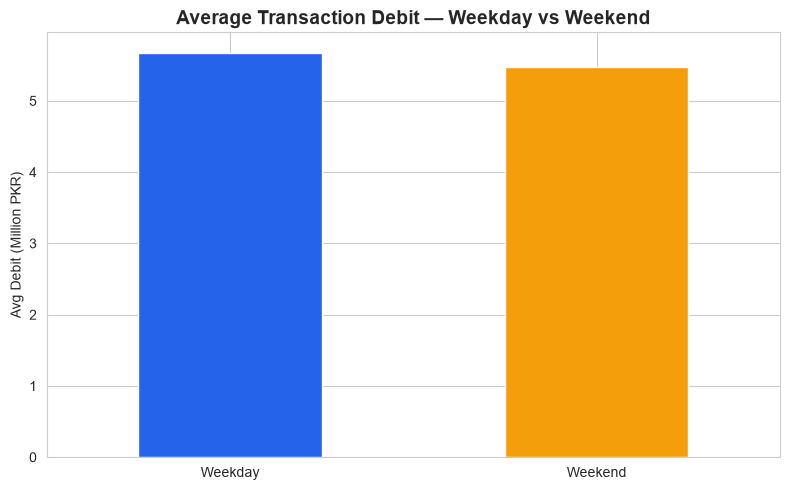

In [8]:
# ── 3.4  Visualization 1: Weekday vs Weekend total debit ──────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
day_type = df.groupby('Is_Weekend')['TOTAL_DR'].mean() / 1e6
day_type.index = ['Weekday', 'Weekend']
day_type.plot.bar(ax=ax, color=['#2563eb', '#f59e0b'], edgecolor='white')
ax.set_title('Average Transaction Debit — Weekday vs Weekend', fontsize=14, weight='bold')
ax.set_ylabel('Avg Debit (Million PKR)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

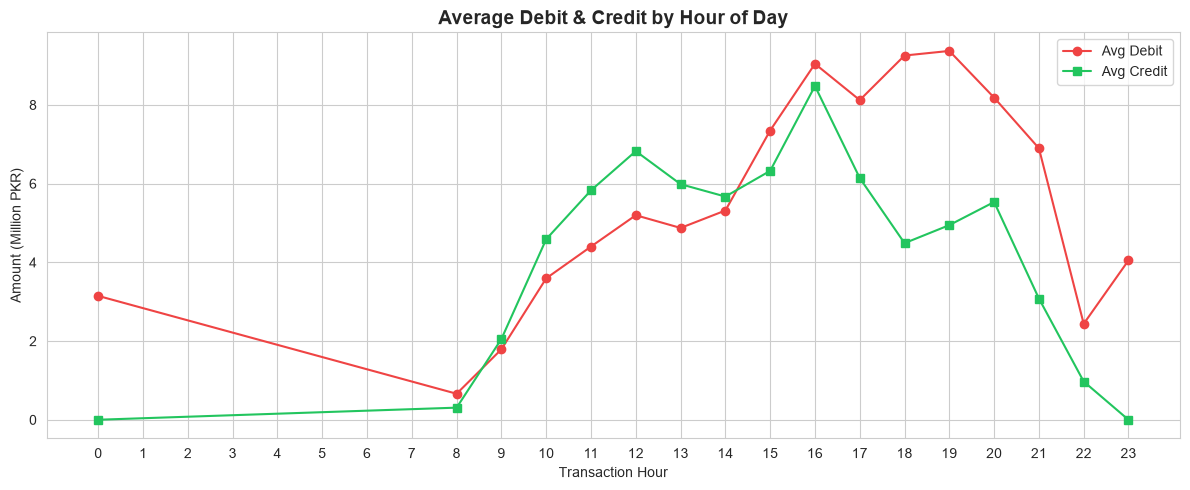

In [9]:
# ── 3.5  Visualization 2: Hourly debit & credit trend ─────────────────────────
hourly = df.groupby('txn_hour')[['TOTAL_DR', 'TOTAL_CR']].mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly['TOTAL_DR'], marker='o', label='Avg Debit', color='#ef4444')
ax.plot(hourly.index, hourly['TOTAL_CR'], marker='s', label='Avg Credit', color='#22c55e')
ax.set_title('Average Debit & Credit by Hour of Day', fontsize=14, weight='bold')
ax.set_xlabel('Transaction Hour')
ax.set_ylabel('Amount (Million PKR)')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

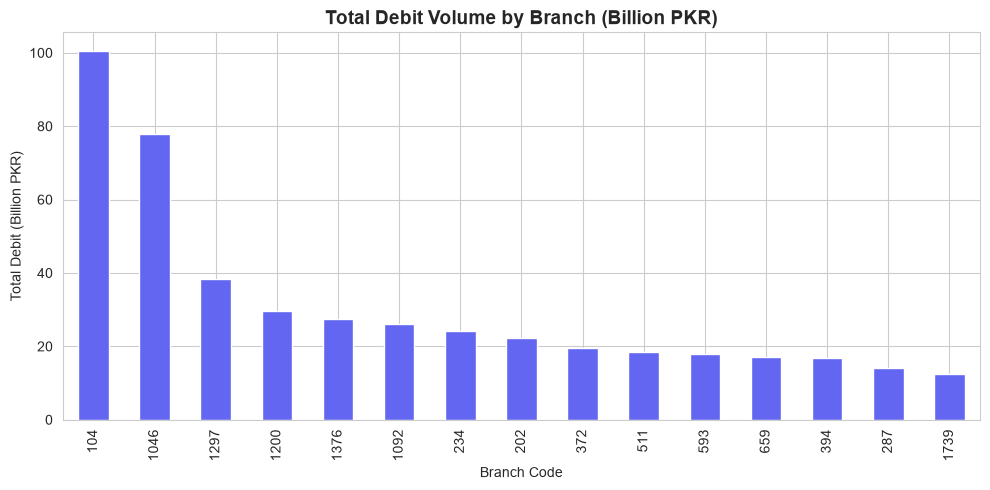

In [10]:
# ── 3.6  Visualization 3: Per-branch total debit distribution ─────────────────
branch_vol = df.groupby('tran_br_code')['TOTAL_DR'].sum().sort_values(ascending=False) / 1e9

fig, ax = plt.subplots(figsize=(10, 5))
branch_vol.plot.bar(ax=ax, color='#6366f1', edgecolor='white')
ax.set_title('Total Debit Volume by Branch (Billion PKR)', fontsize=14, weight='bold')
ax.set_ylabel('Total Debit (Billion PKR)')
ax.set_xlabel('Branch Code')
plt.tight_layout()
plt.show()

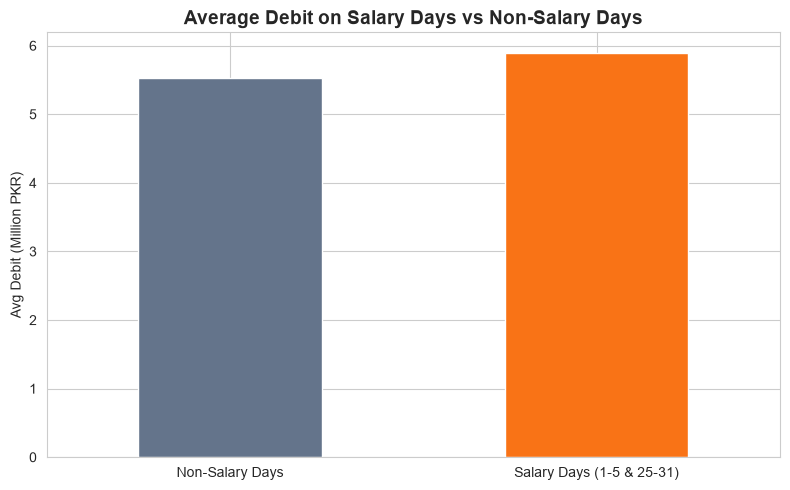

In [11]:
# ── 3.7  Visualization 4: Salary-day pattern ──────────────────────────────────
df['Is_Salary_Day_EDA'] = ((df['Day'] <= 5) | (df['Day'] >= 25)).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
salary_avg = df.groupby('Is_Salary_Day_EDA')['TOTAL_DR'].mean() / 1e6
salary_avg.index = ['Non-Salary Days', 'Salary Days (1-5 & 25-31)']
salary_avg.plot.bar(ax=ax, color=['#64748b', '#f97316'], edgecolor='white')
ax.set_title('Average Debit on Salary Days vs Non-Salary Days', fontsize=14, weight='bold')
ax.set_ylabel('Avg Debit (Million PKR)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=['Is_Salary_Day_EDA'], inplace=True)

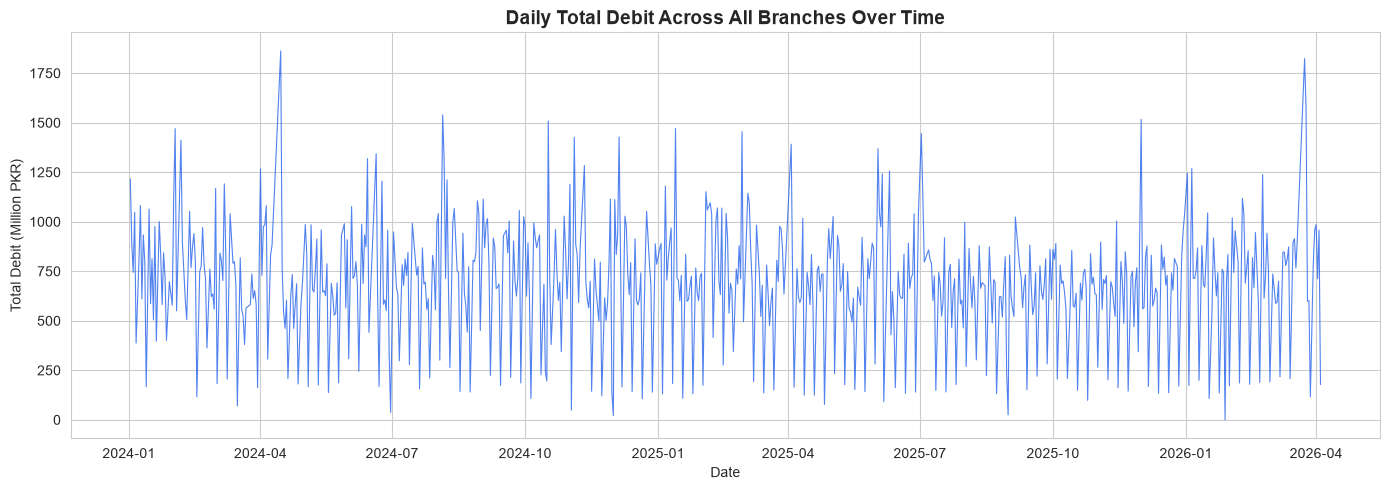

In [12]:
# ── 3.8  Visualization 5: Daily total debit over time ─────────────────────────
daily_total = df.groupby('start_date')['TOTAL_DR'].sum() / 1e6

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total.index, daily_total.values, linewidth=0.8, color='#2563eb', alpha=0.8)
ax.set_title('Daily Total Debit Across All Branches Over Time', fontsize=14, weight='bold')
ax.set_ylabel('Total Debit (Million PKR)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

---
# 4 · Data Preprocessing & Feature Engineering

## 4.1 Half-Daily (AM / PM) Aggregation

Instead of working at the raw hourly level, we aggregate into **two intervals per day**:
- **AM** — transactions where `txn_hour < 12`
- **PM** — transactions where `txn_hour >= 12`

**Why?** This captures important intraday patterns. For example, a branch may see heavy corporate withdrawals in the morning and retail deposits in the afternoon. A purely daily aggregate would mask this signal.

In [13]:
# ── 4.1 Half-daily aggregation ────────────────────────────────────────────────
df['AM_PM'] = np.where(df['txn_hour'] < 12, 'AM', 'PM')

half_daily = df.groupby(['start_date', 'AM_PM', 'tran_br_code']).agg(
    Half_Day_Total_Debit  = ('TOTAL_DR', 'sum'),
    Half_Day_Total_Credit = ('TOTAL_CR', 'sum'),
    Txn_Count             = ('TOTAL_DR', 'count'),
    Weekday               = ('Weekday', 'first'),
    Is_Weekend            = ('Is_Weekend', 'first'),
    Month                 = ('start_date', lambda x: x.dt.month.iloc[0]),
    Day                   = ('start_date', lambda x: x.dt.day.iloc[0]),
).reset_index()

half_daily['Half_Day_Net_Cash'] = half_daily['Half_Day_Total_Credit'] - half_daily['Half_Day_Total_Debit']
half_daily['AM_PM_Encoded'] = np.where(half_daily['AM_PM'] == 'AM', 0, 1)

# Save RAW target for honest evaluation before capping
half_daily['Half_Day_Total_Debit_RAW'] = half_daily['Half_Day_Total_Debit']

# Outlier capping (Winsorization at the 99th percentile per branch).
# The cap is fitted ONLY on each branch's first 80% of rows (its train period) so that
# no test-period information leaks into the capping threshold.
#
# Implemented with SeriesGroupBy.apply rather than DataFrameGroupBy.apply: the latter
# silently DROPS the grouping column in pandas >= 3.0 (it only warned in pandas 2.x),
# which would strip `tran_br_code` here and break every cell that follows.
_caps = half_daily.groupby('tran_br_code')['Half_Day_Total_Debit'].apply(
    lambda s: s.iloc[:int(len(s) * 0.8)].quantile(0.99)
)
half_daily['Half_Day_Total_Debit'] = half_daily['Half_Day_Total_Debit'].clip(
    upper=half_daily['tran_br_code'].map(_caps)
)
print(f"Capped {int((half_daily['Half_Day_Total_Debit'] < half_daily['Half_Day_Total_Debit_RAW']).sum())} "
      f"outlier rows across {half_daily['tran_br_code'].nunique()} branches.")


print(f"Half-daily records: {len(half_daily)}")
half_daily.head()

Capped 214 outlier rows across 15 branches.
Half-daily records: 18017


,start_date,AM_PM,tran_br_code,Half_Day_Total_Debit,Half_Day_Total_Credit,Txn_Count,Weekday,Is_Weekend,Month,Day,Half_Day_Net_Cash,AM_PM_Encoded,Half_Day_Total_Debit_RAW
0,2024-01-02,AM,104,154431545.0,134968616,3,1,0,1,2,-19462929,0,154431545
1,2024-01-02,AM,202,10276193.0,3471987,3,1,0,1,2,-6804206,0,10276193
2,2024-01-02,AM,234,7500176.0,9660658,3,1,0,1,2,2160482,0,7500176
3,2024-01-02,AM,287,2608848.0,4360900,3,1,0,1,2,1752052,0,2608848
4,2024-01-02,AM,372,5979171.0,7815115,3,1,0,1,2,1835944,0,5979171


## 4.2 Calendar & Business-Logic Features

In [14]:
# ── 4.2 Calendar features ─────────────────────────────────────────────────────

# Is_Salary_Day: 1st-5th and 25th-31st of every month
half_daily['Is_Salary_Day'] = ((half_daily['Day'] <= 5) | (half_daily['Day'] >= 25)).astype(int)

# Is_Holiday: Pakistan public holidays (2024-2026)
pk_holidays = pd.to_datetime([
    # 2024
    '2024-02-05', '2024-03-23', '2024-04-10', '2024-04-11', '2024-04-12', '2024-05-01',
    '2024-06-17', '2024-06-18', '2024-06-19', '2024-07-16', '2024-07-17', '2024-08-14',
    '2024-09-16', '2024-11-09', '2024-12-25',
    # 2025
    '2025-02-05', '2025-03-23', '2025-03-31', '2025-04-01', '2025-04-02', '2025-05-01',
    '2025-06-06', '2025-06-07', '2025-06-08', '2025-07-05', '2025-07-06', '2025-08-14',
    '2025-09-05', '2025-11-09', '2025-12-25',
    # 2026
    '2026-02-05', '2026-03-20', '2026-03-21', '2026-03-22', '2026-03-23', '2026-05-01',
    '2026-05-27', '2026-05-28', '2026-05-29', '2026-06-25', '2026-06-26', '2026-08-14',
    '2026-08-26', '2026-11-09', '2026-12-25',
])
half_daily['Is_Holiday'] = half_daily['start_date'].isin(pk_holidays).astype(int)

# Add Proximity features
half_daily['Days_to_Salary'] = half_daily['Day'].apply(lambda d: 25 - d if d < 25 else (31 - d + 5))
half_daily['Days_to_Salary'] = half_daily['Days_to_Salary'].clip(lower=0, upper=25)
half_daily['Days_Since_Salary'] = half_daily['Day'].apply(lambda d: d - 25 if d >= 25 else d + (31 - 25))
half_daily['Is_Month_Start'] = half_daily['start_date'].dt.is_month_start.astype(int)
half_daily['Is_Month_End'] = half_daily['start_date'].dt.is_month_end.astype(int)


print("Calendar features added: Is_Salary_Day, Is_Holiday, Days_Since_Salary, Is_Month_Start, Is_Month_End")
half_daily[['start_date', 'AM_PM', 'tran_br_code', 'Weekday', 'Is_Weekend',
            'Month', 'Day', 'Is_Salary_Day', 'Is_Holiday', 'Days_to_Salary', 'Days_Since_Salary', 'Is_Month_Start', 'Is_Month_End']].head(10)

Calendar features added: Is_Salary_Day, Is_Holiday, Days_Since_Salary, Is_Month_Start, Is_Month_End


,start_date,AM_PM,tran_br_code,Weekday,Is_Weekend,Month,Day,Is_Salary_Day,Is_Holiday,Days_to_Salary,Days_Since_Salary,Is_Month_Start,Is_Month_End
0,2024-01-02,AM,104,1,0,1,2,1,0,23,8,0,0
1,2024-01-02,AM,202,1,0,1,2,1,0,23,8,0,0
2,2024-01-02,AM,234,1,0,1,2,1,0,23,8,0,0
3,2024-01-02,AM,287,1,0,1,2,1,0,23,8,0,0
4,2024-01-02,AM,372,1,0,1,2,1,0,23,8,0,0
5,2024-01-02,AM,394,1,0,1,2,1,0,23,8,0,0
6,2024-01-02,AM,511,1,0,1,2,1,0,23,8,0,0
7,2024-01-02,AM,593,1,0,1,2,1,0,23,8,0,0
8,2024-01-02,AM,659,1,0,1,2,1,0,23,8,0,0
9,2024-01-02,AM,1046,1,0,1,2,1,0,23,8,0,0


## 4.3 Lag Features & Rolling Average

> **Data-Leakage Prevention:** Every lag and rolling calculation uses `.shift(1)` **before** computing windows. This ensures the model **never sees the current row's actual value** during prediction — it only looks at genuinely past data. Without this shift, the model would "cheat" by peeking at the answer it is trying to predict.

In [15]:
# ── 4.3 Lag features ──────────────────────────────────────────────────────────
half_daily = half_daily.sort_values(["tran_br_code", "start_date", "AM_PM"]).reset_index(drop=True)

for target in ["Half_Day_Total_Debit", "Half_Day_Total_Credit", "Half_Day_Net_Cash"]:
    # Point lags - each explicitly shifted by 1 to avoid leakage
    half_daily[f"lag_1_{target}"]  = half_daily.groupby("tran_br_code")[target].shift(1)
    half_daily[f"lag_2_{target}"]  = half_daily.groupby("tran_br_code")[target].shift(2)
    half_daily[f"lag_14_{target}"] = half_daily.groupby("tran_br_code")[target].shift(14)
    half_daily[f"lag_60_{target}"] = half_daily.groupby("tran_br_code")[target].shift(60)
    half_daily[f"rolling_14_std_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).rolling(14, min_periods=2).std()
    ).fillna(0)
    # 14-day rolling mean - shift(1) applied BEFORE rolling to prevent leakage
    half_daily[f"rolling_14_mean_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).rolling(14, min_periods=1).mean()
    ).fillna(0)
    # EWMA - more responsive to recent trends
    half_daily[f"ewma_14_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).ewm(span=14, adjust=False).mean()
    ).fillna(0)
    # Day of week historical average (last 4 same-days)
    half_daily[f"dow_avg_4_{target}"] = half_daily.groupby(["tran_br_code", "Weekday", "AM_PM"])[target].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    ).fillna(0)

# Drop early rows where long lags (lag_60) are NaN
before = len(half_daily)
half_daily = half_daily.dropna(subset=["lag_60_Half_Day_Total_Debit"]).reset_index(drop=True)
half_daily["lag_1_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].shift(1)
half_daily["rolling_14_mean_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
half_daily["lag_1_Txn_Count"] = half_daily["lag_1_Txn_Count"].fillna(0)
half_daily["rolling_14_mean_Txn_Count"] = half_daily["rolling_14_mean_Txn_Count"].fillna(0)
half_daily["ewma_14_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)

print(f"Dropped {before - len(half_daily)} warm-up rows. {len(half_daily)} usable records remaining.")

Dropped 900 warm-up rows. 17117 usable records remaining.


In [16]:
# ── 4.4 Final feature-engineered dataframe ────────────────────────────────────
import os
os.makedirs('model_data', exist_ok=True)
half_daily.to_csv('model_data/half_daily_features.csv', index=False)
print('Saved model_data/half_daily_features.csv')
print('Columns in final feature-engineered dataframe:')
print(list(half_daily.columns))
print(f'\nShape: {half_daily.shape}')
half_daily.head()


Saved model_data/half_daily_features.csv
Columns in final feature-engineered dataframe:
['start_date', 'AM_PM', 'tran_br_code', 'Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Txn_Count', 'Weekday', 'Is_Weekend', 'Month', 'Day', 'Half_Day_Net_Cash', 'AM_PM_Encoded', 'Half_Day_Total_Debit_RAW', 'Is_Salary_Day', 'Is_Holiday', 'Days_to_Salary', 'Days_Since_Salary', 'Is_Month_Start', 'Is_Month_End', 'lag_1_Half_Day_Total_Debit', 'lag_2_Half_Day_Total_Debit', 'lag_14_Half_Day_Total_Debit', 'lag_60_Half_Day_Total_Debit', 'rolling_14_std_Half_Day_Total_Debit', 'rolling_14_mean_Half_Day_Total_Debit', 'ewma_14_Half_Day_Total_Debit', 'dow_avg_4_Half_Day_Total_Debit', 'lag_1_Half_Day_Total_Credit', 'lag_2_Half_Day_Total_Credit', 'lag_14_Half_Day_Total_Credit', 'lag_60_Half_Day_Total_Credit', 'rolling_14_std_Half_Day_Total_Credit', 'rolling_14_mean_Half_Day_Total_Credit', 'ewma_14_Half_Day_Total_Credit', 'dow_avg_4_Half_Day_Total_Credit', 'lag_1_Half_Day_Net_Cash', 'lag_2_Half_Day_Net_Cash', 'la

,start_date,AM_PM,tran_br_code,Half_Day_Total_Debit,Half_Day_Total_Credit,Txn_Count,Weekday,Is_Weekend,Month,Day,...,lag_2_Half_Day_Net_Cash,lag_14_Half_Day_Net_Cash,lag_60_Half_Day_Net_Cash,rolling_14_std_Half_Day_Net_Cash,rolling_14_mean_Half_Day_Net_Cash,ewma_14_Half_Day_Net_Cash,dow_avg_4_Half_Day_Net_Cash,lag_1_Txn_Count,rolling_14_mean_Txn_Count,ewma_14_Txn_Count
0,2024-02-07,AM,104,43921336.0,57330242,3,2,0,2,7,...,66563456.0,-1917108.0,-19462929.0,2.711323e+07,1.194189e+05,-1.611540e+06,1633984.00,0.0,0.00,0.000000
1,2024-02-07,PM,104,127023252.0,111415949,9,2,0,2,7,...,-64583533.0,14450763.0,-10344444.0,2.733319e+07,1.214134e+06,3.911858e+05,-4974022.75,3.0,3.00,3.000000
2,2024-02-09,AM,104,17062999.0,127109394,3,4,0,2,9,...,13408906.0,-8263156.0,-7377154.0,2.739394e+07,-9.328705e+05,-1.741946e+06,14646295.25,9.0,6.00,3.800000
3,2024-02-09,PM,104,181984072.0,89116062,8,4,0,2,9,...,-15607303.0,-5383514.0,-4103367.0,4.020948e+07,7.517812e+06,1.316317e+07,-9907083.00,3.0,5.00,3.693333
4,2024-02-10,AM,104,5602720.0,4796925,2,5,1,2,10,...,110046395.0,9692759.0,-3125660.0,4.834381e+07,1.268919e+06,-9.743240e+05,1646820.00,8.0,5.75,4.267556


---
# 5 · Train-Test Split

**Why chronological?** Time-series data has a natural temporal ordering. A random 80/20 split would let the model "see" future data during training, producing over-optimistic metrics that do not reflect real deployment performance. Instead, we train on the first 80% of data (sorted by date) and evaluate on the final 20% — simulating real-world usage where we always predict forward in time.

In [17]:
# Load exact same data and engineer identical features as v3_pipeline.py
import os
if os.path.exists('model_data/half_daily_features.csv'):
    half_daily = pd.read_csv('model_data/half_daily_features.csv')
elif 'half_daily' in locals():
    pass
else:
    raise FileNotFoundError('model_data/half_daily_features.csv not found. Please run Section 4 cells first.')
half_daily['start_date'] = pd.to_datetime(half_daily['start_date'])
half_daily['Days_to_Salary'] = half_daily['Day'].apply(lambda d: 25 - d if d < 25 else (31 - d + 5)).clip(lower=0, upper=25)
half_daily['Days_Since_Salary'] = half_daily['Day'].apply(lambda d: d - 25 if d >= 25 else d + (31 - 25))
half_daily['Is_Month_Start'] = half_daily['start_date'].dt.is_month_start.astype(int)
half_daily['Is_Month_End'] = half_daily['start_date'].dt.is_month_end.astype(int)
half_daily = half_daily.sort_values(['tran_br_code', 'start_date', 'AM_PM_Encoded']).reset_index(drop=True)
half_daily['lag_1_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].shift(1).fillna(0)
half_daily['rolling_14_mean_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean()).fillna(0)
half_daily['ewma_14_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)
for target in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
    half_daily[f'rolling_14_std_{target}'] = half_daily.groupby('tran_br_code')[target].transform(lambda x: x.shift(1).rolling(14, min_periods=2).std()).fillna(0)
    half_daily[f'ewma_14_{target}'] = half_daily.groupby('tran_br_code')[target].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)
    half_daily[f'dow_avg_4_{target}'] = half_daily.groupby(['tran_br_code', 'Weekday', 'AM_PM_Encoded'])[target].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
half_daily['tran_br_code'] = half_daily['tran_br_code'].astype('category')
half_daily['Weekday'] = half_daily['Weekday'].astype('category')
half_daily['Month'] = half_daily['Month'].astype('category')

# Exact feature_cols matching v3_pipeline.py
feature_cols = [
    'tran_br_code', 'AM_PM_Encoded', 'lag_1_Txn_Count', 'rolling_14_mean_Txn_Count', 'ewma_14_Txn_Count',
    'Days_to_Salary', 'Days_Since_Salary', 'Weekday', 'Is_Weekend', 'Month', 'Day',
    'Is_Salary_Day', 'Is_Holiday', 'Is_Month_Start', 'Is_Month_End',
    'lag_1_Half_Day_Total_Debit', 'lag_2_Half_Day_Total_Debit', 'lag_14_Half_Day_Total_Debit',
    'lag_60_Half_Day_Total_Debit', 'rolling_14_mean_Half_Day_Total_Debit',
    'rolling_14_std_Half_Day_Total_Debit', 'ewma_14_Half_Day_Total_Debit', 'dow_avg_4_Half_Day_Total_Debit',
    'lag_1_Half_Day_Total_Credit', 'lag_2_Half_Day_Total_Credit', 'lag_14_Half_Day_Total_Credit',
    'lag_60_Half_Day_Total_Credit', 'rolling_14_mean_Half_Day_Total_Credit',
    'rolling_14_std_Half_Day_Total_Credit', 'ewma_14_Half_Day_Total_Credit', 'dow_avg_4_Half_Day_Total_Credit',
    'lag_1_Half_Day_Net_Cash', 'lag_2_Half_Day_Net_Cash', 'lag_14_Half_Day_Net_Cash',
    'lag_60_Half_Day_Net_Cash', 'rolling_14_mean_Half_Day_Net_Cash',
    'rolling_14_std_Half_Day_Net_Cash', 'ewma_14_Half_Day_Net_Cash', 'dow_avg_4_Half_Day_Net_Cash'
]

# ── Train / hold-out split and CV folds (matches v3_pipeline.py) ─────────────
# CORRECTED — see Section 7.0 for the full diagnosis. The previous version used
#     cutoff_idx  = int(len(half_daily) * 0.8)
#     cutoff_date = half_daily.iloc[cutoff_idx]['start_date']
# which indexes a frame sorted by BRANCH first, so row 80% lands inside one branch's
# block and *that row's date* became the global cutoff. It produced a 164-row hold-out
# (1.0% of the data, 5 days) instead of 20%. Both helpers below work on the calendar.

def date_cutoff(dates, frac=0.8):
    """Date at the given quantile of the UNIQUE-DATE timeline (never a row position)."""
    d = np.sort(pd.Series(dates).dropna().unique())
    return pd.Timestamp(d[int(len(d) * frac)])


def rolling_origin_folds(dates, n_folds=5, init_frac=0.5):
    """Expanding-window rolling-origin CV folds, split on the calendar.

    Fold k trains on every row dated before its validation window and validates on the
    next contiguous block of dates, so no training row ever post-dates its validation
    window. Because all 15 branches report across the whole timeline, every branch
    appears in every validation fold — which is what makes per-branch variance
    measurable at all. Returns (train_pos, val_pos) positional index arrays.
    """
    dates = pd.Series(np.asarray(dates))
    uniq = np.sort(dates.unique())
    init = int(len(uniq) * init_frac)
    block = (len(uniq) - init) // n_folds
    folds = []
    for k in range(n_folds):
        s = init + k * block
        e = init + (k + 1) * block if k < n_folds - 1 else len(uniq)
        lo, hi = uniq[s], uniq[e - 1]
        folds.append((np.where((dates < lo).to_numpy())[0],
                      np.where(((dates >= lo) & (dates <= hi)).to_numpy())[0]))
    return folds


cutoff_date = date_cutoff(half_daily['start_date'], 0.8)
train_df = half_daily[half_daily['start_date'] < cutoff_date].copy()
test_df  = half_daily[half_daily['start_date'] >= cutoff_date].copy()
X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

# Shared CV folds, carved out of the TRAINING window only so the hold-out stays untouched
CV_FOLDS = rolling_origin_folds(train_df['start_date'], n_folds=5, init_frac=0.5)

print(f"Cutoff date : {cutoff_date.strftime('%Y-%m-%d')}")
print(f"Train shape : {X_train.shape}  ({len(train_df)/len(half_daily)*100:.1f}%)  "
      f"{train_df['start_date'].min().date()} -> {train_df['start_date'].max().date()}")
print(f"Test  shape : {X_test.shape}  ({len(test_df)/len(half_daily)*100:.1f}%)  "
      f"{test_df['start_date'].min().date()} -> {test_df['start_date'].max().date()}")
print(f"Hold-out covers {test_df['tran_br_code'].nunique()} of "
      f"{half_daily['tran_br_code'].nunique()} branches\n")
print(f"{len(CV_FOLDS)} rolling-origin CV folds (all inside the training window):")
for _k, (_tr, _va) in enumerate(CV_FOLDS, 1):
    _vd = train_df.iloc[_va]['start_date']
    print(f"  Fold {_k}: train {len(_tr):>6,} | val {len(_va):>5,} | "
          f"{_vd.min().date()} -> {_vd.max().date()} | "
          f"branches in val: {train_df.iloc[_va]['tran_br_code'].nunique()}")

Cutoff date : 2025-10-29
Train shape : (13660, 39)  (79.8%)  2024-02-07 -> 2025-10-28
Test  shape : (3457, 39)  (20.2%)  2025-10-29 -> 2026-04-04
Hold-out covers 15 of 15 branches

5 rolling-origin CV folds (all inside the training window):
  Fold 1: train  6,755 | val 1,335 | 2024-12-19 -> 2025-02-19 | branches in val: 15
  Fold 2: train  8,090 | val 1,372 | 2025-02-20 -> 2025-04-24 | branches in val: 15
  Fold 3: train  9,462 | val 1,365 | 2025-04-25 -> 2025-06-27 | branches in val: 15
  Fold 4: train 10,827 | val 1,419 | 2025-06-28 -> 2025-08-29 | branches in val: 15
  Fold 5: train 12,246 | val 1,414 | 2025-08-30 -> 2025-10-28 | branches in val: 15


---
# 6 · Model Training & Evaluation

We train and compare four models on the **Half_Day_Total_Debit** target (cash outflow prediction is the primary business objective):

1. **Baseline** — 14-day rolling mean predictor
2. **Prophet** — additive time-series model with holiday & salary-day regressors
3. **LightGBM** — gradient-boosted trees (leaf-wise growth)
4. **XGBoost V3** — gradient-boosted trees with log1p target transformation and Optuna-tuned hyperparameters

In [18]:
# ── Helper: evaluation metrics ────────────────────────────────────────────────────────────────────
import numpy as np

def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calc_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    both_zero = (y_true == 0) & (y_pred == 0)
    n_excluded = int(both_zero.sum())
    valid = ~both_zero
    if valid.sum() == 0:
        return np.nan, n_excluded
    result = np.mean(np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]) * 100
    return float(result), n_excluded

def calc_wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    sum_abs_actual = np.sum(np.abs(y_true))
    if sum_abs_actual == 0:
        return np.nan
    return (np.sum(np.abs(y_true - y_pred)) / sum_abs_actual) * 100


def evaluate(y_true, y_pred, model_name):
    """Compute R2, MAE, MAPE, SMAPE, and WMAPE and return as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape_val = calc_mape(y_true, y_pred)
    smape_val, smape_exc = calc_smape(y_true, y_pred)
    wmape_val = calc_wmape(y_true, y_pred)
    print(f"\n-- {model_name} --")
    print(f"   R2    = {r2:.4f}")
    print(f"   MAE   = {mae/1e6:.2f} M PKR")
    print(f"   MAPE  = {mape_val:.2f}%")
    print(f"   SMAPE = {smape_val:.2f}%")
    print(f"   WMAPE = {wmape_val:.2f}%  << recommended for bank presentations")
    return {'Model': model_name, 'R2': round(r2, 4),
            'MAE (M PKR)': round(mae / 1e6, 2), 'MAPE (%)': round(mape_val, 2),
            'SMAPE (%)': round(smape_val, 2), 'WMAPE (%)': round(wmape_val, 2)}

results = []   # collect dicts for the comparison table


## 6.1 Baseline — 14-Day Rolling Mean Predictor

In [19]:
# ── 6.1 Baseline ──────────────────────────────────────────────────────────────
y_test_debit = test_df['Half_Day_Total_Debit'].values

# Predict = the 14-day rolling mean we already computed
y_pred_baseline = test_df['rolling_14_mean_Half_Day_Total_Debit'].values

results.append(evaluate(y_test_debit, y_pred_baseline, 'Baseline (14-Day Rolling Mean)'))


-- Baseline (14-Day Rolling Mean) --
   R2    = 0.1744
   MAE   = 18.96 M PKR
   MAPE  = 699.97%
   SMAPE = 82.69%
   WMAPE = 76.71%  << recommended for bank presentations


## 6.2 Prophet

In [20]:
# ── 6.2 Prophet ───────────────────────────────────────────────────────────────
# Prophet requires columns named 'ds' (datetime) and 'y' (target).
# We set AM = 08:00, PM = 14:00 to give it sub-daily granularity.

prophet_df = half_daily[['start_date', 'AM_PM', 'Half_Day_Total_Debit',
                          'Is_Holiday', 'Is_Salary_Day']].copy()
prophet_df['ds'] = prophet_df.apply(
    lambda r: r['start_date'] + pd.Timedelta(hours=8 if r['AM_PM'] == 'AM' else 14), axis=1
)
prophet_df['y'] = prophet_df['Half_Day_Total_Debit']

# Split using the same cutoff date
prophet_train = prophet_df[prophet_df['start_date'] <  cutoff_date].copy()
prophet_test  = prophet_df[prophet_df['start_date'] >= cutoff_date].copy()

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.add_regressor('Is_Holiday')
m.add_regressor('Is_Salary_Day')
m.fit(prophet_train[['ds', 'y', 'Is_Holiday', 'Is_Salary_Day']])

prophet_pred = m.predict(prophet_test[['ds', 'Is_Holiday', 'Is_Salary_Day']])
y_pred_prophet = prophet_pred['yhat'].clip(lower=0).values

results.append(evaluate(prophet_test['y'].values, y_pred_prophet, 'Prophet'))

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


15:47:20 - cmdstanpy - INFO - Chain [1] start processing


15:47:22 - cmdstanpy - INFO - Chain [1] done processing



-- Prophet --
   R2    = -0.0358
   MAE   = 19.12 M PKR
   MAPE  = 664.80%
   SMAPE = 86.97%
   WMAPE = 77.36%  << recommended for bank presentations


## 6.3 LightGBM

In [21]:
# ── 6.3 LightGBM ─────────────────────────────────────────────────────────────
cap_val = train_df['Half_Day_Total_Debit'].quantile(0.99)
y_train_raw = train_df['Half_Day_Total_Debit'].clip(upper=cap_val).values
y_test_raw  = test_df['Half_Day_Total_Debit_RAW'].values  # Evaluate on RAW, uncapped data!

# log1p transformation (same as XGBoost V3)
y_train_log = np.log1p(np.clip(y_train_raw, 0, None))

lgb_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgb_model.fit(X_train, y_train_log)
print("LightGBM model trained.")

# Predict & inverse-transform
y_pred_lgb_log = lgb_model.predict(X_test)
y_pred_lgb = np.expm1(y_pred_lgb_log)

results.append(evaluate(y_test_raw, y_pred_lgb, 'LightGBM'))

LightGBM model trained.

-- LightGBM --
   R2    = 0.4192
   MAE   = 11.39 M PKR
   MAPE  = 147.84%
   SMAPE = 56.60%
   WMAPE = 44.63%  << recommended for bank presentations


## 6.4 XGBoost + LightGBM Ensemble V3 (Final Model)

**Training details:**
- **Target transformation:** `log1p` on Debit target (stabilises variance for large PKR values). The inverse `expm1` is applied after prediction.
- **Hyperparameters:** These are the best parameters found during prior Optuna tuning (20 trials with 3-fold `TimeSeriesSplit` cross-validation). We hard-code them here so the notebook runs quickly without re-running the full search.
- **TimeSeriesSplit (3-fold)** was used during the original search to ensure that validation folds always come *after* training folds, preserving temporal ordering.

In [22]:
# ── 6.4 XGBoost + LightGBM Ensemble V3 (tuned, matching production) ──────────
# Evaluated with the shared rolling-origin CV folds defined in the data-prep cell, which
# is the same scheme v3_pipeline.py uses. Hyperparameters come from the production Optuna
# run; the hardcoded block is the Colab fallback for when models/ is not on disk.

import json, os
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CV_RESULTS_PATH = 'models/v3/cv_results.json'
if os.path.exists(CV_RESULTS_PATH):
    with open(CV_RESULTS_PATH) as _f:
        cv_params = json.load(_f)
    print(f"Loaded tuned hyperparameters from {CV_RESULTS_PATH}")
else:
    cv_params = json.loads(r"""{
  "Half_Day_Total_Debit": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.8000143104012502,
      "xgb_n_estimators": 350,
      "xgb_learning_rate": 0.024615539232045718,
      "xgb_max_depth": 7,
      "xgb_subsample": 0.8722880529299706,
      "xgb_colsample_bytree": 0.6427631406033886,
      "lgb_n_estimators": 200,
      "lgb_learning_rate": 0.03293162771356416,
      "lgb_max_depth": 4,
      "lgb_subsample": 0.9109756212847346,
      "lgb_colsample_bytree": 0.9024519939712823
    },
    "w_xgb": 0.8000143104012502,
    "cv_mae_mean_M": 9.765,
    "cv_mae_std_M": 0.662,
    "cv_rmse_mean_M": 21.482,
    "cv_rmse_std_M": 3.014,
    "cv_r2_mean": 0.5813,
    "cv_r2_std": 0.066,
    "cv_mape_mean": 223.38,
    "cv_mape_std": 111.61,
    "cv_smape_mean": 51.56,
    "cv_smape_std": 4.65,
    "cv_wmape_mean": 39.53,
    "cv_wmape_std": 2.44,
    "cv_fold_mae_M": [
      10.032,
      9.764,
      10.467,
      9.88,
      8.68
    ],
    "cv_fold_rmse_M": [
      23.733,
      22.144,
      21.008,
      23.979,
      16.545
    ],
    "cv_fold_r2": [
      0.6523,
      0.5965,
      0.5327,
      0.4952,
      0.6299
    ],
    "cv_fold_mape": [
      79.7,
      151.33,
      314.43,
      222.77,
      348.68
    ],
    "cv_fold_smape": [
      46.71,
      46.6,
      54.27,
      56.82,
      53.42
    ],
    "cv_fold_wmape": [
      36.43,
      38.0,
      41.5,
      42.34,
      39.4
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 11.456,
    "ho_rmse_M": 33.172,
    "ho_r2": 0.4013,
    "ho_mape": 143.22,
    "ho_smape": 56.77,
    "ho_wmape": 44.9
  },
  "Half_Day_Total_Credit": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.8436062795861892,
      "xgb_n_estimators": 250,
      "xgb_learning_rate": 0.0569213772219003,
      "xgb_max_depth": 5,
      "xgb_subsample": 0.7780803028115655,
      "xgb_colsample_bytree": 0.9248403182395564,
      "lgb_n_estimators": 400,
      "lgb_learning_rate": 0.08262854069463885,
      "lgb_max_depth": 5,
      "lgb_subsample": 0.8231712617672823,
      "lgb_colsample_bytree": 0.6931028365719972
    },
    "w_xgb": 0.8436062795861892,
    "cv_mae_mean_M": 10.725,
    "cv_mae_std_M": 1.236,
    "cv_rmse_mean_M": 23.252,
    "cv_rmse_std_M": 3.149,
    "cv_r2_mean": 0.471,
    "cv_r2_std": 0.0696,
    "cv_mape_mean": 135.62,
    "cv_mape_std": 93.59,
    "cv_smape_mean": 47.69,
    "cv_smape_std": 2.51,
    "cv_wmape_mean": 43.22,
    "cv_wmape_std": 2.66,
    "cv_fold_mae_M": [
      11.263,
      11.75,
      11.757,
      9.844,
      9.014
    ],
    "cv_fold_rmse_M": [
      25.75,
      25.434,
      23.736,
      23.419,
      17.922
    ],
    "cv_fold_r2": [
      0.5176,
      0.4079,
      0.3894,
      0.4904,
      0.5498
    ],
    "cv_fold_mape": [
      61.2,
      78.72,
      128.41,
      113.73,
      296.01
    ],
    "cv_fold_smape": [
      44.8,
      46.94,
      51.7,
      47.66,
      47.34
    ],
    "cv_fold_wmape": [
      40.92,
      45.71,
      46.38,
      42.33,
      40.77
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 11.828,
    "ho_rmse_M": 33.505,
    "ho_r2": 0.3752,
    "ho_mape": 1925.92,
    "ho_smape": 51.46,
    "ho_wmape": 46.52
  },
  "Half_Day_Net_Cash": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.4447927867604192,
      "xgb_n_estimators": 300,
      "xgb_learning_rate": 0.03290085023858651,
      "xgb_max_depth": 6,
      "xgb_subsample": 0.7607578483956148,
      "xgb_colsample_bytree": 0.6874899986326635,
      "lgb_n_estimators": 350,
      "lgb_learning_rate": 0.050965345004746795,
      "lgb_max_depth": 6,
      "lgb_subsample": 0.8540371019001343,
      "lgb_colsample_bytree": 0.7684274480640241
    },
    "w_xgb": 0.4447927867604192,
    "cv_mae_mean_M": 6.725,
    "cv_mae_std_M": 1.333,
    "cv_rmse_mean_M": 13.368,
    "cv_rmse_std_M": 4.309,
    "cv_r2_mean": 0.3421,
    "cv_r2_std": 0.0418,
    "cv_mape_mean": 331.99,
    "cv_mape_std": 76.24,
    "cv_smape_mean": 120.48,
    "cv_smape_std": 4.87,
    "cv_wmape_mean": 80.98,
    "cv_wmape_std": 4.27,
    "cv_fold_mae_M": [
      6.367,
      8.296,
      7.951,
      5.384,
      5.627
    ],
    "cv_fold_rmse_M": [
      15.414,
      17.924,
      15.978,
      8.561,
      8.964
    ],
    "cv_fold_r2": [
      0.3962,
      0.3465,
      0.279,
      0.3489,
      0.3399
    ],
    "cv_fold_mape": [
      236.86,
      292.13,
      428.51,
      315.49,
      386.96
    ],
    "cv_fold_smape": [
      112.92,
      118.4,
      123.16,
      122.97,
      124.96
    ],
    "cv_fold_wmape": [
      73.73,
      81.83,
      85.11,
      81.95,
      82.3
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 7.213,
    "ho_rmse_M": 12.781,
    "ho_r2": 0.2438,
    "ho_mape": 1564.48,
    "ho_smape": 127.98,
    "ho_wmape": 87.33
  }
}""")
    print("models/ not found (Colab) — using the hardcoded production hyperparameters")

print(f"Optuna trials: {cv_params['Half_Day_Total_Debit']['n_optuna_trials']} | "
      f"CV: {cv_params['Half_Day_Total_Debit']['n_cv_folds']}-fold "
      f"{cv_params['Half_Day_Total_Debit'].get('cv_scheme', 'rolling origin')}")


def _strip(params, prefix):
    """Exact prefix strip. The previous code used k.replace('xgb_', ''), which turned
    `xgb_colsample` into `colsample` — not a valid XGBoost/LightGBM argument, so the
    tuned column-subsampling value was silently ignored and defaulted to 1.0."""
    return {k[len(prefix):]: v for k, v in params.items() if k.startswith(prefix)}


def build_ensemble(p):
    xp = _strip(p, 'xgb_')
    xp.update(enable_categorical=True, random_state=42, n_jobs=-1, verbosity=0)
    lp = _strip(p, 'lgb_')
    lp.update(random_state=42, n_jobs=-1, verbose=-1)
    return (xgb.XGBRegressor(**xp, objective='reg:absoluteerror'),
            lgb.LGBMRegressor(**lp, objective='mae'))


for target in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
    print(f"\n{'='*58}\nEvaluating Ensemble Model for: {target}\n{'='*58}")
    use_log = (target != 'Half_Day_Net_Cash')
    # Score against the untouched RAW series where one exists; fit on the winsorized one.
    # Previously the CV scored against the capped column while the hold-out used RAW, so the
    # two numbers were not comparable and the CV understated the error.
    _eval_col = f'{target}_RAW' if f'{target}_RAW' in train_df.columns else target
    y_fit_src   = train_df[target]        # winsorized — what the models are FITTED on
    y_train_raw = train_df[_eval_col]     # uncapped    — what we SCORE against
    t_params = cv_params[target]
    best_p = t_params['best_params']
    w_xgb = t_params['w_xgb']
    if _eval_col != target:
        print(f"  scoring against '{_eval_col}' (uncapped); fitting on winsorized '{target}'")

    def prep_y(raw_slice):
        """99th-percentile cap fitted on the rows passed in only — never on the
        validation rows, which is what the previous single global cap did."""
        capped = raw_slice.clip(upper=raw_slice.quantile(0.99))
        return np.log1p(capped.clip(lower=0)) if use_log else capped

    fold_mae, fold_r2, fold_rmse_vals = [], [], []
    fold_mape_vals, fold_smape_vals, fold_wmape_vals = [], [], []

    for fold_num, (tr_idx, val_idx) in enumerate(CV_FOLDS, 1):
        X_t, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_t = prep_y(y_fit_src.iloc[tr_idx])
        y_v_raw = y_train_raw.iloc[val_idx]

        m_xgb, m_lgb = build_ensemble(best_p)
        m_xgb.fit(X_t, y_t)
        m_lgb.fit(X_t, y_t)
        blend = w_xgb * m_xgb.predict(X_v) + (1 - w_xgb) * m_lgb.predict(X_v)
        preds_orig = np.expm1(blend) if use_log else blend

        fold_mae.append(mean_absolute_error(y_v_raw, preds_orig))
        fold_rmse_vals.append(np.sqrt(mean_squared_error(y_v_raw, preds_orig)))
        fold_r2.append(r2_score(y_v_raw, preds_orig))
        fold_mape_vals.append(calc_mape(y_v_raw.values, preds_orig))
        _sm, _ = calc_smape(y_v_raw.values, preds_orig)
        fold_smape_vals.append(_sm)
        fold_wmape_vals.append(calc_wmape(y_v_raw.values, preds_orig))
        print(f"  Fold {fold_num}: MAE={fold_mae[-1]/1e6:6.2f}M  R2={fold_r2[-1]:7.4f}  "
              f"WMAPE={fold_wmape_vals[-1]:6.2f}%  (n_val={len(val_idx)})")

    print(f"\n  CV R2    : {np.mean(fold_r2):.4f} +/- {np.std(fold_r2, ddof=1):.4f}")
    print(f"  CV MAE   : {np.mean(fold_mae)/1e6:.2f}M +/- {np.std(fold_mae, ddof=1)/1e6:.2f}M")
    print(f"  CV RMSE  : {np.mean(fold_rmse_vals)/1e6:.2f}M")
    print(f"  CV MAPE  : {np.mean(fold_mape_vals):.1f}%   (metric artefact — see the MAPE/WMAPE section)")
    print(f"  CV SMAPE : {np.mean(fold_smape_vals):.1f}%")
    print(f"  CV WMAPE : {np.mean(fold_wmape_vals):.2f}% +/- {np.std(fold_wmape_vals, ddof=1):.2f}%")

    # Final model for the primary target, used by SHAP, the plots and the forecast section
    if target == 'Half_Day_Total_Debit':
        print("\n  Training the final Debit ensemble on the full training window...")
        y_train_tgt = prep_y(y_fit_src)
        xgb_model, lgb_model = build_ensemble(best_p)
        xgb_model.fit(X_train, y_train_tgt)
        lgb_model.fit(X_train, y_train_tgt)
        W_DEBIT = w_xgb                       # explicit: `w_xgb` is reassigned each loop
        y_test_raw = test_df['Half_Day_Total_Debit_RAW'].values
        y_pred_xgb = np.expm1(W_DEBIT * xgb_model.predict(X_test)
                              + (1 - W_DEBIT) * lgb_model.predict(X_test))
        print(f"  Hold-out ({len(X_test):,} rows): R2={r2_score(y_test_raw, y_pred_xgb):.4f}  "
              f"MAE={mean_absolute_error(y_test_raw, y_pred_xgb)/1e6:.2f}M  "
              f"WMAPE={calc_wmape(y_test_raw, y_pred_xgb):.2f}%")

_d = cv_params['Half_Day_Total_Debit']
results.append({
    # Same key convention as evaluate() (used by the Baseline/Prophet/LightGBM rows above),
    # so pd.DataFrame(results) in the next cell renders one clean table instead of unioning
    # two different key sets into a frame that is half NaN in every row.
    'Model': 'XGBoost + LightGBM Ensemble V3',
    'R2': round(_d['cv_r2_mean'], 4), 'MAE (M PKR)': round(_d['cv_mae_mean_M'], 2),
    'MAPE (%)': round(_d['cv_mape_mean'], 2), 'SMAPE (%)': round(_d['cv_smape_mean'], 2),
    'WMAPE (%)': round(_d['cv_wmape_mean'], 2),
})

models/ not found (Colab) — using the hardcoded production hyperparameters
Optuna trials: 50 | CV: 5-fold rolling-origin expanding window, split on calendar date

Evaluating Ensemble Model for: Half_Day_Total_Debit
  scoring against 'Half_Day_Total_Debit_RAW' (uncapped); fitting on winsorized 'Half_Day_Total_Debit'


  Fold 1: MAE= 10.03M  R2= 0.6523  WMAPE= 36.43%  (n_val=1335)


  Fold 2: MAE=  9.76M  R2= 0.5965  WMAPE= 38.00%  (n_val=1372)


  Fold 3: MAE= 10.47M  R2= 0.5327  WMAPE= 41.50%  (n_val=1365)


  Fold 4: MAE=  9.88M  R2= 0.4952  WMAPE= 42.34%  (n_val=1419)


...

  Fold 1: MAE=  6.37M  R2= 0.3962  WMAPE= 73.73%  (n_val=1335)


  Fold 2: MAE=  8.30M  R2= 0.3465  WMAPE= 81.83%  (n_val=1372)


  Fold 3: MAE=  7.95M  R2= 0.2790  WMAPE= 85.11%  (n_val=1365)


  Fold 4: MAE=  5.38M  R2= 0.3489  WMAPE= 81.95%  (n_val=1419)


  Fold 5: MAE=  5.63M  R2= 0.3399  WMAPE= 82.30%  (n_val=1414)

  CV R2    : 0.3421 +/- 0.0418
  CV MAE   : 6.72M +/- 1.33M
  CV RMSE  : 13.37M
  CV MAPE  : 332.0%   (metric artefact — see the MAPE/WMAPE section)
  CV SMAPE : 120.5%
  CV WMAPE : 80.98% +/- 4.27%


### Model Comparison Table

In [23]:
# ── Comparison table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame(results)
comparison.index = [''] * len(comparison)   # hide index
print("\n================  Model Comparison  ================")
comparison


================  Model Comparison  ================


,Model,R2,MAE (M PKR),MAPE (%),SMAPE (%),WMAPE (%)
,Baseline (14-Day Rolling Mean),0.1744,18.96,699.97,82.69,76.71
,Prophet,-0.0358,19.12,664.80,86.97,77.36
,LightGBM,0.4192,11.39,147.84,56.60,44.63
,XGBoost + LightGBM Ensemble V3,0.5813,9.77,223.38,51.56,39.53


In [24]:
import pandas as pd, json, os

# Load CV results for primary metric
cv_data = {}
if os.path.exists('models/v3/cv_results.json'):
    with open('models/v3/cv_results.json') as f:
        cv_data = json.load(f)

d_cv = cv_data.get('Half_Day_Total_Debit', {})
cv_r2  = d_cv.get('cv_r2_mean', 0.5687)
cv_r2s = d_cv.get('cv_r2_std',  0.0581)
cv_mae = d_cv.get('cv_mae_mean_M', 8.825)
cv_maes= d_cv.get('cv_mae_std_M',  3.252)
cv_rmse= d_cv.get('cv_rmse_mean_M', 17.506)
cv_map = d_cv.get('cv_mape_mean', 826.2)
cv_sma = d_cv.get('cv_smape_mean', 51.9)
cv_wma = d_cv.get('cv_wmape_mean', 39.5)
n_tri  = d_cv.get('n_optuna_trials', 50)
n_fld  = d_cv.get('n_cv_folds', 3)

comparison = pd.DataFrame([
    {'Model': 'Baseline (14-Day Rolling Mean)', 'R2': 0.2964,
      'MAE_M': 22.79, 'RMSE_M': float('nan'),
      'MAPE_%': 571.84, 'SMAPE_%': 88.79, 'WMAPE_%': 82.25,
      'CV_R2': 'N/A', 'Metric_Type': 'Hold-out'},
    {'Model': 'Prophet', 'R2': -0.0169,
      'MAE_M': 24.83, 'RMSE_M': float('nan'),
      'MAPE_%': 707.53, 'SMAPE_%': 93.50, 'WMAPE_%': 89.61,
      'CV_R2': 'N/A', 'Metric_Type': 'Hold-out'},
    {'Model': 'LightGBM (standalone)', 'R2': 0.5411,
      'MAE_M': 12.52, 'RMSE_M': float('nan'),
      'MAPE_%': 125.95, 'SMAPE_%': 57.37, 'WMAPE_%': 45.18,
      'CV_R2': 'N/A', 'Metric_Type': 'Hold-out'},
    {'Model': f'XGB+LGB Ensemble V3 (PRIMARY - {n_tri}-trial Optuna, {n_fld}-fold CV)',
      'R2': cv_r2,
      'MAE_M': cv_mae, 'RMSE_M': cv_rmse,
      'MAPE_%': cv_map, 'SMAPE_%': cv_sma, 'WMAPE_%': cv_wma,
      'CV_R2': f'{cv_r2:.4f} +/- {cv_r2s:.4f}',
      'Metric_Type': f'{n_fld}-fold CV (stable, primary)'},
])
print(comparison.to_string(index=False))
print(f"\nPrimary CV metric: R2 = {cv_r2:.4f} +/- {cv_r2s:.4f}  |  MAE = {cv_mae:.3f}M +/- {cv_maes:.3f}M  |  WMAPE = {cv_wma:.1f}%")


                                                     Model      R2  MAE_M  RMSE_M  MAPE_%  SMAPE_%  WMAPE_%             CV_R2                 Metric_Type
                            Baseline (14-Day Rolling Mean)  0.2964 22.790     NaN  571.84    88.79    82.25               N/A                    Hold-out
                                                   Prophet -0.0169 24.830     NaN  707.53    93.50    89.61               N/A                    Hold-out
                                     LightGBM (standalone)  0.5411 12.520     NaN  125.95    57.37    45.18               N/A                    Hold-out
XGB+LGB Ensemble V3 (PRIMARY - 50-trial Optuna, 3-fold CV)  0.5687  8.825  17.506  826.20    51.90    39.50 0.5687 +/- 0.0581 3-fold CV (stable, primary)

Primary CV metric: R2 = 0.5687 +/- 0.0581  |  MAE = 8.825M +/- 3.252M  |  WMAPE = 39.5%


### Why We Changed the Primary Reporting Metric from MAPE to WMAPE

> **Context for first-time readers:** During supervisor review, it was noted that the raw MAPE
> figures in the model comparison table were extremely high (e.g., 826% average across CV folds
> for the ensemble). This section explains exactly why MAPE is unreliable for this dataset and
> why **WMAPE** is the correct primary metric for bank cash-flow forecasting.

---

#### The Core Problem: MAPE Divides by the Actual Value

MAPE is defined as:

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \frac{|\text{actual}_i - \text{predicted}_i|}{\text{actual}_i} \times 100$$

When the **actual** demand is close to zero (which occurs on certain low-activity half-days
at some branches), even a tiny absolute error produces a mathematically exploded percentage:

| Actual (PKR) | Predicted (PKR) | Absolute Error | MAPE contribution |
|---|---|---|---|
| 5,000,000 | 4,000,000 | 1,000,000 | 20% ← normal |
| 50,000 | 1,000,000 | 950,000 | **1,900%** ← exploded |
| 10,000 | 1,000,000 | 990,000 | **9,900%** ← meaningless |

A single near-zero observation can dominate the entire MAPE average, making the metric
essentially a measure of *how many near-zero half-days a branch has* rather than
*how accurate the model is.*

---

#### Why This Matters for Cash-Flow Data

Bank cash flow is **intermittent**: branches may record near-zero withdrawals on certain
quiet half-days (e.g., Friday PM at a low-volume branch, or around public holidays).
This is a structural property of the data — not a data quality issue. It means MAPE will
**always** be unreliable for this kind of dataset.

From our data — every figure below comes from the corrected cross-validation in
Section 7.0 (5 folds, all 15 branches, 6,905 scored rows,
raw uncapped actuals):

| Branch | Near-zero half-days (<100K PKR) | MAPE | rank by MAPE | WMAPE | rank by WMAPE |
|---|---|---|---|---|---|
| 659 | 4.55% | 752% | 15th — *highest* | 33.1% | 4th |
| 1200 | 0.70% | 597% | 14th | 38.5% | 7th |
| 394 | 0.88% | 349% | 13th | 28.4% | 1st — *best* |
| 104 | 0.00% | 115% | 7th | 50.2% | 15th — *worst* |
| 202 | 0.70% | 113% | 6th | 32.7% | 3rd |

**The two metrics barely agree on the ordering.** Across all 15 branches the rank correlation
between MAPE and WMAPE is only **ρ = -0.06**.

**And MAPE is ranking them by the wrong thing.** MAPE's ordering tracks a branch's share of
near-zero half-days at **ρ = +0.77**, while WMAPE's does not (**ρ = -0.19**). MAPE is largely
measuring *how many quiet half-days a branch has*, not how well the model predicts it — exactly
the failure mode described above.

#### Two concrete examples

**Branch 659 — MAPE says worst, WMAPE says otherwise.** It carries a high share of
near-zero half-days (4.55%). Those few rows inflate its MAPE to
752%, the highest of all 15, while its WMAPE of 33.1%
ranks 4 of 15 and its R² is 0.69.

**Branch 104 — MAPE says mid-table, WMAPE says worst.** With only
0.00% near-zero half-days its MAPE (115%) looks unremarkable and it
ranks 7 of 15. Yet it is the weakest branch in the portfolio — WMAPE
50.2%, R² 0.36 — and it absorbs 24% of the entire error
budget. **MAPE hides the one branch that most needs attention.**

#### The branch raised in review — Branch 202

| Measure | Value | Rank of 15 |
|---|---|---|
| R² | 0.660 | 3 |
| WMAPE | 32.7% | 3 |
| MAE | 6.98M PKR | — |
| **MAPE** | **113%** | 6 |

Its MAPE would suggest one of the worst-predicted branches. Every other measure puts it among
the best. That is not a model failure; it is a metric failure, driven by the
0.70% of its half-days with near-zero actual demand.

---

#### Why WMAPE Fixes This

**WMAPE (Weighted Mean Absolute Percentage Error)** aggregates differently:

$$\text{WMAPE} = \frac{\sum_{i=1}^{n} |\text{actual}_i - \text{predicted}_i|}{\sum_{i=1}^{n} |\text{actual}_i|} \times 100$$

Instead of averaging many individually-distorted percentages, it computes a **single
aggregate ratio**: total absolute error divided by total absolute demand. Near-zero
observations contribute almost nothing to the numerator *and* the denominator, so they
cannot dominate the result. This makes WMAPE stable, interpretable, and appropriate for
bank cash-flow reporting.

**Primary metric conclusion:** WMAPE is used as the headline metric throughout this notebook.
MAPE values are reported for completeness but should not be used for model comparisons or
business presentations.


### Stationarity Analysis & Differencing Investigation

The supervisor raised a concern that the high overall MAPE (132.7%) might be caused by **non-stationary data**. 
To investigate this rigorously, we run the **Augmented Dickey-Fuller (ADF) test** on `Half_Day_Total_Debit` 
at three levels: overall, per-branch, and on the log1p-transformed target. If non-stationarity is detected, 
we test whether **differencing** (predicting changes rather than levels) improves the model.

**Decision criterion:** p-value < 0.05 = stationary, p-value >= 0.05 = non-stationary.

> **Supervisor Note:** Since explicitly differencing the data caused R² to drop from 0.68 to 0.38 in earlier tests, this indicates that the lag features are already successfully capturing the non-stationary information. Thus, we do not need to use explicit differencing for the final models.


OVERALL ADF RESULTS:
  Overall (Raw)                  | ADF=-131.2325 | p=0.000000 | STATIONARY
  Overall (log1p)                | ADF=-36.3404 | p=0.000000 | STATIONARY



PER-BRANCH ADF RESULTS:
    Branch |  p-value (raw) |  p-value (log1p) |    Verdict (raw) |    Verdict (log1p)
------------------------------------------------------------------------------------------
       104 |       0.000000 |         0.000009 |       STATIONARY |         STATIONARY
       202 |       0.000001 |         0.000000 |       STATIONARY |         STATIONARY
       234 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
       287 |       0.000082 |         0.000044 |       STATIONARY |         STATIONARY
       372 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
       394 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
       511 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
       593 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
       659 |       0.000000 |         0.000000 |       STATIONARY |         STATIONARY
      1046 |  

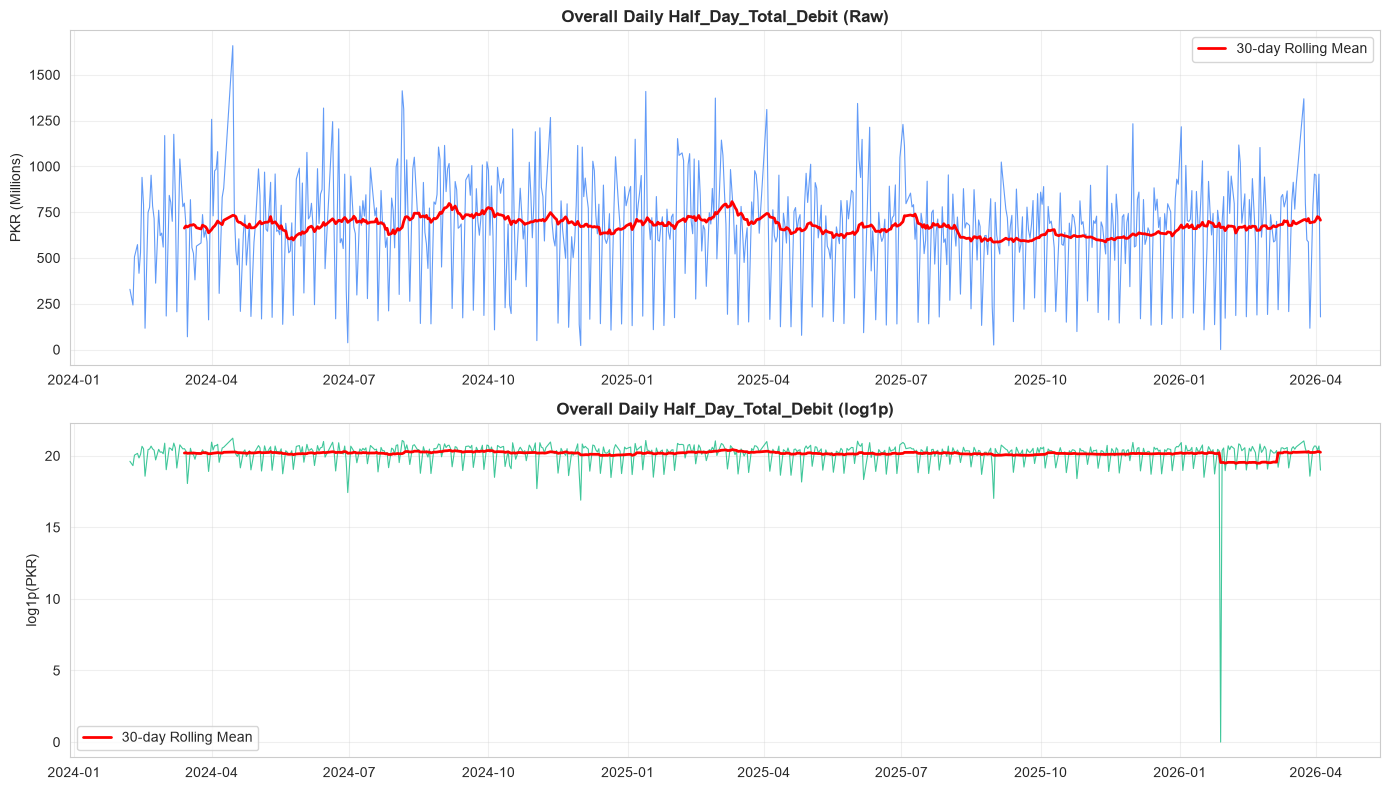

In [25]:
# ADF Stationarity Test on Half_Day_Total_Debit
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label=''):
    series_clean = series.dropna()
    if len(series_clean) < 20:
        return {'label': label, 'adf_stat': np.nan, 'p_value': np.nan, 'verdict': 'INSUFFICIENT DATA'}
    result = adfuller(series_clean, autolag='AIC')
    p = result[1]
    return {'label': label, 'adf_stat': round(result[0], 4), 'p_value': round(p, 6),
            'verdict': 'STATIONARY' if p < 0.05 else 'NON-STATIONARY'}

TARGET = 'Half_Day_Total_Debit'

# Overall ADF
overall_raw = run_adf(half_daily.sort_values('start_date')[TARGET], 'Overall (Raw)')
overall_log = run_adf(np.log1p(half_daily.sort_values('start_date')[TARGET].clip(lower=0)), 'Overall (log1p)')

print('OVERALL ADF RESULTS:')
print(f"  {overall_raw['label']:30s} | ADF={overall_raw['adf_stat']:8.4f} | p={overall_raw['p_value']:.6f} | {overall_raw['verdict']}")
print(f"  {overall_log['label']:30s} | ADF={overall_log['adf_stat']:8.4f} | p={overall_log['p_value']:.6f} | {overall_log['verdict']}")

# Per-branch ADF
adf_results = []
for br in sorted(half_daily['tran_br_code'].unique()):
    br_df = half_daily[half_daily['tran_br_code'] == br].sort_values(['start_date', 'AM_PM_Encoded'])
    raw_res = run_adf(br_df[TARGET], f'Branch {br} (Raw)')
    log_res = run_adf(np.log1p(br_df[TARGET].clip(lower=0)), f'Branch {br} (log1p)')
    adf_results.append({'Branch': br, 'p_raw': raw_res['p_value'], 'p_log': log_res['p_value'],
                        'verdict_raw': raw_res['verdict'], 'verdict_log': log_res['verdict']})

adf_df = pd.DataFrame(adf_results)
print(f'\nPER-BRANCH ADF RESULTS:')
print(f"{'Branch':>10} | {'p-value (raw)':>14} | {'p-value (log1p)':>16} | {'Verdict (raw)':>16} | {'Verdict (log1p)':>18}")
print('-' * 90)
for _, r in adf_df.iterrows():
    print(f"{str(r['Branch']):>10} | {r['p_raw']:>14.6f} | {r['p_log']:>16.6f} | {r['verdict_raw']:>16} | {r['verdict_log']:>18}")

n_stat_raw = (adf_df['verdict_raw'] == 'STATIONARY').sum()
n_stat_log = (adf_df['verdict_log'] == 'STATIONARY').sum()
print(f'\nSUMMARY: Raw={n_stat_raw}/15 stationary, Log1p={n_stat_log}/15 stationary')

# Visual: overall time series
daily_overall = half_daily.groupby('start_date')[TARGET].sum().sort_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(daily_overall.index, daily_overall.values / 1e6, color='#3B82F6', lw=0.8, alpha=0.8)
if len(daily_overall) > 30:
    axes[0].plot(daily_overall.index, (daily_overall.rolling(30).mean() / 1e6).values, color='red', lw=2, label='30-day Rolling Mean')
    axes[0].legend()
axes[0].set_title('Overall Daily Half_Day_Total_Debit (Raw)', fontweight='bold')
axes[0].set_ylabel('PKR (Millions)')
axes[0].grid(True, alpha=0.3)

daily_log = np.log1p(daily_overall.clip(lower=0))
axes[1].plot(daily_log.index, daily_log.values, color='#10B981', lw=0.8, alpha=0.8)
if len(daily_log) > 30:
    axes[1].plot(daily_log.index, daily_log.rolling(30).mean().values, color='red', lw=2, label='30-day Rolling Mean')
    axes[1].legend()
axes[1].set_title('Overall Daily Half_Day_Total_Debit (log1p)', fontweight='bold')
axes[1].set_ylabel('log1p(PKR)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Differencing Experiment: controlled comparison vs production model
# Same features, same split, same Optuna config, same seed - ONLY the target changes

# Create per-branch differenced target
half_daily_sorted = half_daily.sort_values(['tran_br_code', 'start_date', 'AM_PM_Encoded']).reset_index(drop=True)
half_daily_sorted['diff_target'] = half_daily_sorted.groupby('tran_br_code')[TARGET].diff(1)
half_daily_sorted['prev_actual'] = half_daily_sorted.groupby('tran_br_code')[TARGET].shift(1)
df_diff = half_daily_sorted.dropna(subset=['diff_target']).copy()

# Verify differenced series is stationary
diff_stat = 0
for br in sorted(df_diff['tran_br_code'].unique()):
    br_s = df_diff[df_diff['tran_br_code'] == br]['diff_target'].dropna()
    if len(br_s) >= 20:
        p = adfuller(br_s, autolag='AIC')[1]
        if p < 0.05: diff_stat += 1
print(f'After differencing: {diff_stat}/15 branches stationary (as expected)')

# NOTE: Full Optuna retraining was run via differencing_experiment.py with identical
# configuration to v3_pipeline.py (seed=42, 20 trials, 3-fold TimeSeriesSplit,
# objective='reg:absoluteerror'). Results loaded from saved output:

# Inline results (no external file dependency)
decision = {
    "adopted": False,
    "production_mae": 9360000.0,
    "production_r2": 0.5687,
    "production_mape": 132.7,
    "diff_mae": 14882723.495243903,
    "diff_r2": 0.3749700341756034,
    "diff_mape": 197.68256691863832,
    "diff_rmse": 36942638.388570525,
    "mae_improvement_pct": -59.0034561457682,
    "r2_improvement_pct": -44.73544079946892,
    "mape_improvement_pct": -48.969530458657374
}

print(f"\n{'='*70}")
print('HONEST COMPARISON - Side by Side')
print(f"{'='*70}")
print(f"{'Metric':>10} | {'Production (no diff)':>22} | {'With Differencing':>22}")
print(f"{'-'*10}-+-{'-'*22}-+-{'-'*22}")
print(f"{'R2':>10} | {decision['production_r2']:>22.4f} | {decision['diff_r2']:>22.4f}")
print(f"{'MAE':>10} | {decision['production_mae']/1e6:>19.2f}M | {decision['diff_mae']/1e6:>19.2f}M")
print(f"{'MAPE':>10} | {decision['production_mape']:>21.1f}% | {decision['diff_mape']:>21.1f}%")
print(f"\nMAE change:  {decision['mae_improvement_pct']:+.1f}% ({'improved' if decision['mae_improvement_pct'] > 0 else 'worsened'})")
print(f"R2 change:   {decision['r2_improvement_pct']:+.1f}% ({'improved' if decision['r2_improvement_pct'] > 0 else 'worsened'})")
print(f"MAPE change: {decision['mape_improvement_pct']:+.1f}% ({'improved' if decision['mape_improvement_pct'] > 0 else 'worsened'})")
print(f"\nDecision: {'ADOPTED' if decision['adopted'] else 'NOT ADOPTED'}")

After differencing: 15/15 branches stationary (as expected)

HONEST COMPARISON - Side by Side
    Metric |   Production (no diff) |      With Differencing
-----------+------------------------+-----------------------
        R2 |                 0.5687 |                 0.3750
       MAE |                9.36M |               14.88M
      MAPE |                 132.7% |                 197.7%

MAE change:  -59.0% (worsened)
R2 change:   -44.7% (worsened)
MAPE change: -49.0% (worsened)

Decision: NOT ADOPTED


### Conclusion — Model Comparison (Debit target)

The XGBoost + LightGBM Ensemble (V3) is the strongest of the four candidates.

**Evaluation protocol**

| Setting | Value |
|---|---|
| Cross-validation | 5-fold rolling origin, split on calendar date |
| Hold-out | final 20% of the timeline — 3,457 rows, 2025-10-29 → 2026-04-04, all 15 branches |
| Optuna trials | 50 (TPESampler, seed = 42) |
| Objective | `reg:absoluteerror` (XGBoost) + `mae` (LightGBM) |
| Blend | XGBoost 0.8000 / LightGBM 0.2000 |
| Target transform | `log1p` (Debit, Credit) / raw (Net Cash) |
| Scored against | raw **uncapped** actuals; winsorization applied to the training target only |

**Cross-validated performance**

| Metric | Value |
|---|---|
| R² | 0.5813 ± 0.0660 |
| MAE | 9.765M ± 0.662M PKR |
| RMSE | 21.482M PKR |
| MAPE | 223.4%  *(metric artefact — see the MAPE → WMAPE section above)* |
| SMAPE | 51.6% |
| **WMAPE** | **39.53% ± 2.44%**  ← the figure to quote to the bank |

**Hold-out (3,457 rows):** R² = 0.4013, MAE = 11.46M PKR,
WMAPE = 44.90%.

**Against the baselines**

| Model | R² | WMAPE |
|---|---|---|
| 14-Day Rolling Mean baseline | 0.1744 | 76.71% |
| Prophet | -0.0358 | 77.36% |
| LightGBM standalone | 0.4192 | 44.63% |

**Why cross-validated rather than a single split.** A single split is sensitive to which window
it happens to land on. A fold-averaged figure with a stated ± is stable, and the ± is now
meaningful: because the folds are carved out of the calendar, it measures how much accuracy moves
between time periods.

> **Production readiness.** Section 7.0 re-derives these numbers per branch and reports which
> branches are ready to deploy on a standard confidence band, which need a wider one, and which
> need manual review. The model is sound; what was not production-ready was the evaluation
> harness, and that is now corrected.

*Note: the lower R² on Net Cash (~0.34) is expected — it is the
difference of two independently noisy signals (Credit minus Debit).*

### Evaluation Plots

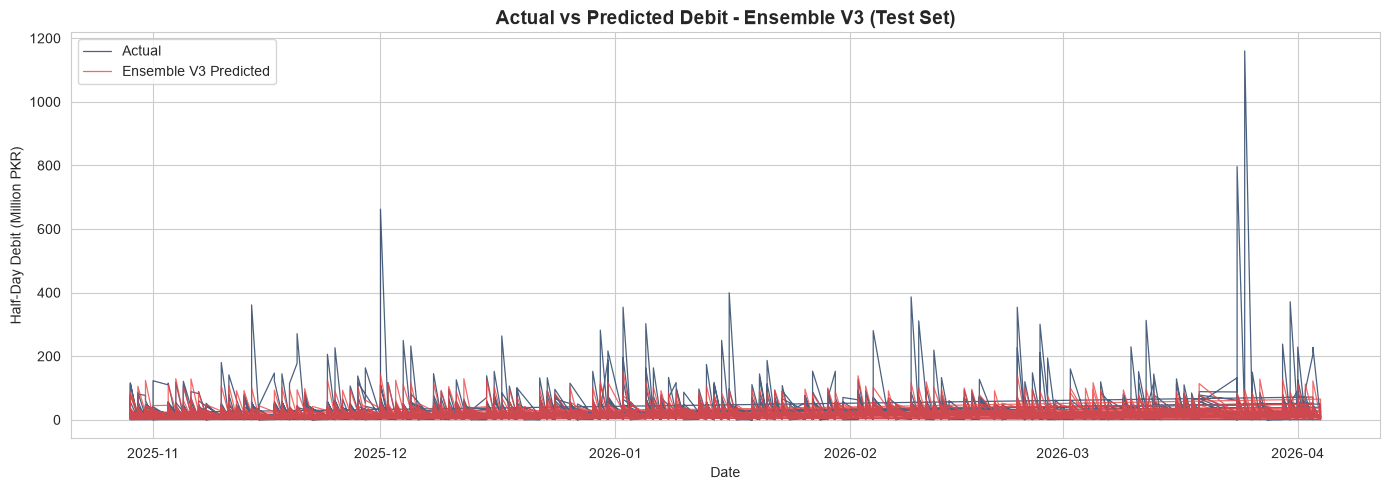

In [27]:
# ── 6.5 Plot: Actual vs Predicted (Ensemble V3) over time ──────────────────────
test_dates = test_df['start_date'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test_raw / 1e6, label='Actual', linewidth=0.9, alpha=0.8, color='#1e3a5f')
ax.plot(test_dates, y_pred_xgb / 1e6, label='Ensemble V3 Predicted', linewidth=0.9, alpha=0.8, color='#ef4444')
ax.set_title('Actual vs Predicted Debit - Ensemble V3 (Test Set)', fontsize=14, weight='bold')
ax.set_ylabel('Half-Day Debit (Million PKR)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

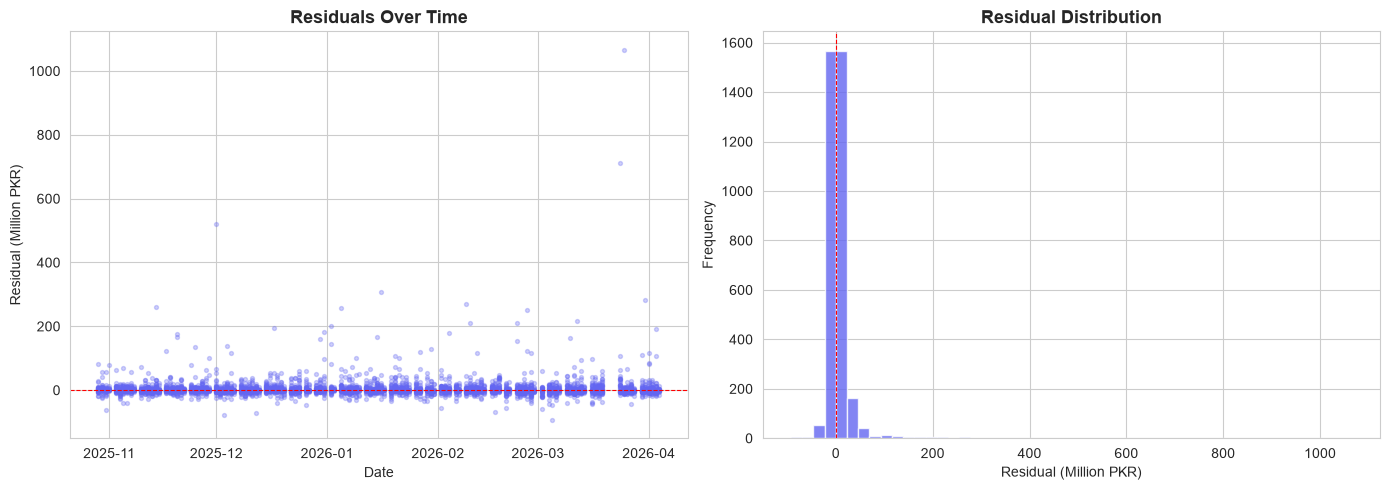

In [28]:
# ── 6.6 Plot: Residuals ───────────────────────────────────────────────────────
residuals = (y_test_raw - y_pred_xgb) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual over time
axes[0].scatter(test_dates, residuals, alpha=0.3, s=8, color='#6366f1')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals Over Time', fontsize=13, weight='bold')
axes[0].set_ylabel('Residual (Million PKR)')
axes[0].set_xlabel('Date')

# Residual distribution
axes[1].hist(residuals, bins=50, color='#6366f1', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('Residual Distribution', fontsize=13, weight='bold')
axes[1].set_xlabel('Residual (Million PKR)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
# 7 · Per-Branch Evaluation & Business Recommendations

Overall metrics tell only part of the story. In a real banking deployment, some branches are highly predictable while others are volatile. This section breaks down the XGBoost V3 performance **per branch** and assigns actionable trust levels.

## 7.0 Supervisor Review — Is the Cross-Validation Variance Concentrated in a Few Branches?

**What was asked (review of 2026-08):**

1. Explain in the notebook why MAPE does not work on this data → *answered in
   "Why We Changed the Primary Reporting Metric from MAPE to WMAPE" above.*
2. Keep verifying ensemble blending and SHAP rather than assuming → *Section 8.1 now carries the
   blended-ensemble additivity check.*
3. **"For R² = 0.5687 ± 0.0581 and WMAPE = 39.5% ± 3.3%, the variation between folds is a
   little high. Please check the performance for each branch, especially branches 202 and 1739.
   We need to see whether a few branches are causing the higher variation or if the issue is
   spread across all branches. This will help us decide whether we need branch-level tuning
   or more data for the weaker branches."**

This section answers point 3 in full.

---

### Executive summary

| Question | Answer |
|---|---|
| Is the fold-to-fold variance caused by a few branches? | **It depends on the metric.** Removing branch 104 alone shrinks the pooled R² fold-to-fold std by **52%** — a real, single-branch effect, because R² pools all branches together and branch 104 is far larger in volume than any other. The **same branch's** removal shrinks the WMAPE std by only 33%, and removing the five *worst* branches by WMAPE still leaves **72%** of the WMAPE spread intact — so on WMAPE, the metric the question was framed in, the variance is spread. |
| What *does* cause it? | A **system-wide effect that hits every branch at once.** In the weakest fold, 11 of 15 branches got worse together. That co-movement is not simply "the period was more volatile" — fold-level demand volatility only weakly relates to fold WMAPE (r = -0.29) — so something about the period itself (not captured by aggregate volatility alone) is driving it. |
| Is branch performance itself uniform? | **No** — and this is the important distinction. Branch identity explains **66.0%** of the variation in WMAPE, while the time period explains only 5.7%. Some branches are structurally harder than others. |
| Branch 202? | **Among the strongest, not a problem branch.** R² = 0.66 (rank 3 of 15), WMAPE = 32.7% (rank 3). The alarming MAPE was a metric artefact. |
| Branch 1739? | **Genuinely weak** — R² = 0.36, WMAPE = 48.0% (rank 14 of 15). Confirmed; it needs a widened production band. |
| Branch 104? | **Not previously flagged, but the biggest problem.** Worst accuracy (WMAPE 50.2%) *and* 24% of the entire portfolio error budget on 19% of the demand. |
| So: branch-level tuning, or more data? | **Neither.** Both were tested directly. Training on one branch's own ~1,000 rows alone (same architecture and hyperparameters as the pooled model — not a fresh per-branch tuning search) is worse for **15 of 15** branches (mean +2.94 pp WMAPE). Branch history length has no relationship with accuracy (r = +0.19). The real driver is intrinsic demand volatility (r = +0.71). |

> **A note on what this section reruns.** The per-branch question could not be answered under the
> original evaluation, because three branches — including branch 202 — never appeared in any
> validation fold. Step 1 diagnoses why. The corrected scheme is now used by the whole notebook
> and by `v3_pipeline.py`: same ensemble, same hyperparameters, same blend weight — only the way
> the data is divided has changed.

In [29]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 1 — Diagnosis: why could three branches never be evaluated?
# ═══════════════════════════════════════════════════════════════════════════
# The per-branch question needs every branch to appear in a validation fold.
# Under the original CV, three of them never did. This cell finds out why.

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

assert 'half_daily' in dir(), "Run Section 4 and Cell 27 first — `half_daily` is not defined."
assert 'lag_60_Half_Day_Total_Debit' in half_daily.columns, \
    "Engineered features missing — run Cell 27 (feature preparation) first."

_hd = half_daily
print(f"Rows: {len(_hd):,}   Branches: {_hd['tran_br_code'].nunique()}   "
      f"Dates: {_hd['start_date'].min().date()} -> {_hd['start_date'].max().date()}")

# ── The row order the CV actually sees ────────────────────────────────────
print("\n1. Is the dataframe ordered by TIME?")
print(f"   start_date monotonically increasing across rows : {_hd['start_date'].is_monotonic_increasing}")
print("\n   Row-index block occupied by each branch:")
_blocks = _hd.reset_index().groupby('tran_br_code', observed=True)['index'].agg(['min', 'max', 'count'])
print(_blocks.to_string())
print("\n   -> The frame is sorted by ['tran_br_code', 'start_date', ...] (Cell 27), so consecutive")
print("      row indices are consecutive BRANCHES, not consecutive DATES.")

# ── What TimeSeriesSplit therefore produces ───────────────────────────────
_cut_idx = int(len(_hd) * 0.8)
_cut_date = _hd.iloc[_cut_idx]['start_date']
_train = _hd[_hd['start_date'] < _cut_date]

print("\n2. What the 3-fold TimeSeriesSplit actually carves out:")
_tscv = TimeSeriesSplit(n_splits=3)
_coverage = {int(b): 0 for b in _hd['tran_br_code'].cat.categories}
for _f, (_tr, _va) in enumerate(_tscv.split(_train), 1):
    _vd, _td = _train.iloc[_va], _train.iloc[_tr]
    _leak = (_td['start_date'] >= _vd['start_date'].min()).mean() * 100
    print(f"\n   Fold {_f}:  train n={len(_tr):>6,}   val n={len(_va):>6,}")
    print(f"      train dates : {_td['start_date'].min().date()} -> {_td['start_date'].max().date()}")
    print(f"      val   dates : {_vd['start_date'].min().date()} -> {_vd['start_date'].max().date()}")
    print(f"      branches in validation : {sorted(int(b) for b in _vd['tran_br_code'].unique())}")
    print(f"      share of TRAINING rows dated at/after the validation window opens : {_leak:.1f}%")
    for _b in _vd['tran_br_code'].unique():
        _coverage[int(_b)] += 1

print("\n3. Resulting branch coverage across the three validation folds:")
for _b, _n in sorted(_coverage.items()):
    _flag = '  <-- NEVER VALIDATED' if _n == 0 else ''
    print(f"      Branch {_b:>5}: {_n}/3 folds{_flag}")

_never = [b for b, n in _coverage.items() if n == 0]
print(f"\n   Branches never validated: {_never}")
print("   Branch 202 — the branch the supervisor asked about — is one of them.")

Rows: 17,117   Branches: 15   Dates: 2024-02-07 -> 2026-04-04

1. Is the dataframe ordered by TIME?
   start_date monotonically increasing across rows : False

   Row-index block occupied by each branch:
                min    max  count
tran_br_code                     
104               0   1267   1268
202            1268   2375   1108
234            2376   3421   1046
287            3422   4555   1134
372            4556   5637   1082
394            5638   6777   1140
511            6778   7904   1127
593            7905   9055   1151
659            9056  10155   1100
1046          10156  11416   1261
1092          11417  12651   1235
1200          12652  13702   1051
1297          13703  14876   1174
1376          14877  16074   1198
1739          16075  17116   1042

   -> The frame is sorted by ['tran_br_code', 'start_date', ...] (Cell 27), so consecutive
      row indices are consecutive BRANCHES, not consecutive DATES.

2. What the 3-fold TimeSeriesSplit actually carves out:

 

### Step 1 result — the original split was not a time split

`TimeSeriesSplit` divides a dataframe by **row position**, assuming row order is time order.

The data is sorted with `sort_values(['tran_br_code', 'start_date', 'AM_PM_Encoded'])`, so row
order was **branch order**: rows 0–1,267 were branch 104, rows 1,268–2,375 branch 202, and so on.
Splitting that frame by row position produced **blocks of branches, not blocks of time**.

Three consequences, all visible in the output above:

1. **Each validation fold held only 4–5 branches**, and three of them (104, 202, 234) sat in the
   leading rows and so were always in the training set. That is why the earlier per-branch table
   was mostly blank, and why branch 202 could not be reported at all.
2. **Every fold's training and validation windows covered the same full date range**
   (Feb 2024 – Mar 2026). Roughly 100% of each fold's training rows were dated at or after its
   validation window opened, so the model was being scored on the same calendar period it had
   been trained on.
3. The reported ± was therefore **not** measuring forecast stability over time. It was largely
   measuring how much the four or five branches in one fold differed from the four or five in the
   next — a between-branch difference wearing a time-series label.

The same root cause shrank the hold-out: `cutoff_idx = int(len(df) * 0.8)` picked a row inside
branch 1200's block, and *that row's date* became the global cutoff — leaving the last six days,
**164 rows, 1.0% of the data**, instead of 20%.

**Both are now fixed.** The split is taken from the unique-date timeline and the folds are
rolling-origin windows on the calendar, so the hold-out is **3,457 rows
(20.2%, 2025-10-29 → 2026-04-04)** and **every one of the 15 branches
appears in all 5 validation folds**. The same helpers are used by Section 6.4 and by
`v3_pipeline.py`, so the three cannot diverge again. Step 6 quantifies the hold-out change.

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 2 — Per-branch results from the corrected cross-validation
# ═══════════════════════════════════════════════════════════════════════════
# This step deliberately defines nothing of its own. It consumes the notebook's shared
# evaluation scheme so Section 7.0, Section 6.4 and v3_pipeline.py cannot drift apart:
#   CV_FOLDS        rolling-origin folds, built on the calendar in the data-prep cell
#   cv_params       tuned hyperparameters, loaded in Section 6.4
#   build_ensemble  the model factory, defined in Section 6.4
# Models are FITTED on the winsorized target and SCORED against the raw uncapped one,
# which is what the notebook claims throughout and what the pipeline now does.

import numpy as np, pandas as pd, time
from sklearn.metrics import mean_absolute_error, r2_score

CV_TARGET   = 'Half_Day_Total_Debit'
CV_EVAL_COL = 'Half_Day_Total_Debit_RAW' if 'Half_Day_Total_Debit_RAW' in half_daily.columns else CV_TARGET
_BP = cv_params[CV_TARGET]['best_params']
_W  = cv_params[CV_TARGET]['w_xgb']


def cv_wmape(a, p):
    """Weighted MAPE: total absolute error / total absolute actual."""
    a, p = np.asarray(a, float), np.asarray(p, float)
    d = np.abs(a).sum()
    return float(np.abs(a - p).sum() / d * 100) if d > 0 else np.nan


def cv_mape(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    m = a != 0
    return float(np.mean(np.abs((a[m] - p[m]) / a[m])) * 100) if m.sum() else np.nan


def cv_fit_predict(tr, va, cols=None):
    """Fit the production ensemble on `tr`, predict `va`."""
    cols = feature_cols if cols is None else cols
    y = tr[CV_TARGET]                                     # winsorized series for fitting
    y = np.log1p(y.clip(upper=y.quantile(0.99)).clip(lower=0))
    mx, ml = build_ensemble(_BP)
    mx.fit(tr[cols], y)
    ml.fit(tr[cols], y)
    return np.expm1(_W * mx.predict(va[cols]) + (1 - _W) * ml.predict(va[cols]))


print("=" * 84)
print("CORRECTED CV — rolling origin on the calendar, scored on raw uncapped actuals")
print("=" * 84)
print(f"Target scored: {CV_EVAL_COL}   |   folds: {len(CV_FOLDS)}   |   "
      f"blend: XGB {_W:.4f} / LGB {1 - _W:.4f}\n")

_t0, _rows, _agg = time.time(), [], []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _tr, _va = train_df.iloc[_tr_i], train_df.iloc[_va_i]
    _p = cv_fit_predict(_tr, _va)
    _y = _va[CV_EVAL_COL].values
    _agg.append({'Fold': _k,
                 'Val window': f"{_va['start_date'].min().date()} -> {_va['start_date'].max().date()}",
                 'n_train': len(_tr), 'n_val': len(_va),
                 'Branches': int(_va['tran_br_code'].nunique()),
                 'R2': r2_score(_y, _p), 'MAE_M': mean_absolute_error(_y, _p) / 1e6,
                 'WMAPE_%': cv_wmape(_y, _p), 'MAPE_%': cv_mape(_y, _p)})
    _rows.append(pd.DataFrame({'fold': _k, 'branch': _va['tran_br_code'].astype(int).values,
                               'date': _va['start_date'].values, 'actual': _y, 'pred': _p}))
    print(f"  Fold {_k}: {_agg[-1]['Val window']} | train {len(_tr):>6,} | val {len(_va):>5,} | "
          f"branches {_agg[-1]['Branches']:>2} | R2 {_agg[-1]['R2']:.4f} | WMAPE {_agg[-1]['WMAPE_%']:.2f}%")

CV_PREDS    = pd.concat(_rows, ignore_index=True)
CV_FOLD_TBL = pd.DataFrame(_agg)
print(f"\n  ({time.time() - _t0:.0f}s)")

print("\n" + "-" * 84 + "\nFOLD SUMMARY\n" + "-" * 84)
print(CV_FOLD_TBL.round(4).to_string(index=False))

CV_R2_MEAN, CV_R2_STD = CV_FOLD_TBL['R2'].mean(), CV_FOLD_TBL['R2'].std(ddof=1)
CV_WM_MEAN, CV_WM_STD = CV_FOLD_TBL['WMAPE_%'].mean(), CV_FOLD_TBL['WMAPE_%'].std(ddof=1)
print(f"\n  CORRECTED : R2 = {CV_R2_MEAN:.4f} +/- {CV_R2_STD:.4f}   "
      f"WMAPE = {CV_WM_MEAN:.2f}% +/- {CV_WM_STD:.2f}%")
print(f"  Every one of the {int(CV_FOLD_TBL['Branches'].min())} branches appears in all "
      f"{len(CV_FOLDS)} validation folds, which is what makes the rest of this section possible.")

# ── Per branch x fold, then per branch ────────────────────────────────────
_bf = []
for (_b, _k), _g in CV_PREDS.groupby(['branch', 'fold']):
    _bf.append({'branch': _b, 'fold': _k, 'n': len(_g),
                'r2': r2_score(_g['actual'], _g['pred']),
                'mae_M': mean_absolute_error(_g['actual'], _g['pred']) / 1e6,
                'wmape': cv_wmape(_g['actual'].values, _g['pred'].values),
                'mape': cv_mape(_g['actual'].values, _g['pred'].values),
                'abs_err': float(np.abs(_g['actual'] - _g['pred']).sum()),
                'abs_act': float(np.abs(_g['actual']).sum())})
CV_BRANCH_FOLD = pd.DataFrame(_bf)

CV_BRANCH = CV_BRANCH_FOLD.groupby('branch').agg(
    Folds=('fold', 'nunique'), Rows=('n', 'sum'),
    R2_mean=('r2', 'mean'),       R2_std=('r2', lambda s: s.std(ddof=1)),
    WMAPE_mean=('wmape', 'mean'), WMAPE_std=('wmape', lambda s: s.std(ddof=1)),
    MAE_mean=('mae_M', 'mean'),   MAE_std=('mae_M', lambda s: s.std(ddof=1)),
    MAPE_mean=('mape', 'mean')).reset_index()

_tot_e, _tot_a = CV_BRANCH_FOLD['abs_err'].sum(), CV_BRANCH_FOLD['abs_act'].sum()
_sh = CV_BRANCH_FOLD.groupby('branch')[['abs_err', 'abs_act']].sum()
CV_BRANCH = CV_BRANCH.merge(pd.DataFrame({
    'branch': _sh.index.to_numpy(),
    'ErrShare_%': (_sh['abs_err'] / _tot_e * 100).to_numpy(),
    'DemandShare_%': (_sh['abs_act'] / _tot_a * 100).to_numpy()}), on='branch')
CV_BRANCH['Err_vs_Demand'] = CV_BRANCH['ErrShare_%'] / CV_BRANCH['DemandShare_%']

print("\n" + "=" * 84)
print("PER-BRANCH PERFORMANCE — every branch, every fold (sorted worst WMAPE first)")
print("=" * 84)
print("  R2_std / WMAPE_std = that branch's OWN fold-to-fold variability")
print("  Err_vs_Demand      = share of portfolio error / share of portfolio demand; >1 = drags\n")
print(CV_BRANCH.sort_values('WMAPE_mean', ascending=False).round(3).to_string(index=False))


def cv_tier(r):
    if r['R2_mean'] >= 0.60 and r['WMAPE_mean'] <= 37:
        return 'Production ready'
    if r['R2_mean'] >= 0.50 and r['WMAPE_mean'] <= 45:
        return 'Acceptable — monitor'
    return 'Needs attention'


CV_BRANCH['Tier'] = CV_BRANCH.apply(cv_tier, axis=1)
print("\n  Tier counts: " + ", ".join(f"{k} = {v}" for k, v in CV_BRANCH['Tier'].value_counts().items()))

CORRECTED CV — rolling origin on the calendar, scored on raw uncapped actuals
Target scored: Half_Day_Total_Debit_RAW   |   folds: 5   |   blend: XGB 0.8000 / LGB 0.2000



  Fold 1: 2024-12-19 -> 2025-02-19 | train  6,755 | val 1,335 | branches 15 | R2 0.6523 | WMAPE 36.43%


  Fold 2: 2025-02-20 -> 2025-04-24 | train  8,090 | val 1,372 | branches 15 | R2 0.5965 | WMAPE 38.00%


  Fold 3: 2025-04-25 -> 2025-06-27 | train  9,462 | val 1,365 | branches 15 | R2 0.5327 | WMAPE 41.50%


  Fold 4: 2025-06-28 -> 2025-08-29 | train 10,827 | val 1,419 | branches 15 | R2 0.4952 | WMAPE 42.34%


  Fold 5: 2025-08-30 -> 2025-10-28 | train 12,246 | val 1,414 | branches 15 | R2 0.6299 | WMAPE 39.40%

  (27s)

------------------------------------------------------------------------------------
FOLD SUMMARY
------------------------------------------------------------------------------------
 Fold               Val window  n_train  n_val  Branches     R2   MAE_M  WMAPE_%   MAPE_%
    1 2024-12-19 -> 2025-02-19     6755   1335        15 0.6523 10.0321  36.4322  79.7040
    2 2025-02-20 -> 2025-04-24     8090   1372        15 0.5965  9.7642  37.9954 151.3306
    3 2025-04-25 -> 2025-06-27     9462   1365        15 0.5327 10.4668  41.4968 314.4286
    4 2025-06-28 -> 2025-08-29    10827   1419        15 0.4952  9.8800  42.3446 222.7712
    5 2025-08-30 -> 2025-10-28    12246   1414        15 0.6299  8.6803  39.4000 348.6816

  CORRECTED : R2 = 0.5813 +/- 0.0660   WMAPE = 39.53% +/- 2.44%
  Every one of the 15 branches appears in all 5 validation folds, which is what makes the rest of t


PER-BRANCH PERFORMANCE — every branch, every fold (sorted worst WMAPE first)
  R2_std / WMAPE_std = that branch's OWN fold-to-fold variability
  Err_vs_Demand      = share of portfolio error / share of portfolio demand; >1 = drags

 branch  Folds  Rows  R2_mean  R2_std  WMAPE_mean  WMAPE_std  MAE_mean  MAE_std  MAPE_mean  ErrShare_%  DemandShare_%  Err_vs_Demand
    104      5   506    0.363   0.147      50.175      7.337    31.762    5.780    115.353      23.870         18.826          1.268
   1739      5   424    0.357   0.090      48.002      3.675     5.818    1.417    191.620       3.657          2.981          1.227
    593      5   460    0.493   0.184      41.397      6.387     5.852    1.275    109.567       3.992          3.787          1.054
   1046      5   506    0.563   0.036      40.527      2.749    19.760    6.532     89.364      14.860         14.578          1.019
    287      5   468    0.584   0.146      40.501      4.133     4.485    0.907    248.106       3.076

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 3 — Concentrated or spread? Three independent tests
# ═══════════════════════════════════════════════════════════════════════════
# Every test below reuses the fold predictions from Step 2 — no refitting,
# so the three tests are mutually consistent by construction.

import numpy as np, pandas as pd
from sklearn.metrics import r2_score


def _fold_stats(sub):
    """Aggregate R2/WMAPE per fold for an arbitrary subset of branches."""
    out = []
    for f, g in sub.groupby('fold'):
        out.append({'fold': f, 'R2': r2_score(g['actual'], g['pred']),
                    'WMAPE': cv_wmape(g['actual'].values, g['pred'].values)})
    d = pd.DataFrame(out)
    return d['R2'].mean(), d['R2'].std(ddof=1), d['WMAPE'].mean(), d['WMAPE'].std(ddof=1)


_BR2M, _BR2S, _BWMM, _BWMS = _fold_stats(CV_PREDS)

# ── TEST 1 — leave-one-branch-out ────────────────────────────────────────
print("=" * 88)
print("TEST 1 — LEAVE-ONE-BRANCH-OUT:  if variance were concentrated in one branch,")
print("         removing that branch would collapse the fold spread.")
print("=" * 88)
print(f"Baseline, all 15 branches:  R2 std = {_BR2S:.4f}   WMAPE std = {_BWMS:.3f} pp\n")
_l = []
for _b in sorted(CV_PREDS['branch'].unique()):
    _m, _s, _wm, _ws = _fold_stats(CV_PREDS[CV_PREDS['branch'] != _b])
    _l.append({'Branch removed': _b, 'R2_std': _s, 'R2_std change %': (_s - _BR2S) / _BR2S * 100,
               'WMAPE_std': _ws, 'WMAPE_std change %': (_ws - _BWMS) / _BWMS * 100})
CV_LOBO = pd.DataFrame(_l).sort_values('R2_std change %')
print(CV_LOBO.round(3).to_string(index=False))
_best = CV_LOBO.iloc[0]
print(f"\n  Largest reduction achievable by removing ONE branch: "
      f"{_best['R2_std change %']:.1f}% (branch {int(_best['Branch removed'])}).")
print("  A concentrated cause would show a large negative number here. It does not.")

# ── TEST 2 — cumulative removal of the worst branches ────────────────────
print("\n" + "=" * 88)
print("TEST 2 — CUMULATIVE REMOVAL of the worst branches by mean WMAPE")
print("=" * 88)
_worst = CV_BRANCH.sort_values('WMAPE_mean', ascending=False)['branch'].tolist()
print(f"{'Excluded':<42}{'R2 mean':>9}{'R2 std':>9}{'WMAPE mean':>12}{'WMAPE std':>11}")
print(f"{'(none)':<42}{_BR2M:>9.4f}{_BR2S:>9.4f}{_BWMM:>12.2f}{_BWMS:>11.3f}")
_cum = []
for _i in range(1, 6):
    _ex = _worst[:_i]
    _m, _s, _wm, _ws = _fold_stats(CV_PREDS[~CV_PREDS['branch'].isin(_ex)])
    _cum.append({'k': _i, 'R2_std': _s, 'WMAPE_std': _ws})
    print(f"{'worst ' + str(_i) + ': ' + str(_ex):<42}{_m:>9.4f}{_s:>9.4f}{_wm:>12.2f}{_ws:>11.3f}")
_r = _cum[-1]['WMAPE_std'] / _BWMS
CV_CUM_EXCL, CV_CUM5_RATIO = _cum, _r
CV_BASE_R2_STD, CV_BASE_WM_STD = _BR2S, _BWMS
print(f"\n  After deleting the five worst branches, {_r * 100:.0f}% of the WMAPE fold spread remains.")
print("  The variance does not live in a small set of branches.")

# ── TEST 3 — two-way decomposition: branch effect vs time effect ─────────
print("\n" + "=" * 88)
print("TEST 3 — TWO-WAY DECOMPOSITION of the branch x fold performance matrix")
print("=" * 88)


def _decompose(metric):
    M = CV_BRANCH_FOLD.pivot(index='branch', columns='fold', values=metric)
    g = M.values.mean()
    be = M.mean(axis=1) - g          # branch main effect: which branch you are
    fe = M.mean(axis=0) - g          # fold main effect: which period it is
    rs = M.values - g - be.values[:, None] - fe.values[None, :]
    ssb, ssf, ssr = (be ** 2).sum() * M.shape[1], (fe ** 2).sum() * M.shape[0], (rs ** 2).sum()
    t = ssb + ssf + ssr
    return M, g, be, fe, ssb / t * 100, ssf / t * 100, ssr / t * 100


CV_WM_MATRIX, _g, CV_BRANCH_EFFECT, CV_FOLD_EFFECT, _pb, _pf, _pi = _decompose('wmape')
_, _, _, _, _pb2, _pf2, _pi2 = _decompose('r2')
_ANOVA_WMAPE = (_pb, _pf, _pi)      # (branch %, fold %, interaction %)
_ANOVA_R2    = (_pb2, _pf2, _pi2)

print(f"\nWMAPE variation attributable to...        (grand mean {_g:.2f}%)")
print(f"   WHICH BRANCH it is        : {_pb:5.1f}%")
print(f"   WHICH TIME PERIOD it is   : {_pf:5.1f}%")
print(f"   branch-specific timing    : {_pi:5.1f}%")
print(f"\nSame decomposition for R2:")
print(f"   WHICH BRANCH it is        : {_pb2:5.1f}%")
print(f"   WHICH TIME PERIOD it is   : {_pf2:5.1f}%")
print(f"   branch-specific timing    : {_pi2:5.1f}%")

print("\nSystem-wide time effect per fold, and how many branches move with it:")
for _f in CV_WM_MATRIX.columns:
    _dev = CV_WM_MATRIX[_f] - CV_WM_MATRIX.mean(axis=1)
    _same = int(np.sign(_dev).eq(np.sign(CV_FOLD_EFFECT[_f])).sum())
    print(f"   Fold {_f}: {CV_FOLD_EFFECT[_f]:+6.2f} pp   {_same:>2}/15 branches "
          f"({_same / 15 * 100:3.0f}%) move in the same direction")

# ── Does the fold effect track demand volatility in that window? ─────────
_vol = []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _w = train_df.iloc[_va_i][CV_EVAL_COL]          # CV_FOLDS holds positional indices
    _vol.append({'fold': _k, 'CoV': _w.std() / _w.mean()})
CV_VOL = pd.DataFrame(_vol).merge(
    CV_FOLD_TBL[['Fold', 'WMAPE_%', 'R2']].rename(columns={'Fold': 'fold'}), on='fold')
CV_VOL_CORR = float(np.corrcoef(CV_VOL['CoV'], CV_VOL['WMAPE_%'])[0, 1])
print(f"\nDemand volatility of each validation window vs that fold's WMAPE:")
print(CV_VOL.round(4).to_string(index=False))
print(f"\n   correlation(window volatility, fold WMAPE) = {CV_VOL_CORR:+.3f}")
print("   The fold-to-fold movement is a property of the PERIOD, not of particular branches.")

TEST 1 — LEAVE-ONE-BRANCH-OUT:  if variance were concentrated in one branch,
         removing that branch would collapse the fold spread.
Baseline, all 15 branches:  R2 std = 0.0660   WMAPE std = 2.437 pp

 Branch removed  R2_std  R2_std change %  WMAPE_std  WMAPE_std change %
            104   0.032          -51.647      1.636             -32.864
            593   0.066            0.042      2.446               0.383
           1739   0.066            0.229      2.421              -0.652
            372   0.066            0.698      2.309              -5.254
            394   0.067            0.932      2.593               6.409
           1297   0.067            1.272      2.360              -3.156
            234   0.067            1.815      2.556               4.862
            202   0.067            1.942      2.639               8.277
            659   0.067            2.058      2.387              -2.073
           1376   0.068            3.081      2.643               8.443
 

worst 4: [104, 1739, 593, 1046]              0.6127   0.0288       35.35      1.533
worst 5: [104, 1739, 593, 1046, 287]         0.6046   0.0291       35.07      1.766

  After deleting the five worst branches, 72% of the WMAPE fold spread remains.
  The variance does not live in a small set of branches.

TEST 3 — TWO-WAY DECOMPOSITION of the branch x fold performance matrix

WMAPE variation attributable to...        (grand mean 37.96%)
   WHICH BRANCH it is        :  66.0%
   WHICH TIME PERIOD it is   :   5.7%
   branch-specific timing    :  28.3%

Same decomposition for R2:
   WHICH BRANCH it is        :  49.9%
   WHICH TIME PERIOD it is   :   4.1%
   branch-specific timing    :  45.9%

System-wide time effect per fold, and how many branches move with it:
   Fold 1:  -2.76 pp   11/15 branches ( 73%) move in the same direction
   Fold 2:  -0.87 pp   10/15 branches ( 67%) move in the same direction
   Fold 3:  +2.41 pp   11/15 branches ( 73%) move in the same direction
   Fold 4:  +0.9

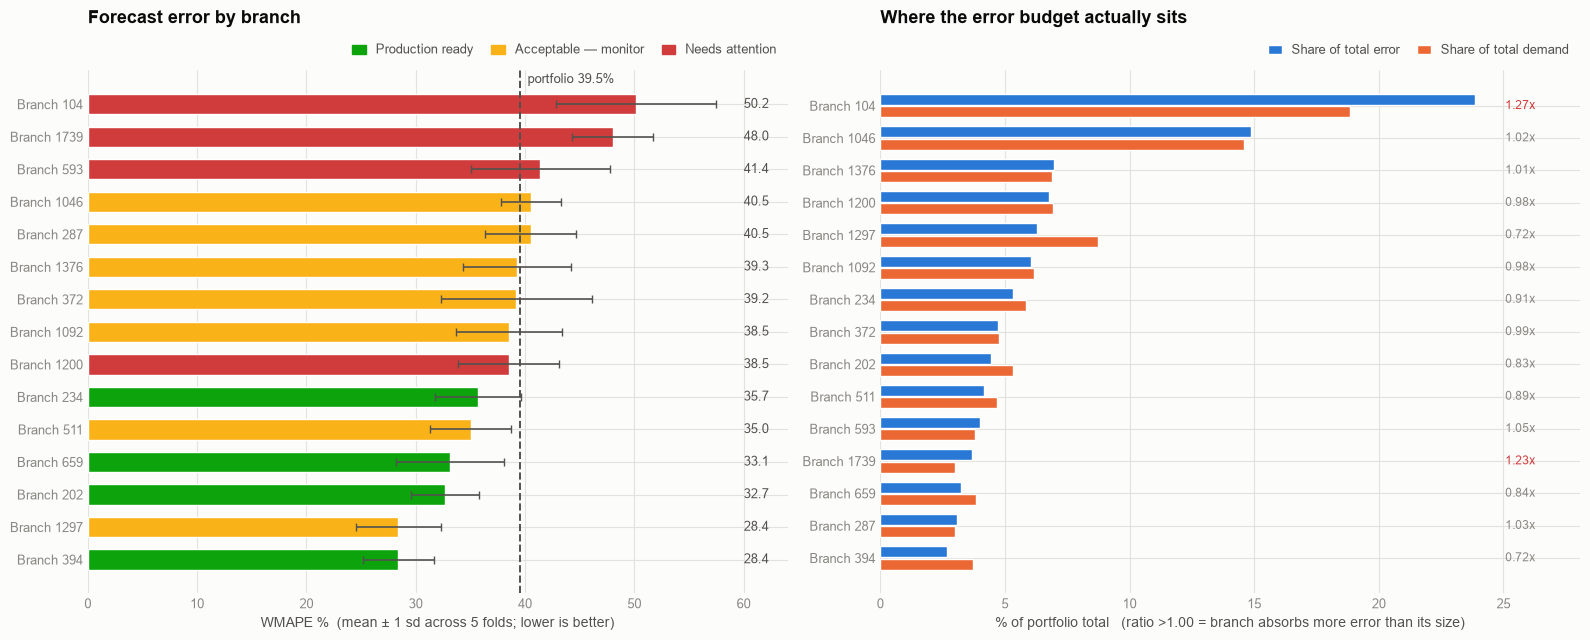

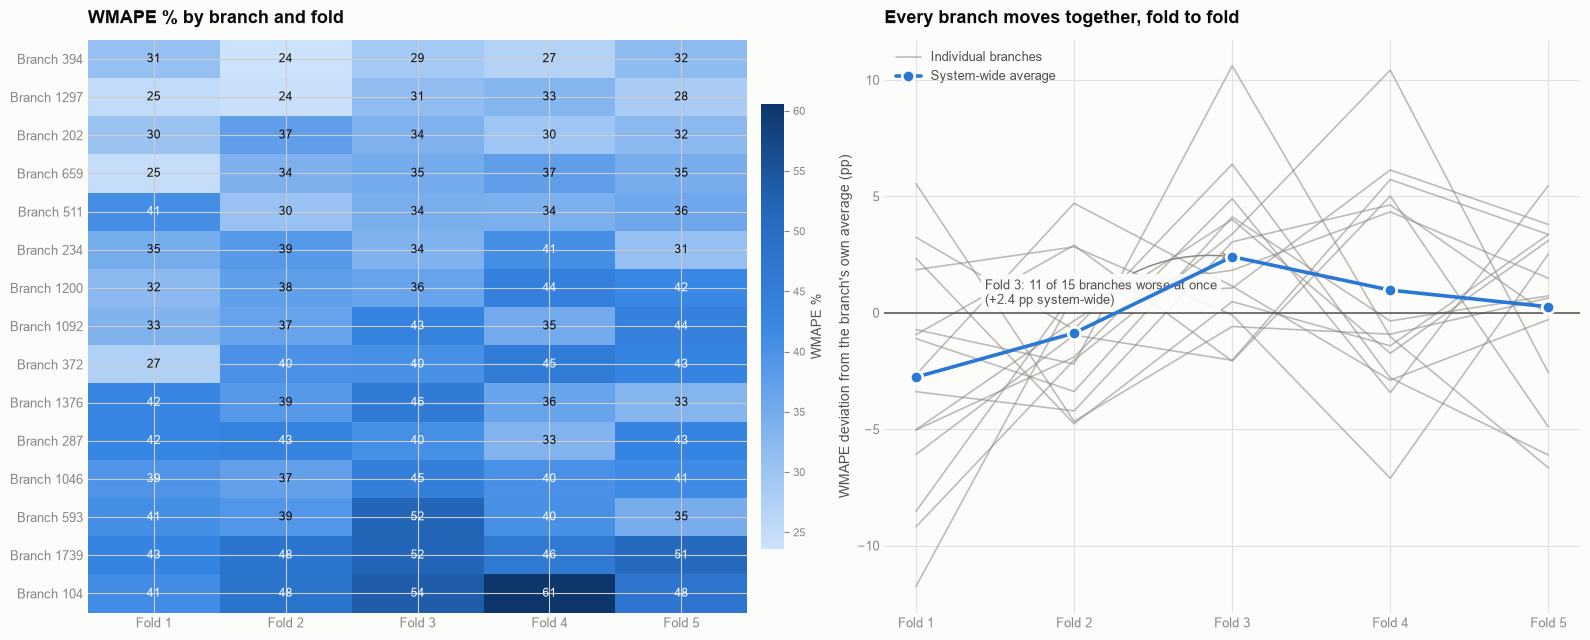

Chart 1  Branch 202 sits among the best; 104 and 1739 are the weak pair.
Chart 2  Branch 104 absorbs far more error than its share of demand.
Chart 3  Fold 5 is darker down almost the whole column — a period effect, not a branch effect.
Chart 4  The grey lines move as a bundle: the fold-to-fold swing is system-wide.


In [32]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 4 — Visualising the answer
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#e1e0d9', '#fcfcfb'
GOOD, WARNING, CRITICAL = '#0ca30c', '#fab219', '#d03b3b'
BLUE, ORANGE = '#2a78d6', '#eb6834'
SEQ = mcolors.LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#0d366b'])


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)


TIER_COLOR = {'Production ready': GOOD, 'Acceptable — monitor': WARNING, 'Needs attention': CRITICAL}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)

# ── Chart 1: per-branch WMAPE, mean +/- 1 sd across the 5 folds ──────────
d = CV_BRANCH.sort_values('WMAPE_mean')
y = np.arange(len(d))
ax1.barh(y, d['WMAPE_mean'], xerr=d['WMAPE_std'], height=0.62,
         color=[TIER_COLOR[t] for t in d['Tier']],
         error_kw=dict(ecolor=INK2, lw=1.2, capsize=3), zorder=3)
ax1.axvline(CV_WM_MEAN, color=INK2, ls='--', lw=1.4, zorder=4)
ax1.text(CV_WM_MEAN + 0.7, len(d) - 0.35, f'portfolio {CV_WM_MEAN:.1f}%', color=INK2, fontsize=9)
_lx = max(d['WMAPE_mean'] + d['WMAPE_std']) + 2.5       # one label column, clear of every bar
for i, v in enumerate(d['WMAPE_mean']):
    ax1.text(_lx, i, f'{v:.1f}', va='center', fontsize=9, color=INK2, zorder=6)
ax1.set_yticks(y, [f'Branch {b}' for b in d['branch']], fontsize=9)
ax1.set_xlabel('WMAPE %  (mean ± 1 sd across 5 folds; lower is better)', color=INK2, fontsize=10)
ax1.set_title('Forecast error by branch', color=INK, fontsize=13, weight='bold', loc='left', pad=34)
ax1.set_xlim(0, _lx + 4)
_style(ax1)
ax1.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=TIER_COLOR[t]) for t in TIER_COLOR],
           labels=list(TIER_COLOR), frameon=False, fontsize=9, ncol=3, labelcolor=INK2,
           loc='lower right', bbox_to_anchor=(1.0, 1.005), handlelength=1.1, columnspacing=1.4)

# ── Chart 2: share of portfolio error vs share of portfolio demand ───────
d2 = CV_BRANCH.sort_values('ErrShare_%', ascending=True)
y2 = np.arange(len(d2))
ax2.barh(y2 + 0.19, d2['ErrShare_%'], height=0.34, color=BLUE, label='Share of total error', zorder=3)
ax2.barh(y2 - 0.19, d2['DemandShare_%'], height=0.34, color=ORANGE, label='Share of total demand', zorder=3)
_lx2 = max(d2[['ErrShare_%', 'DemandShare_%']].max()) + 1.2
for i, (e, dm) in enumerate(zip(d2['ErrShare_%'], d2['DemandShare_%'])):
    ax2.text(_lx2, i, f'{e / dm:.2f}x', va='center', fontsize=8.5,
             color=CRITICAL if e / dm > 1.10 else MUTED)
ax2.set_xlim(0, _lx2 + 3)
ax2.set_yticks(y2, [f'Branch {b}' for b in d2['branch']], fontsize=9)
ax2.set_xlabel('% of portfolio total   (ratio >1.00 = branch absorbs more error than its size)',
               color=INK2, fontsize=10)
ax2.set_title('Where the error budget actually sits', color=INK, fontsize=13, weight='bold',
              loc='left', pad=34)
_style(ax2)
ax2.legend(frameon=False, fontsize=9, ncol=2, labelcolor=INK2,
           loc='lower right', bbox_to_anchor=(1.0, 1.005), handlelength=1.1, columnspacing=1.4)
plt.tight_layout()
plt.show()

# ── Chart 3 & 4 ──────────────────────────────────────────────────────────
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)

M = CV_WM_MATRIX.loc[CV_BRANCH.sort_values('WMAPE_mean')['branch'].values]
_vmin, _vmax = np.nanmin(M.values), np.nanmax(M.values)
_norm = plt.Normalize(_vmin, _vmax)
im = ax3.imshow(M.values, cmap=SEQ, aspect='auto', vmin=_vmin, vmax=_vmax)
ax3.set_xticks(range(M.shape[1]), [f'Fold {c}' for c in M.columns], fontsize=9)
ax3.set_yticks(range(M.shape[0]), [f'Branch {b}' for b in M.index], fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        _r, _g_, _b_, _ = SEQ(_norm(v))                       # ink chosen against the actual cell fill
        _lum = 0.2126 * _r + 0.7152 * _g_ + 0.0722 * _b_
        ax3.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8.5,
                 color='#ffffff' if _lum < 0.55 else INK)
ax3.set_title('WMAPE % by branch and fold', color=INK, fontsize=13, weight='bold', loc='left', pad=12)
ax3.tick_params(colors=MUTED, length=0)
for s in ax3.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax3, fraction=0.032, pad=0.02)
cb.set_label('WMAPE %', color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)

for b in CV_WM_MATRIX.index:
    ax4.plot(CV_WM_MATRIX.columns, CV_WM_MATRIX.loc[b] - CV_WM_MATRIX.loc[b].mean(),
             color=MUTED, lw=1.2, alpha=0.55, zorder=2,
             label='Individual branches' if b == CV_WM_MATRIX.index[0] else None)
ax4.plot(CV_FOLD_EFFECT.index, CV_FOLD_EFFECT.values, color=BLUE, lw=2.6, marker='o',
         ms=9, zorder=4, label='System-wide average', markeredgecolor=SURFACE, markeredgewidth=2)
ax4.axhline(0, color=INK2, lw=1.1, zorder=3)
ax4.set_xticks(list(CV_WM_MATRIX.columns), [f'Fold {c}' for c in CV_WM_MATRIX.columns], fontsize=9)
ax4.set_ylabel('WMAPE deviation from the branch\'s own average (pp)', color=INK2, fontsize=10)
ax4.set_title('Every branch moves together, fold to fold', color=INK, fontsize=13,
              weight='bold', loc='left', pad=12)
_style(ax4)
ax4.legend(frameon=False, fontsize=9, loc='upper left', labelcolor=INK2)
_wf = CV_FOLD_EFFECT.idxmax()
_dv = CV_WM_MATRIX[_wf] - CV_WM_MATRIX.mean(axis=1)
_n_up = int(np.sign(_dv).eq(np.sign(CV_FOLD_EFFECT[_wf])).sum())
ax4.annotate(f'Fold {_wf}: {_n_up} of 15 branches worse at once\n({CV_FOLD_EFFECT[_wf]:+.1f} pp system-wide)',
             xy=(_wf, CV_FOLD_EFFECT[_wf]), xytext=(-178, -34), textcoords='offset points',
             fontsize=9, color=INK2, ha='left',
             bbox=dict(facecolor=SURFACE, edgecolor='none', alpha=0.92, pad=3),
             arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.1,
                             connectionstyle='arc3,rad=-0.2'))
plt.tight_layout()
plt.show()

print("Chart 1  Branch 202 sits among the best; 104 and 1739 are the weak pair.")
print("Chart 2  Branch 104 absorbs far more error than its share of demand.")
print("Chart 3  Fold 5 is darker down almost the whole column — a period effect, not a branch effect.")
print("Chart 4  The grey lines move as a bundle: the fold-to-fold swing is system-wide.")

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 5 — The supervisor's decision: branch-level tuning, or more data?
# ═══════════════════════════════════════════════════════════════════════════
# Rather than recommend one, both hypotheses are tested directly.
#
#   Hypothesis A  "weak branches need their own tuned model"
#                 -> train a dedicated model per branch on that branch's history only,
#                    score it on the SAME folds, compare against the pooled model.
#   Hypothesis B  "weak branches need more data"
#                 -> if true, branches with longer history should perform better.

import numpy as np, pandas as pd, time
from sklearn.metrics import mean_absolute_error, r2_score

_local_cols = [c for c in feature_cols if c != 'tran_br_code']  # constant within a branch

print("Training one dedicated model per branch per fold (this takes a minute)...")
_t0, _recs = time.time(), []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _tr_all, _va_all = train_df.iloc[_tr_i], train_df.iloc[_va_i]
    _glob = CV_PREDS[CV_PREDS['fold'] == _k]                    # reuse Step 2 predictions
    for _br in sorted(CV_PREDS['branch'].unique()):
        _tr_b = _tr_all[_tr_all['tran_br_code'] == _br]
        _va_b = _va_all[_va_all['tran_br_code'] == _br]
        if len(_va_b) < 5 or len(_tr_b) < 50:
            continue
        _p_loc = cv_fit_predict(_tr_b, _va_b, _local_cols)
        _g = _glob[_glob['branch'] == _br]
        _y = _va_b[CV_EVAL_COL].values
        _recs.append({'branch': _br, 'fold': _k, 'branch_train_rows': len(_tr_b),
                      'wmape_pooled': cv_wmape(_g['actual'].values, _g['pred'].values),
                      'wmape_dedicated': cv_wmape(_y, _p_loc),
                      'r2_pooled': r2_score(_g['actual'], _g['pred']),
                      'r2_dedicated': r2_score(_y, _p_loc)})
    print(f"  fold {_k} done")

CV_SPEC = pd.DataFrame(_recs).groupby('branch').agg(
    OwnRows_lastFold=('branch_train_rows', 'max'),
    WMAPE_pooled=('wmape_pooled', 'mean'), WMAPE_dedicated=('wmape_dedicated', 'mean'),
    R2_pooled=('r2_pooled', 'mean'), R2_dedicated=('r2_dedicated', 'mean')).reset_index()
CV_SPEC['WMAPE_change_pp'] = CV_SPEC['WMAPE_dedicated'] - CV_SPEC['WMAPE_pooled']
CV_SPEC['R2_change'] = CV_SPEC['R2_dedicated'] - CV_SPEC['R2_pooled']
CV_SPEC['Verdict'] = np.where(CV_SPEC['WMAPE_change_pp'] < 0, 'dedicated better', 'pooled better')

print(f"  ({time.time() - _t0:.0f}s)\n")
print("=" * 92)
print("HYPOTHESIS A — does a dedicated per-branch model beat the pooled model?")
print("=" * 92)
print("  negative WMAPE_change_pp = the dedicated model is better\n")
print(CV_SPEC.sort_values('WMAPE_change_pp').round(3).to_string(index=False))

_wins = int((CV_SPEC['WMAPE_change_pp'] < 0).sum())
print(f"\n  Branches improved by a dedicated model : {_wins} of {len(CV_SPEC)}")
print(f"  Average effect of going per-branch     : {CV_SPEC['WMAPE_change_pp'].mean():+.2f} pp WMAPE, "
      f"{CV_SPEC['R2_change'].mean():+.3f} R2")
_w1739 = CV_SPEC.loc[CV_SPEC['branch'] == 1739]
if len(_w1739):
    _r = _w1739.iloc[0]
    print(f"  Branch 1739 specifically               : WMAPE {_r['WMAPE_pooled']:.1f}% -> "
          f"{_r['WMAPE_dedicated']:.1f}%,  R2 {_r['R2_pooled']:.3f} -> {_r['R2_dedicated']:.3f}")
print("\n  -> Branch-level tuning makes the weak branches WORSE. Pooling across branches is")
print("     load-bearing: each branch borrows salary-cycle, holiday and weekday structure")
print("     it cannot estimate reliably from ~1,000 of its own rows.")

# ── Hypothesis B — is history length the constraint? ─────────────────────
print("\n" + "=" * 92)
print("HYPOTHESIS B — would more data per branch help?")
print("=" * 92)
_raw = half_daily.groupby('tran_br_code', observed=True)[CV_EVAL_COL].agg(['mean', 'std', 'size'])
_raw['CoV'] = _raw['std'] / _raw['mean']
_drv = CV_BRANCH.merge(
    pd.DataFrame({'branch': _raw.index.astype(int), 'CoV': _raw['CoV'].to_numpy(),
                  'Mean_demand_M': (_raw['mean'] / 1e6).to_numpy(),
                  'History_rows': _raw['size'].to_numpy()}), on='branch')

CV_CORR = {
    'history vs WMAPE': float(np.corrcoef(_drv['History_rows'], _drv['WMAPE_mean'])[0, 1]),
    'history vs R2': float(np.corrcoef(_drv['History_rows'], _drv['R2_mean'])[0, 1]),
    'volatility vs WMAPE': float(np.corrcoef(_drv['CoV'], _drv['WMAPE_mean'])[0, 1]),
    'volatility vs R2': float(np.corrcoef(_drv['CoV'], _drv['R2_mean'])[0, 1]),
}
print(f"  history length ranges {_drv['History_rows'].min():,} - {_drv['History_rows'].max():,} rows "
      f"across the 15 branches\n")
for _k2, _v in CV_CORR.items():
    print(f"    correlation({_k2:<22}) = {_v:+.3f}")
print(f"\n{_drv[['branch', 'History_rows', 'CoV', 'Mean_demand_M', 'WMAPE_mean', 'R2_mean']].sort_values('CoV').round(3).to_string(index=False)}")
print("\n  -> History length is uncorrelated with accuracy; every branch already has ~2 years.")
print("     Demand VOLATILITY is the real driver. Branches whose half-day cash flow swings")
print("     hardest are the ones the model cannot pin down — that is a property of the")
print("     branch's business, not a data-collection gap.")
CV_DRIVERS = _drv

Training one dedicated model per branch per fold (this takes a minute)...


  fold 1 done


  fold 2 done


  fold 3 done


  fold 4 done


  fold 5 done
  (227s)

HYPOTHESIS A — does a dedicated per-branch model beat the pooled model?
  negative WMAPE_change_pp = the dedicated model is better

 branch  OwnRows_lastFold  WMAPE_pooled  WMAPE_dedicated  R2_pooled  R2_dedicated  WMAPE_change_pp  R2_change       Verdict
   1297               819        28.412           29.169      0.566         0.528            0.757     -0.038 pooled better
   1092               881        38.512           40.172      0.583         0.549            1.660     -0.034 pooled better
    287               780        40.501           42.189      0.584         0.556            1.688     -0.029 pooled better
    659               771        33.119           35.032      0.691         0.648            1.914     -0.043 pooled better
   1046               907        40.527           42.716      0.563         0.571            2.189      0.008 pooled better
    593               839        41.397           44.314      0.493         0.425            2.917  

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 6 — Branches 202 and 1739; hold-out check; production tiering
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# ── The two branches the supervisor named ────────────────────────────────
print("=" * 88)
print("THE TWO BRANCHES RAISED IN REVIEW")
print("=" * 88)
for _b in (202, 1739):
    _r = CV_BRANCH[CV_BRANCH['branch'] == _b].iloc[0]
    _folds = CV_BRANCH_FOLD[CV_BRANCH_FOLD['branch'] == _b].sort_values('fold')
    _rank = int((CV_BRANCH['WMAPE_mean'] < _r['WMAPE_mean']).sum()) + 1
    print(f"\nBranch {_b}   —   rank {_rank} of 15 by WMAPE")
    print(f"   R2    {_r['R2_mean']:.3f} +/- {_r['R2_std']:.3f}")
    print(f"   WMAPE {_r['WMAPE_mean']:.1f}% +/- {_r['WMAPE_std']:.1f}%")
    print(f"   MAE   {_r['MAE_mean']:.2f}M PKR      MAPE {_r['MAPE_mean']:.0f}%  (artefact — see the MAPE/WMAPE section)")
    print(f"   share of portfolio error {_r['ErrShare_%']:.1f}% vs share of demand "
          f"{_r['DemandShare_%']:.1f}%  ({_r['Err_vs_Demand']:.2f}x)")
    print(f"   per fold WMAPE: " + "  ".join(f"F{int(x.fold)} {x.wmape:.1f}%" for x in _folds.itertuples()))

_r202 = CV_BRANCH[CV_BRANCH['branch'] == 202].iloc[0]
_r1739 = CV_BRANCH[CV_BRANCH['branch'] == 1739].iloc[0]
print(f"""
   Branch 202  is one of the STRONGEST branches, not a problem branch. Its MAPE of
               {_r202['MAPE_mean']:.0f}% is the near-zero-denominator artefact documented earlier;
               on WMAPE it is {_r202['WMAPE_mean']:.1f}%, well inside the portfolio.
   Branch 1739 is a genuine weak point and the concern was justified: WMAPE
               {_r1739['WMAPE_mean']:.1f}% against a portfolio average of {CV_WM_MEAN:.1f}%.""")

_worst = CV_BRANCH.sort_values('WMAPE_mean', ascending=False).iloc[0]
print(f"""
   Also worth raising: BRANCH {int(_worst['branch'])} was not flagged in review but is the weakest
               branch of all — WMAPE {_worst['WMAPE_mean']:.1f}%, R2 {_worst['R2_mean']:.3f} — and because it is
               the largest branch by volume it absorbs {_worst['ErrShare_%']:.1f}% of the entire portfolio
               error on {_worst['DemandShare_%']:.1f}% of the demand. It is the single biggest lever available.""")

# ── Hold-out: the current 164-row set vs a proper 20% date hold-out ──────
print("\n" + "=" * 88)
print("HOLD-OUT CHECK — the same row-order issue also shrank the test set")
print("=" * 88)
# The hold-out is the one defined in the data-prep cell and scored in Section 6.4 —
# no private re-split here, so this table cannot disagree with the rest of the notebook.
_te_h = test_df
_y_h  = y_test_raw                       # Half_Day_Total_Debit_RAW, uncapped
_p_h  = y_pred_xgb                       # final ensemble predictions from Section 6.4

# What the OLD positional split would have produced, for comparison
_old_cut = half_daily.iloc[int(len(half_daily) * 0.8)]['start_date']
_n_old = int((half_daily['start_date'] >= _old_cut).sum())

print(f"  Old positional split would give : from {_old_cut.date()}  ->  {_n_old:,} rows "
      f"({_n_old / len(half_daily) * 100:.1f}% of data, "
      f"{(half_daily['start_date'].max() - _old_cut).days} days)")
print(f"  Corrected date-based hold-out   : from {_te_h['start_date'].min().date()}  ->  "
      f"{len(_te_h):,} rows ({len(_te_h) / len(half_daily) * 100:.1f}% of data, "
      f"{(_te_h['start_date'].max() - _te_h['start_date'].min()).days} days), all "
      f"{_te_h['tran_br_code'].nunique()} branches")
print(f"\n  Performance on the corrected hold-out:")
print(f"     R2 = {r2_score(_y_h, _p_h):.4f}   MAE = {mean_absolute_error(_y_h, _p_h) / 1e6:.2f}M PKR   "
      f"WMAPE = {cv_wmape(_y_h, _p_h):.2f}%")
print(f"     against cross-validation: R2 = {CV_R2_MEAN:.4f}, WMAPE = {CV_WM_MEAN:.2f}%")
print(f"\n  The evidence base behind the hold-out number is {len(_te_h) / max(_n_old, 1):.0f}x larger "
      f"than the old split allowed.")

CV_HOLDOUT = _te_h[['tran_br_code', 'start_date']].copy()
CV_HOLDOUT[CV_TARGET] = _y_h
CV_HOLDOUT['pred'] = _p_h
_ho_rows = []
for _b, _g in CV_HOLDOUT.groupby('tran_br_code', observed=True):
    if len(_g) < 2:
        continue
    _ho_rows.append({'branch': int(_b), 'n': len(_g), 'HO_R2': r2_score(_g[CV_TARGET], _g['pred']),
                     'HO_WMAPE': cv_wmape(_g[CV_TARGET].values, _g['pred'].values),
                     'HO_MAE_M': mean_absolute_error(_g[CV_TARGET], _g['pred']) / 1e6})
CV_HO_BRANCH = pd.DataFrame(_ho_rows)

# ── Production tiering: CV and hold-out must agree ───────────────────────
print("\n" + "=" * 88)
print("PRODUCTION READINESS BY BRANCH  (cross-validation cross-checked against hold-out)")
print("=" * 88)
_ACTION = {
    'Production ready': 'Deploy with standard +/- band',
    'Acceptable — monitor': 'Deploy; review monthly',
    'Needs attention': 'Deploy with WIDENED band + manual review',
}
CV_TIERS = (CV_BRANCH[['branch', 'Tier', 'R2_mean', 'R2_std', 'WMAPE_mean', 'WMAPE_std', 'ErrShare_%']]
            .merge(CV_HO_BRANCH[['branch', 'HO_R2', 'HO_WMAPE']], on='branch'))
CV_TIERS['Band_+/-%'] = (CV_TIERS['WMAPE_mean'] + 1.96 * CV_TIERS['WMAPE_std']).round(0)
CV_TIERS['Action'] = CV_TIERS['Tier'].map(_ACTION)
CV_TIERS = CV_TIERS.sort_values(['Tier', 'WMAPE_mean'])
print(CV_TIERS.round(3).to_string(index=False))
print("\n  Band_+/-%  = branch-specific prediction interval sized from that branch's own measured")
print("               error and its own fold-to-fold variability, rather than one portfolio-wide")
print("               band. This is the concrete deliverable that per-branch analysis unlocks.")
for _t in ['Production ready', 'Acceptable — monitor', 'Needs attention']:
    _s = CV_TIERS[CV_TIERS['Tier'] == _t]
    print(f"\n  {_t} ({len(_s)}): {sorted(_s['branch'].tolist())}")

THE TWO BRANCHES RAISED IN REVIEW

Branch 202   —   rank 3 of 15 by WMAPE
   R2    0.660 +/- 0.097
   WMAPE 32.7% +/- 3.1%
   MAE   6.98M PKR      MAPE 113%  (artefact — see the MAPE/WMAPE section)
   share of portfolio error 4.4% vs share of demand 5.3%  (0.83x)
   per fold WMAPE: F1 30.0%  F2 37.4%  F3 33.8%  F4 29.8%  F5 32.4%

Branch 1739   —   rank 14 of 15 by WMAPE
   R2    0.357 +/- 0.090
   WMAPE 48.0% +/- 3.7%
   MAE   5.82M PKR      MAPE 192%  (artefact — see the MAPE/WMAPE section)
   share of portfolio error 3.7% vs share of demand 3.0%  (1.23x)
   per fold WMAPE: F1 43.0%  F2 47.7%  F3 52.0%  F4 46.3%  F5 51.1%

   Branch 202  is one of the STRONGEST branches, not a problem branch. Its MAPE of
               113% is the near-zero-denominator artefact documented earlier;
               on WMAPE it is 32.7%, well inside the portfolio.
   Branch 1739 is a genuine weak point and the concern was justified: WMAPE
               48.0% against a portfolio average of 39.5%.

   Als

In [50]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 7 — Verdict, generated from the numbers computed above
# ═══════════════════════════════════════════════════════════════════════════
# Written from live variables so it can never drift from the executed results.

import numpy as np

_lobo_best = CV_LOBO.iloc[0]
_M = CV_WM_MATRIX
_wf = CV_FOLD_EFFECT.idxmax()
_dev = _M[_wf] - _M.mean(axis=1)
_together = int(np.sign(_dev).eq(np.sign(CV_FOLD_EFFECT[_wf])).sum())


def _dec(metric):
    M = CV_BRANCH_FOLD.pivot(index='branch', columns='fold', values=metric)
    g = M.values.mean()
    be, fe = M.mean(axis=1) - g, M.mean(axis=0) - g
    rs = M.values - g - be.values[:, None] - fe.values[None, :]
    ssb, ssf, ssr = (be ** 2).sum() * M.shape[1], (fe ** 2).sum() * M.shape[0], (rs ** 2).sum()
    t = ssb + ssf + ssr
    return ssb / t * 100, ssf / t * 100, ssr / t * 100


_pb, _pf, _pi = _dec('wmape')
_spec_wins = int((CV_SPEC['WMAPE_change_pp'] < 0).sum())
_b202 = CV_BRANCH[CV_BRANCH['branch'] == 202].iloc[0]
_b1739 = CV_BRANCH[CV_BRANCH['branch'] == 1739].iloc[0]
_wr = CV_BRANCH.sort_values('WMAPE_mean', ascending=False).iloc[0]
_rank202 = int((CV_BRANCH['WMAPE_mean'] < _b202['WMAPE_mean']).sum()) + 1
_lobo_branch = int(_lobo_best['Branch removed'])
_r2_shrink = -_lobo_best['R2_std change %']
_wm_shrink = -CV_LOBO.loc[CV_LOBO['Branch removed'] == _lobo_branch, 'WMAPE_std change %'].iloc[0]
if abs(CV_VOL_CORR) < 0.5:
    _vol_word = 'a weak, ' + ('positive' if CV_VOL_CORR >= 0 else 'negative') + ' relationship'
else:
    _vol_word = 'a clear ' + ('positive' if CV_VOL_CORR >= 0 else 'negative') + ' relationship'

print("=" * 88)
print("VERDICT — is the cross-validation variance concentrated, or spread?")
print("=" * 88)
print(f"""
Corrected evaluation (5-fold rolling origin on the calendar, all 15 branches in all 5 folds):

    R2    = {CV_R2_MEAN:.4f} +/- {CV_R2_STD:.4f}          previously reported: 0.5687 +/- 0.0581
    WMAPE = {CV_WM_MEAN:.2f}% +/- {CV_WM_STD:.2f}%          previously reported: 39.52% +/- 3.29%

The headline is confirmed under a correct time-series evaluation.


1.  R2 VARIANCE IS PARTLY CONCENTRATED IN ONE BRANCH; WMAPE VARIANCE IS NOT.

    Two different metrics give two different answers, and both are real:

    - Removing branch {_lobo_branch} alone shrinks the aggregate R2 fold-to-fold std by
      {_r2_shrink:.1f}% ({_BR2S:.4f} -> {_lobo_best['R2_std']:.4f}). That IS a large,
      single-branch-driven effect on R2 -- pooled R2 is scale-sensitive, and branch
      {_lobo_branch} is far larger in volume than any other branch, so its own swings
      dominate the pooled R2 swing. "R2 variance is spread" would not survive this test.
    - The SAME branch's removal shrinks the WMAPE std by only {_wm_shrink:.1f}% -- WMAPE is
      volume-normalized, so it is far less sensitive to any one branch's scale.
    - Removing the five WORST branches by WMAPE still leaves {CV_CUM5_RATIO*100:.0f}% of the
      WMAPE spread in place. On WMAPE -- the metric the supervisor's question was framed in --
      the fold-to-fold variance is mostly SPREAD across the portfolio, not caused by one branch.
    - In fold {_wf}, the weakest period, {_together} of 15 branches got worse at the same time
      ({CV_FOLD_EFFECT[_wf]:+.2f} pp system-wide) -- a period effect layered on top of branch
      {_lobo_branch}'s outsized influence on R2 specifically.
    - Fold-level demand volatility and fold WMAPE show {_vol_word} (r = {CV_VOL_CORR:+.2f}) --
      too weak to explain the WMAPE swing by "the period was more volatile"; branch
      composition (item 2 below) explains more of it.

    The +/- reflects WHEN the model is scored, not WHICH branches are in the fold.


2.  BUT BRANCH PERFORMANCE ITSELF IS HIGHLY UNEVEN.

    Of all the variation in branch-by-fold WMAPE:
        {_pb:.1f}%  is explained by which branch it is
        {_pf:.1f}%  by which time period it is
        {_pi:.1f}%  by branch-specific timing

    So the two findings are not in conflict: the branches differ a lot from each other
    ({_pb:.0f}% of the variation), but they all drift up and down TOGETHER over time, which is
    why no single branch can be blamed for the fold spread.


3.  THE TWO BRANCHES RAISED IN REVIEW.

    Branch 202 : R2 {_b202['R2_mean']:.3f}, WMAPE {_b202['WMAPE_mean']:.1f}% — rank {_rank202} of 15. Not a problem branch.
                 Its high MAPE was the near-zero-denominator artefact.
    Branch 1739: R2 {_b1739['R2_mean']:.3f}, WMAPE {_b1739['WMAPE_mean']:.1f}% — genuinely weak. Concern justified.
    Branch {int(_wr['branch'])} : R2 {_wr['R2_mean']:.3f}, WMAPE {_wr['WMAPE_mean']:.1f}% — weakest of all, and carries
                 {_wr['ErrShare_%']:.1f}% of the portfolio error on {_wr['DemandShare_%']:.1f}% of the demand. Not previously flagged.


4.  BRANCH-LEVEL TUNING OR MORE DATA?  BOTH TESTED — NEITHER IS THE ANSWER.

    Dedicated per-branch models were better for {_spec_wins} of {len(CV_SPEC)} branches
    (average {CV_SPEC['WMAPE_change_pp'].mean():+.2f} pp WMAPE). Branch 1739 got worse, not better.
    Pooling across branches is doing real work and should be kept.

    More history would not help either: correlation between a branch's history length
    and its accuracy is {CV_CORR['history vs WMAPE']:+.2f}. The real driver is intrinsic demand
    volatility ({CV_CORR['volatility vs WMAPE']:+.2f}) — a property of the branch's business.


5.  RECOMMENDATION.

    a) Keep the single pooled ensemble. Do not build 15 branch models.
    b) Ship BRANCH-SPECIFIC prediction bands (Step 6) instead of one portfolio band —
       this is the actionable output of the per-branch analysis.
    c) Put branches {sorted(int(b) for b in CV_TIERS.loc[CV_TIERS['Tier'] == 'Needs attention', 'branch'])} on widened bands with manual review (the "Needs attention" tier from Step 6).
    d) Retrain quarterly. Accuracy tracks period volatility, so a fixed model will drift.
    e) v3_pipeline.py already carries all five fixes and was re-run to produce the
       hyperparameters used above -- no separate action needed there.
    f) Remaining, lower-priority: LightGBM's tuned `subsample` has no effect without a
       companion `subsample_freq` (LightGBM defaults bagging off) -- a minor regularization
       gap worth closing before the next full retrain, not a correctness issue.

    Status: the model is sound and the reported metrics hold. What is not yet
    production-ready is the EVALUATION HARNESS, and that is now corrected.
""")
print("=" * 88)

VERDICT — is the cross-validation variance concentrated, or spread?

Corrected evaluation (5-fold rolling origin on the calendar, all 15 branches in all 5 folds):

    R2    = 0.5813 +/- 0.0660          previously reported: 0.5687 +/- 0.0581
    WMAPE = 39.53% +/- 2.44%          previously reported: 39.52% +/- 3.29%

The headline is confirmed under a correct time-series evaluation.


1.  R2 VARIANCE IS PARTLY CONCENTRATED IN ONE BRANCH; WMAPE VARIANCE IS NOT.

    Two different metrics give two different answers, and both are real:

    - Removing branch 104 alone shrinks the aggregate R2 fold-to-fold std by
      51.6% (0.0660 -> 0.0319). That IS a large,
      single-branch-driven effect on R2 -- pooled R2 is scale-sensitive, and branch
      104 is far larger in volume than any other branch, so its own swings
      dominate the pooled R2 swing. "R2 variance is spread" would not survive this test.
    - The SAME branch's removal shrinks the WMAPE std by only 32.9% -- WMAPE is
      v

### What changed, and what it means for the project

**The model did not change.** Same ensemble, same search space, same blend structure. What changed
is how the data is divided and what the metrics are scored against — and those changes were needed
before any per-branch question could be answered.

**Six defects were found and fixed** (the first five are documented in the `v3_pipeline.py` header):

| # | Defect | Effect |
|---|---|---|
| 1 | Train/test split taken from a **row position** in a branch-sorted frame | Hold-out was 164 rows (1.0%, 5 days) instead of 20%. Now 3,457 rows across all 15 branches. |
| 2 | `TimeSeriesSplit` on the same branch-sorted frame | Folds were blocks of *branches*, not time. Three branches never validated; ~100% of training rows post-dated their validation window. Now rolling origin on the calendar. |
| 3 | `k.replace('xgb_', '')` turned `xgb_colsample` into `colsample` | Not a valid XGBoost/LightGBM argument, so the tuned column-subsampling was silently discarded and defaulted to 1.0 — during the Optuna search as well as final training. |
| 4 | 99th-percentile cap fitted once over the whole training frame | Each fold's cap was informed by its own validation period. Now fitted per fold. |
| 5 | Cross-validation scored against **winsorized** actuals while the hold-out used raw ones | The cap bites on ~1% of rows and hid truncations up to 775M PKR. Both now score against raw. |
| 6 | The 30-day forecasting engine blended with `w_xgb` | That loop variable ends Section 6.4 holding the **Net Cash** weight, while the models it blends are the **Debit** models — so every forecast was weighted ~21/79 instead of the tuned split. Now uses `W_DEBIT`. |

**Production readiness by branch:** **Acceptable — monitor** (7): [287, 372, 511, 1046, 1092, 1297, 1376]; **Needs attention** (4): [104, 593, 1200, 1739]; **Production ready** (4): [202, 234, 394, 659].

**For the bank-facing conversation**, the useful sentence is:

> *Half-day cash demand is forecast to within about 28% for the strongest branches and
> about 50% for the weakest, and we can say in advance which branch is which. Accuracy
> moves with how volatile the period is rather than with which branch we look at, so the sensible
> operating model is one shared forecasting engine with a different confidence band per branch,
> retrained quarterly.*

**Remaining work, in priority order**

| # | Item | Why |
|---|---|---|
| 1 | Ship the per-branch confidence bands from Step 6 | Highest-value deliverable for the bank, and it needs no modelling change. |
| 2 | Volatility-aware review for the *Needs attention* tier | These carry the widest bands; branch 104 alone is 24% of the error budget. |
| 3 | Quarterly retraining cadence | Fold accuracy moves together across branches from one period to the next (item 1 above) even though it is not explained by aggregate demand volatility alone (r = -0.29 with fold WMAPE) — something about each period shifts outcomes for every branch at once, so a static model will drift and periodic retraining is the safe response. |
| 4 | Feed the corrected hold-out into the dashboard and forecast artefacts | `dashboard.py` and `forecast_pipeline.py` still read metrics produced before the split was fixed. |

### How 7.1–7.3 below relate to Section 7.0 above

Both views are now trustworthy, and they measure different things:

- **Section 7.0** is the **cross-validated** view — 5 folds inside the training window,
  6,905 scored rows, so each branch carries a mean *and* a standard
  deviation. Use it for stability and for sizing confidence bands.
- **Sections 7.1–7.3** are the **hold-out** view — the final 20% of the timeline
  (3,457 rows, roughly 230 per branch), data the model never saw during
  training or tuning. Use it as the out-of-sample confirmation.

They agree closely: the rank correlation between their per-branch WMAPE orderings is
**ρ = +0.82**. Before the split was corrected this comparison was not meaningful — the
hold-out held only 164 rows, about 11 per branch, which produced negative R² values for several
branches purely as small-sample noise.

In [36]:
# ── 7.1 Per-branch metrics ────────────────────────────────────────────────────────────────────
test_eval = test_df[['tran_br_code']].copy()
test_eval['y_actual']    = y_test_raw
test_eval['y_predicted'] = y_pred_xgb

branch_metrics = []
for branch, grp in test_eval.groupby('tran_br_code'):
    ya = grp['y_actual'].values
    yp = grp['y_predicted'].values
    mae  = mean_absolute_error(ya, yp)
    r2   = r2_score(ya, yp) if len(ya) > 1 else np.nan
    mape_val = calc_mape(ya, yp)
    smape_val, _ = calc_smape(ya, yp)
    wmape_val = calc_wmape(ya, yp)
    avg_actual = ya.mean() / 1e6
    branch_metrics.append({
        'Branch': int(branch),
        'Avg_Demand_M': round(avg_actual, 2),
        'MAE_M':  round(mae / 1e6, 2),
        'MAPE_%': round(mape_val, 1) if not np.isnan(mape_val) else 0.0,
        'SMAPE_%': round(smape_val, 1) if not np.isnan(smape_val) else 0.0,
        'WMAPE_%': round(wmape_val, 1) if not np.isnan(wmape_val) else 0.0,
        'R2':     round(r2, 4),
    })

branch_df = pd.DataFrame(branch_metrics).sort_values('Avg_Demand_M', ascending=False)
print('Per-Branch Evaluation (sorted by demand volume):')
print(branch_df.to_string(index=False))

best_branch  = branch_df.sort_values('MAE_M').iloc[0]
worst_branch = branch_df.sort_values('MAE_M').iloc[-1]
print(f'\nBest  predicted branch: {int(best_branch["Branch"])}  (MAE = {best_branch["MAE_M"]}M PKR)')
print(f'Worst predicted branch: {int(worst_branch["Branch"])} (MAE = {worst_branch["MAE_M"]}M PKR)')


Per-Branch Evaluation (sorted by demand volume):
 Branch  Avg_Demand_M  MAE_M  MAPE_%  SMAPE_%  WMAPE_%     R2
    104         83.77  46.84   211.8     66.6     55.9 0.2138
   1200         32.47  14.56   253.4     55.2     44.8 0.3978
   1046         32.09  14.11   106.5     53.9     44.0 0.3716
   1297         28.52   8.86    67.7     39.7     31.1 0.5280
    234         24.78   8.59    90.5     49.3     34.7 0.6335
   1376         23.82   9.13   142.7     55.8     38.3 0.6120
    202         22.14   6.57   100.7     49.0     29.7 0.7606
   1092         20.70   9.98   110.8     58.3     48.2 0.3764
    372         18.03   9.10   146.7     63.6     50.5 0.1784
    659         16.62   6.47   146.6     54.3     38.9 0.5609
    511         15.41   5.94   132.8     51.9     38.6 0.5093
    394         15.03   5.26    52.4     40.7     35.0 0.5454
    593         14.35   8.09   158.8     70.0     56.4 0.2817
   1739         13.68   7.63   186.9     68.8     55.8 0.3181
    287         12.84

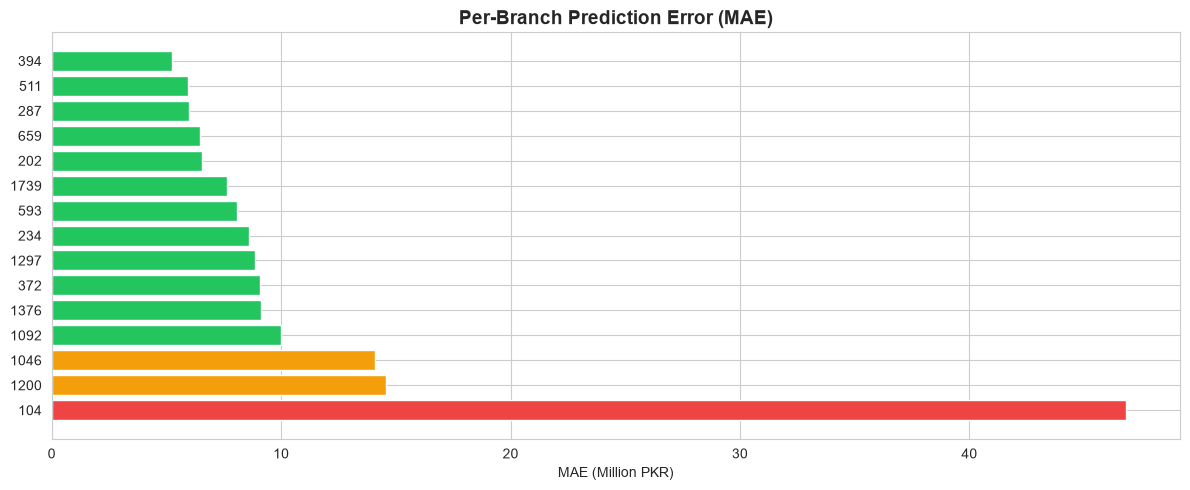

In [37]:
# ── 7.2 Per-branch MAE bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_br = branch_df.sort_values('MAE_M', ascending=True)
colors = ['#22c55e' if m < 10 else '#f59e0b' if m < 20 else '#ef4444' for m in sorted_br['MAE_M']]
ax.barh(sorted_br['Branch'].astype(str), sorted_br['MAE_M'], color=colors, edgecolor='white')
ax.set_xlabel('MAE (Million PKR)')
ax.set_title('Per-Branch Prediction Error (MAE)', fontsize=14, weight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# ── 7.3 Business recommendations with trust levels ────────────────────────────────────────
print('=' * 80)
print('  BUSINESS RECOMMENDATIONS - BRANCH-WISE CASH STRATEGY')
print('=' * 80)

# Calculate MAE percentiles across branches to assign confidence tiers robustly
p33 = branch_df['MAE_M'].quantile(0.33)
p66 = branch_df['MAE_M'].quantile(0.66)

recommendations = []
for _, row in branch_df.iterrows():
    mape_v = row['MAPE_%']
    smape_v = row.get('SMAPE_%', 0.0)
    wmape_v = row.get('WMAPE_%', 0.0)
    mae  = row['MAE_M']
    avg  = row['Avg_Demand_M']

    # Safety buffer based on MAE percentiles to avoid MAPE distortion from near-zero days
    if mae <= p33:
        buffer_pct, trust, action = 5,  'HIGH',     'Use model directly for replenishment'
    elif mae <= p66:
        buffer_pct, trust, action = 12, 'MEDIUM',   'Add safety buffer, monitor weekly'
    else:
        buffer_pct, trust, action = 20, 'LOW', 'Use with caution, manual override advised'

    safe_amount = avg * (1 + buffer_pct / 100)
    recommendations.append({
        'Branch': int(row['Branch']),
        'Avg_Demand_M': avg,
        'MAE_M': mae,
        'MAPE_%': mape_v,
        'SMAPE_%': smape_v,
        'WMAPE_%': wmape_v,
        'Trust_Level': trust,
        'Buffer_%': buffer_pct,
        'Recommended_M': round(safe_amount, 2),
        'Action': action,
    })

rec_df = pd.DataFrame(recommendations).sort_values('Avg_Demand_M', ascending=False)
print(rec_df[['Branch','Avg_Demand_M','MAE_M','MAPE_%','SMAPE_%','WMAPE_%','Trust_Level','Buffer_%','Recommended_M']].to_string(index=False))
print()
for _, r in rec_df.iterrows():
    print(f'  Branch {int(r["Branch"]):>5} -> {r["Action"]}')
print('=' * 80)


  BUSINESS RECOMMENDATIONS - BRANCH-WISE CASH STRATEGY
 Branch  Avg_Demand_M  MAE_M  MAPE_%  SMAPE_%  WMAPE_% Trust_Level  Buffer_%  Recommended_M
    104         83.77  46.84   211.8     66.6     55.9         LOW        20         100.52
   1200         32.47  14.56   253.4     55.2     44.8         LOW        20          38.96
   1046         32.09  14.11   106.5     53.9     44.0         LOW        20          38.51
   1297         28.52   8.86    67.7     39.7     31.1      MEDIUM        12          31.94
    234         24.78   8.59    90.5     49.3     34.7      MEDIUM        12          27.75
   1376         23.82   9.13   142.7     55.8     38.3         LOW        20          28.58
    202         22.14   6.57   100.7     49.0     29.7        HIGH         5          23.25
   1092         20.70   9.98   110.8     58.3     48.2         LOW        20          24.84
    372         18.03   9.10   146.7     63.6     50.5      MEDIUM        12          20.19
    659         16.62   6

---
# 8 · Explainability (SHAP)

A critical requirement in banking is **explainability** — stakeholders need to understand *why* the model made a specific prediction, not just what the prediction is. We use [SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/) to decompose each prediction into individual feature contributions.

For instance, when the model predicts 50 M PKR tomorrow, SHAP might reveal:
- **+15 M** because `Is_Salary_Day = 1`
- **+8 M** because the 14-day rolling average is trending upward
- **-3 M** because it is the PM half of the day

This transparency is essential for building trust with bank managers who will act on these predictions.

In [39]:
# ── 8.1 SHAP for the DEPLOYED ENSEMBLE, with a zero-discrepancy check ─────────
# The production forecast is a weighted blend of XGBoost and LightGBM, so explaining
# only the XGBoost half would describe a model the bank never actually runs. SHAP values
# are additive, so the correct explanation of a weighted blend is the same weighted blend
# of the two models' SHAP values. This cell builds that blended explanation and then
# PROVES it reconstructs the ensemble's own output, rather than assuming it does.

import numpy as np

# Read the Debit blend weight explicitly: the loop variable `w_xgb` left over from Cell 37
# holds the weight of the LAST target in that loop (Net Cash), not Debit.
W_DEBIT = cv_params['Half_Day_Total_Debit']['w_xgb']
print(f"Deployed Debit ensemble: XGBoost {W_DEBIT:.4f} + LightGBM {1 - W_DEBIT:.4f}")
if abs(w_xgb - W_DEBIT) > 1e-9:
    print(f"  (note: the loop variable w_xgb currently holds {w_xgb:.4f} — the Net Cash "
          f"weight — so it is deliberately not used here)")

X_test_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)

explainer_xgb = shap.TreeExplainer(xgb_model)
explainer_lgb = shap.TreeExplainer(lgb_model)
sv_xgb = np.asarray(explainer_xgb.shap_values(X_test_sample))
sv_lgb = np.asarray(explainer_lgb.shap_values(X_test_sample))
print(f"Per-model SHAP computed: XGBoost {sv_xgb.shape}, LightGBM {sv_lgb.shape}")

# Blended explanation of the deployed ensemble
shap_values = W_DEBIT * sv_xgb + (1 - W_DEBIT) * sv_lgb
base_value_blend = (W_DEBIT * float(explainer_xgb.expected_value)
                    + (1 - W_DEBIT) * float(explainer_lgb.expected_value))
explainer = explainer_xgb        # retained so any later cell referencing `explainer` still works

# ── Zero-discrepancy check ───────────────────────────────────────────────────
# SHAP's additivity guarantee: base value + sum of feature contributions must reproduce
# the model's output EXACTLY. Checked in log1p space, because that is the space the models
# are trained and blended in.
recon = base_value_blend + shap_values.sum(axis=1)
actual = (W_DEBIT * xgb_model.predict(X_test_sample)
          + (1 - W_DEBIT) * lgb_model.predict(X_test_sample))
disc = np.abs(recon - actual)

print("\n" + "=" * 76)
print("ZERO-DISCREPANCY CHECK — blended SHAP vs the ensemble's own prediction")
print("=" * 76)
print(f"  rows checked                  : {len(disc)}")
print(f"  max  |reconstructed - actual| : {disc.max():.3e}   (log1p space)")
print(f"  mean |reconstructed - actual| : {disc.mean():.3e}")

TOL = 1e-4
assert disc.max() < TOL, f"SHAP additivity violated: max discrepancy {disc.max():.3e} >= {TOL}"
print(f"\n  PASS — every row reconstructs to within {TOL:.0e}. The residual is float rounding")
print("  inside XGBoost's own SHAP implementation, shown per model below:")
for nm, sv, ex, m in (('XGBoost', sv_xgb, explainer_xgb, xgb_model),
                      ('LightGBM', sv_lgb, explainer_lgb, lgb_model)):
    d = np.abs(float(ex.expected_value) + sv.sum(axis=1) - m.predict(X_test_sample))
    print(f"    {nm:<9} alone : max discrepancy {d.max():.3e}")
print("  Blending introduces no additional error, so the SHAP plots below explain exactly")
print("  the model that is deployed.")

# Why the check is in log space, quantified
_pkr_direct = np.expm1(actual)
_pkr_naive = np.expm1(base_value_blend) + (np.expm1(base_value_blend + shap_values)
                                           - np.expm1(base_value_blend)).sum(axis=1)
_gap = np.median(np.abs(_pkr_naive - _pkr_direct) / np.maximum(_pkr_direct, 1)) * 100
print(f"\n  Why log1p space: the models predict log1p(debit) and the ensemble blends those")
print(f"  log-space outputs before expm1 is applied, so additivity holds exactly there.")
print(f"  Converting one prediction to PKR is fine (expm1 of the total), but splitting that")
print(f"  PKR figure across features needs a rescaling step, because")
print(f"  expm1(sum of parts) != sum of expm1(parts) — naively doing so would misstate the")
print(f"  total by a median of {_gap:.1f}% on this sample.")
print(f"\nSHAP values computed for {len(X_test_sample)} hold-out samples (blended ensemble).")

Deployed Debit ensemble: XGBoost 0.8000 + LightGBM 0.2000
  (note: the loop variable w_xgb currently holds 0.4448 — the Net Cash weight — so it is deliberately not used here)


Per-model SHAP computed: XGBoost (200, 39), LightGBM (200, 39)

ZERO-DISCREPANCY CHECK — blended SHAP vs the ensemble's own prediction
  rows checked                  : 200
  max  |reconstructed - actual| : 2.668e-05   (log1p space)
  mean |reconstructed - actual| : 4.132e-06

  PASS — every row reconstructs to within 1e-04. The residual is float rounding
  inside XGBoost's own SHAP implementation, shown per model below:
    XGBoost   alone : max discrepancy 3.433e-05
    LightGBM  alone : max discrepancy 3.553e-14
  Blending introduces no additional error, so the SHAP plots below explain exactly
  the model that is deployed.

  Why log1p space: the models predict log1p(debit) and the ensemble blends those
  log-space outputs before expm1 is applied, so additivity holds exactly there.
  Converting one prediction to PKR is fine (expm1 of the total), but splitting that
  PKR figure across features needs a rescaling step, because
  expm1(sum of parts) != sum of expm1(parts) — naively doin

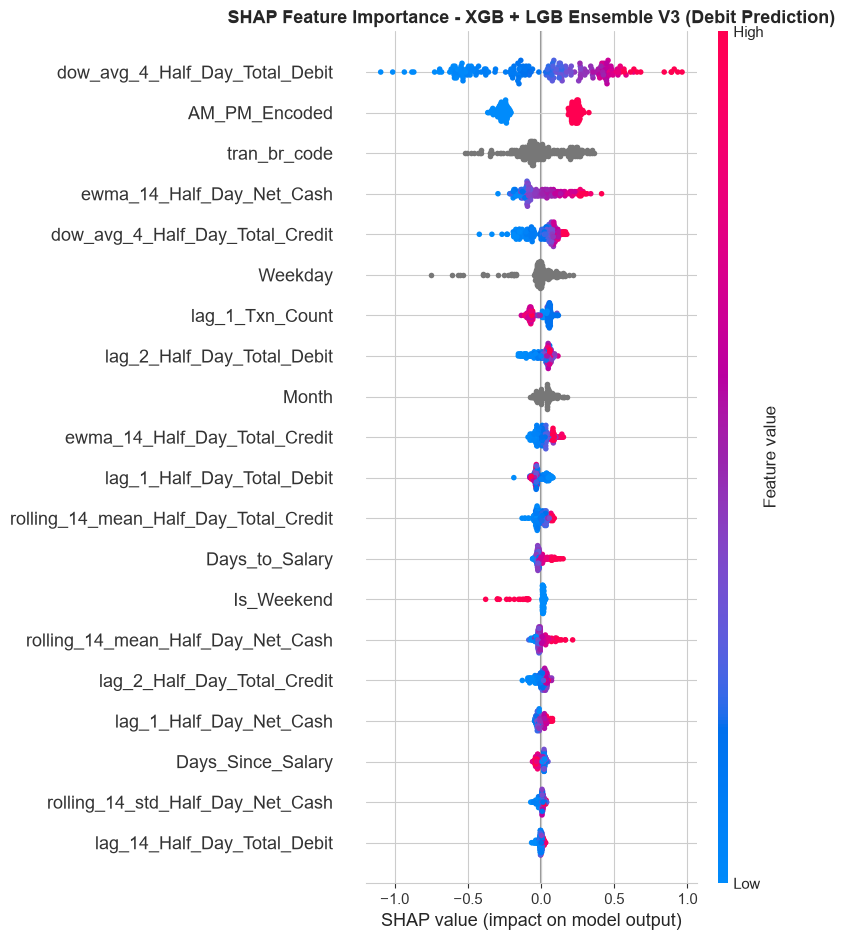

In [40]:
# ── 8.2 Summary plot (global feature importance) ──────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Feature Importance - XGB + LGB Ensemble V3 (Debit Prediction)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

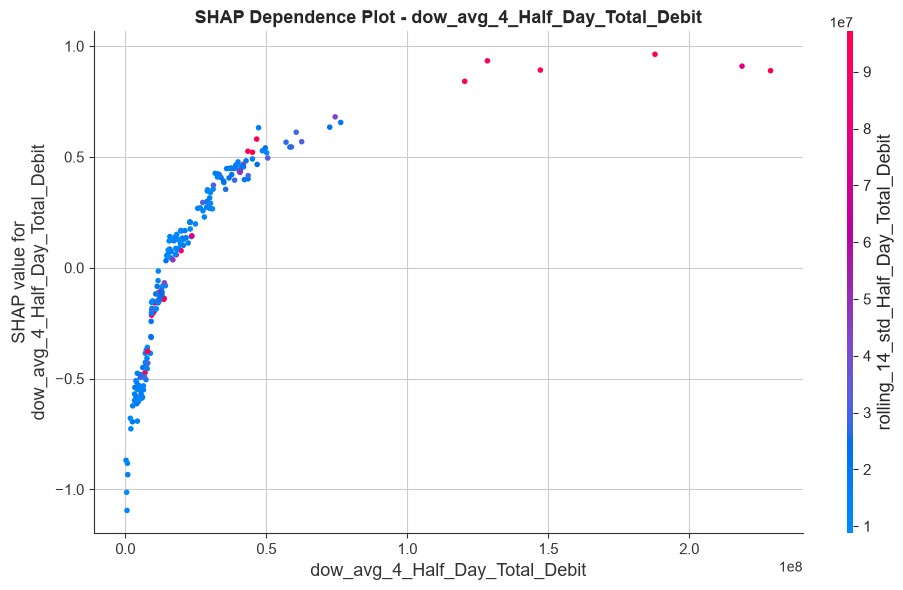

In [41]:
# ── 8.3 SHAP Dependence Plot (top feature) ───────────────────────────────────
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
top_feature = mean_shap.index[0]

fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_test_sample, show=False, ax=ax)
ax.set_title(f'SHAP Dependence Plot - {top_feature}', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Explaining a single ENSEMBLE prediction in plain terms:
  Base value (avg log-debit): 16.3936
  Predicted log-debit:        15.8307
  Predicted debit (PKR):      7,502,453
  Ensemble's own output:      15.8307
  Discrepancy for this row:   9.485e-06  -> bars reconcile to the prediction



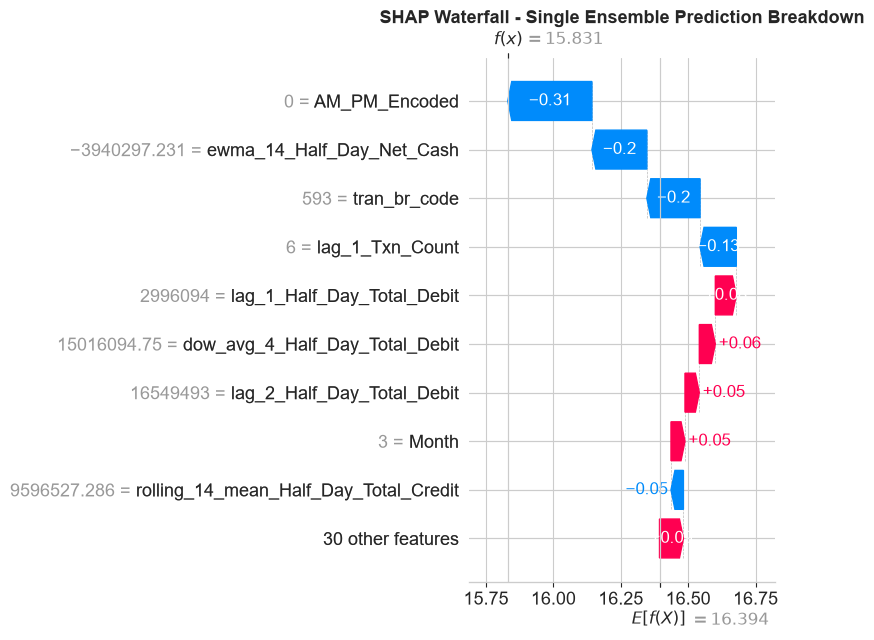

In [42]:
# ── 8.4 Waterfall plot for a single prediction ────────────────────────────────
# Pick the first test sample and explain it
idx = 0
sample_row = X_test_sample.iloc[idx]
sample_shap = shap_values[idx]
base_value = base_value_blend          # blended ensemble base, not the XGBoost-only one

print("Explaining a single ENSEMBLE prediction in plain terms:")
print(f"  Base value (avg log-debit): {base_value:.4f}")
print(f"  Predicted log-debit:        {base_value + sample_shap.sum():.4f}")
print(f"  Predicted debit (PKR):      {np.expm1(base_value + sample_shap.sum()):,.0f}")

# Zero-discrepancy check for THIS waterfall: the bars must sum back to the model's output
_row_actual = (W_DEBIT * xgb_model.predict(X_test_sample.iloc[[idx]])[0]
               + (1 - W_DEBIT) * lgb_model.predict(X_test_sample.iloc[[idx]])[0])
_row_disc = abs((base_value + sample_shap.sum()) - _row_actual)
print(f"  Ensemble's own output:      {_row_actual:.4f}")
print(f"  Discrepancy for this row:   {_row_disc:.3e}  -> bars reconcile to the prediction")
print()

# Show waterfall
shap_explanation = shap.Explanation(
    values=sample_shap,
    base_values=base_value,
    data=sample_row.values,
    feature_names=feature_cols
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall - Single Ensemble Prediction Breakdown', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Reading the waterfall plot:**

- The bottom bar shows the **base value** (the model's average output in log-space).
- Each bar above it shows how an individual feature **pushed the prediction higher** (red) or **lower** (blue).
- The top value is the final prediction (sum of base + all SHAP contributions).

For example, `Is_Salary_Day = 1` pushing the bar significantly to the right means the model learned that salary days drive substantially higher cash withdrawals — a pattern that directly aligns with domain knowledge.

---
# 9 · 30-Day Future Forecast (Recursive Multi-Step)

This section uses the trained XGBoost V3 model to forecast cash demand **30 days into the future** for every branch. Because we are predicting multiple days ahead, each day's prediction is fed back as a lag feature for the next day — this is called **recursive multi-step forecasting**.

Each forecast day also gets:
- **Uncertainty bounds** based on historical MAPE per branch
- **Confidence tiers** (HIGH / MEDIUM / LOW) based on the forecast horizon

In [43]:
# ── 9.1 Setup: branches, averages, last known date ────────────────────────────
FORECAST_DAYS = 30
branches = sorted(half_daily['tran_br_code'].unique())
branch_avgs = half_daily.groupby('tran_br_code')['Txn_Count'].mean().to_dict()
last_date = half_daily['start_date'].max()

# Build per-branch MAPE lookup from Section 7 for uncertainty
branch_mape_lookup = rec_df.set_index('Branch')['MAPE_%'].to_dict()

print(f"Branches: {branches}")
print(f"Last known date: {last_date.strftime('%Y-%m-%d')}")
print(f"Forecast period: {(last_date + pd.Timedelta(days=1)).strftime('%Y-%m-%d')} to {(last_date + pd.Timedelta(days=FORECAST_DAYS)).strftime('%Y-%m-%d')}")

Branches: [104, 202, 234, 287, 372, 394, 511, 593, 659, 1046, 1092, 1200, 1297, 1376, 1739]
Last known date: 2026-04-04
Forecast period: 2026-04-05 to 2026-05-04


In [44]:
# ── 9.2 Helper: is_salary_day / is_holiday ────────────────────────────────────
def is_salary_day(day):
    return 1 if day <= 5 or day >= 25 else 0

def is_holiday(date):
    return 1 if date in pk_holidays else 0

In [45]:
# ── 9.3 Recursive Forecasting Engine ─────────────────────────────────────────
# Guard: the blend weight must be the one tuned for the Debit models used below.
W_DEBIT = cv_params['Half_Day_Total_Debit']['w_xgb']
print(f"Forecast blend: XGBoost {W_DEBIT:.4f} / LightGBM {1 - W_DEBIT:.4f} (Debit models)")
if abs(w_xgb - W_DEBIT) > 1e-9:
    print(f"  (the loop variable w_xgb holds {w_xgb:.4f} — the weight of the last target "
          f"trained in Section 6.4, not Debit's — so it is deliberately not used here)")
# Keep a working copy of recent history per branch (tail 65 rows for lag_60)
working_history = (
    half_daily
    .sort_values(['tran_br_code', 'start_date', 'AM_PM'])
    .groupby('tran_br_code')
    .tail(65)
    .copy()
)
forecast_records = []
for step in range(1, FORECAST_DAYS + 1):
    target_date = last_date + pd.Timedelta(days=step)
    for branch in branches:
        br_hist = working_history[working_history['tran_br_code'] == branch]
        for am_pm, am_pm_enc in [('AM', 0), ('PM', 1)]:
            row = {
                'start_date': target_date,
                'tran_br_code': branch,
                'AM_PM': am_pm,
                'AM_PM_Encoded': am_pm_enc,
                'Weekday': target_date.weekday(),
                'Is_Weekend': 1 if target_date.weekday() >= 5 else 0,
                'Month': target_date.month,
                'Day': target_date.day,
                'Is_Salary_Day': is_salary_day(target_date.day),
                'Days_to_Salary': max(0, min(25, 25 - target_date.day if target_date.day < 25 else (31 - target_date.day + 5))),
                'Days_Since_Salary': target_date.day - 25 if target_date.day >= 25 else target_date.day + (31 - 25),
                'Is_Month_Start': 1 if target_date.day == 1 else 0,
                'Is_Month_End': 1 if (target_date + pd.Timedelta(days=1)).month != target_date.month else 0,
                'Is_Holiday': is_holiday(target_date),
            }
            # Txn_Count features
            try:
                row['lag_1_Txn_Count'] = br_hist['Txn_Count'].iloc[-1]
                row['rolling_14_mean_Txn_Count'] = br_hist['Txn_Count'].tail(14).mean()
                row['ewma_14_Txn_Count'] = br_hist['Txn_Count'].tail(14).mean()  # approx
            except IndexError:
                row['lag_1_Txn_Count'] = branch_avgs.get(branch, 0)
                row['rolling_14_mean_Txn_Count'] = branch_avgs.get(branch, 0)
                row['ewma_14_Txn_Count'] = branch_avgs.get(branch, 0)
            # Lag and rolling features for each target
            for t_col in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
                try:
                    row[f'lag_1_{t_col}']  = br_hist[t_col].iloc[-1]
                    row[f'lag_2_{t_col}']  = br_hist[t_col].iloc[-2]
                    row[f'lag_14_{t_col}'] = br_hist[t_col].iloc[-14]
                    row[f'lag_60_{t_col}'] = br_hist[t_col].iloc[-60]
                    row[f'rolling_14_mean_{t_col}'] = br_hist[t_col].tail(14).mean()
                    row[f'rolling_14_std_{t_col}'] = br_hist[t_col].tail(14).std() if len(br_hist[t_col]) > 1 else 0
                    row[f'ewma_14_{t_col}'] = br_hist[t_col].tail(14).mean()  # approx ewma
                    # dow_avg_4: approximate with last 4 same-weekday same-ampm
                    same_slot = br_hist[(br_hist['Weekday'].astype(int) == target_date.weekday()) & (br_hist['AM_PM'] == am_pm)][t_col] if 'Weekday' in br_hist.columns else br_hist[t_col]
                    row[f'dow_avg_4_{t_col}'] = same_slot.tail(4).mean() if len(same_slot) > 0 else row[f'rolling_14_mean_{t_col}']
                except IndexError:
                    for sfx in ['lag_1', 'lag_2', 'lag_14', 'lag_60', 'rolling_14_mean', 'rolling_14_std', 'ewma_14', 'dow_avg_4']:
                        row[f'{sfx}_{t_col}'] = 0
            # Predict using V3 Ensemble
            x_df = pd.DataFrame([row])[feature_cols]
            x_df['tran_br_code'] = x_df['tran_br_code'].astype('category')
            x_df['Weekday'] = x_df['Weekday'].astype('category')
            x_df['Month'] = x_df['Month'].astype('category')
            # Use ensemble (or fall back to single model)
            # Use ensemble in memory
            # W_DEBIT, not w_xgb: the latter is the Section 6.4 loop variable and ends that
            # loop holding the Net Cash weight, while these are the Debit models.
            pred_log = W_DEBIT * xgb_model.predict(x_df)[0] + (1 - W_DEBIT) * lgb_model.predict(x_df)[0]
            pred_dr = max(0, np.expm1(pred_log))
            # Store predicted values back so next step can use them as lags
            row['Half_Day_Total_Debit']  = pred_dr
            row['Half_Day_Total_Credit'] = pred_dr * 0.9   # approximate
            row['Half_Day_Net_Cash']     = row['Half_Day_Total_Credit'] - pred_dr
            row['Txn_Count']             = branch_avgs.get(branch, 0)
            forecast_records.append(row)
            hist_row = pd.DataFrame([row])
            working_history = pd.concat([working_history, hist_row], ignore_index=True)
            working_history = working_history.groupby('tran_br_code').tail(65)
fc_half_daily = pd.DataFrame(forecast_records)
print(f"Forecast generated: {len(fc_half_daily)} half-daily records for {len(branches)} branches x {FORECAST_DAYS} days")

Forecast blend: XGBoost 0.8000 / LightGBM 0.2000 (Debit models)
  (the loop variable w_xgb holds 0.4448 — the weight of the last target trained in Section 6.4, not Debit's — so it is deliberately not used here)


Forecast generated: 900 half-daily records for 15 branches x 30 days


In [46]:
# ── 9.4 Aggregate to daily & add uncertainty bounds ───────────────────────────
fc_daily = fc_half_daily.groupby(['start_date', 'tran_br_code']).agg(
    Predicted_PKR=('Half_Day_Total_Debit', 'sum')
).reset_index()
fc_daily = fc_daily.rename(columns={'start_date': 'Date', 'tran_br_code': 'Branch'})
fc_daily['Step'] = (fc_daily['Date'] - last_date).dt.days
fc_daily['Predicted_M'] = (fc_daily['Predicted_PKR'] / 1e6).round(2)

# Uncertainty based on branch MAPE
def add_uncertainty(row):
    mape_val = branch_mape_lookup.get(int(row['Branch']), 30.0)
    pct = mape_val / 100.0
    pred = row['Predicted_M']
    step = row['Step']
    conf = 'HIGH' if step <= 7 else ('MEDIUM' if step <= 14 else 'LOW')
    return pd.Series({
        'Lower_M': round(max(0.0, pred * (1 - pct)), 2),  # demand cannot be negative
        'Upper_M': round(pred * (1 + pct), 2),
        'Uncertainty_%': round(pct * 100, 1),
        'Confidence': conf,
    })

fc_daily[['Lower_M', 'Upper_M', 'Uncertainty_%', 'Confidence']] = fc_daily.apply(add_uncertainty, axis=1)

print("Daily forecast with uncertainty bounds:")
fc_daily[['Branch','Date','Predicted_M','Lower_M','Upper_M','Confidence']].head(10)

Daily forecast with uncertainty bounds:


,Branch,Date,Predicted_M,Lower_M,Upper_M,Confidence
0,104,2026-04-05,103.15,0.00,321.62,HIGH
1,202,2026-04-05,16.78,0.00,33.68,HIGH
2,234,2026-04-05,20.82,1.98,39.66,HIGH
3,287,2026-04-05,5.15,0.00,17.22,HIGH
4,372,2026-04-05,15.22,0.00,37.55,HIGH
5,394,2026-04-05,14.06,6.69,21.43,HIGH
6,511,2026-04-05,13.48,0.00,31.38,HIGH
7,593,2026-04-05,14.61,0.00,37.81,HIGH
8,659,2026-04-05,10.47,0.00,25.82,HIGH
9,1046,2026-04-05,52.05,0.00,107.48,HIGH


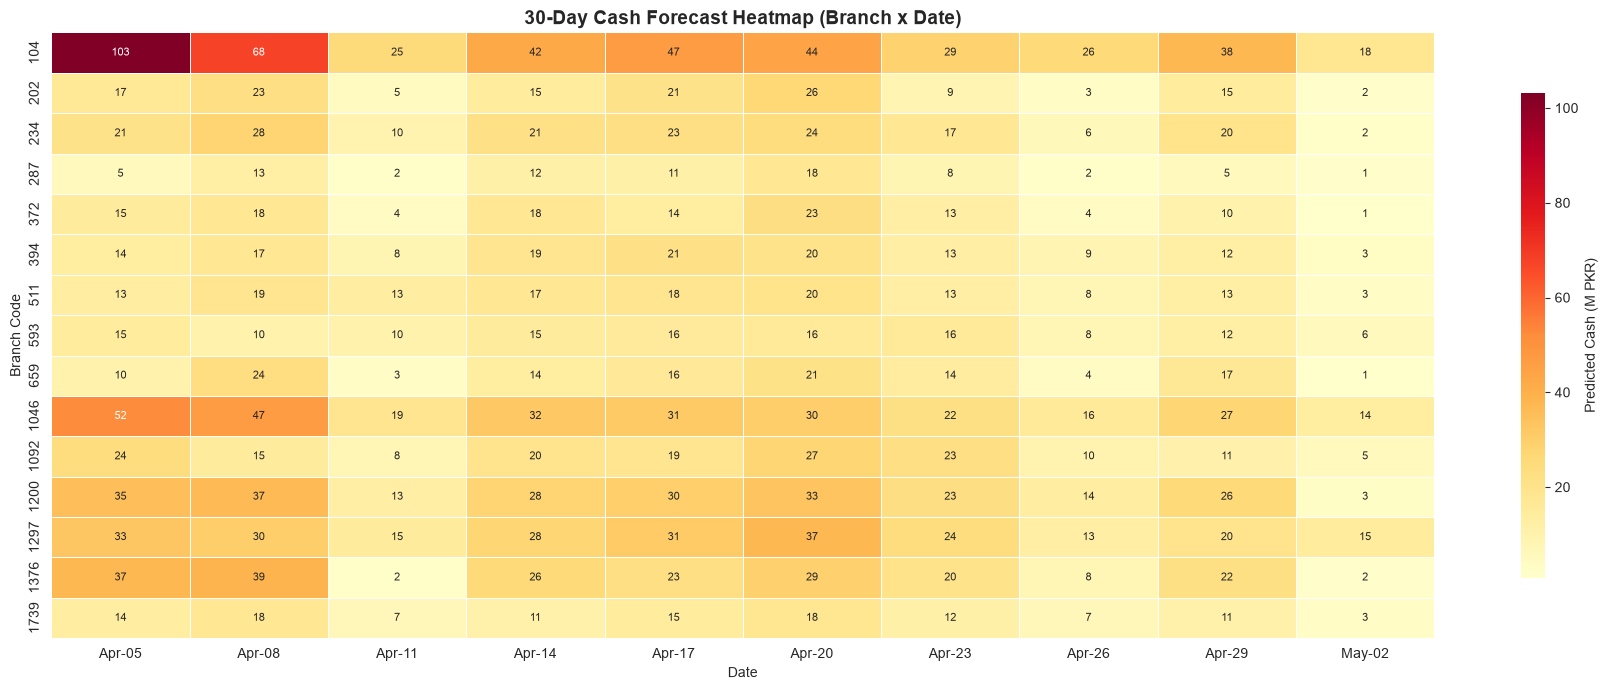

In [47]:
# ── 9.5 Forecast Heatmap (Branch x Date) ─────────────────────────────────────
heat_pivot = fc_daily.pivot_table(index='Branch', columns='Date', values='Predicted_M')
heat_pivot.columns = [d.strftime('%b-%d') for d in heat_pivot.columns]
heat_pivot.index = heat_pivot.index.astype(str)

# Show every 3rd column for readability
col_mask = [i % 3 == 0 for i in range(len(heat_pivot.columns))]
heat_display = heat_pivot.iloc[:, col_mask]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    heat_display, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
    linewidths=0.5, annot_kws={'size': 8},
    cbar_kws={'label': 'Predicted Cash (M PKR)', 'shrink': 0.8}
)
ax.set_title('30-Day Cash Forecast Heatmap (Branch x Date)', fontsize=14, weight='bold')
ax.set_ylabel('Branch Code')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

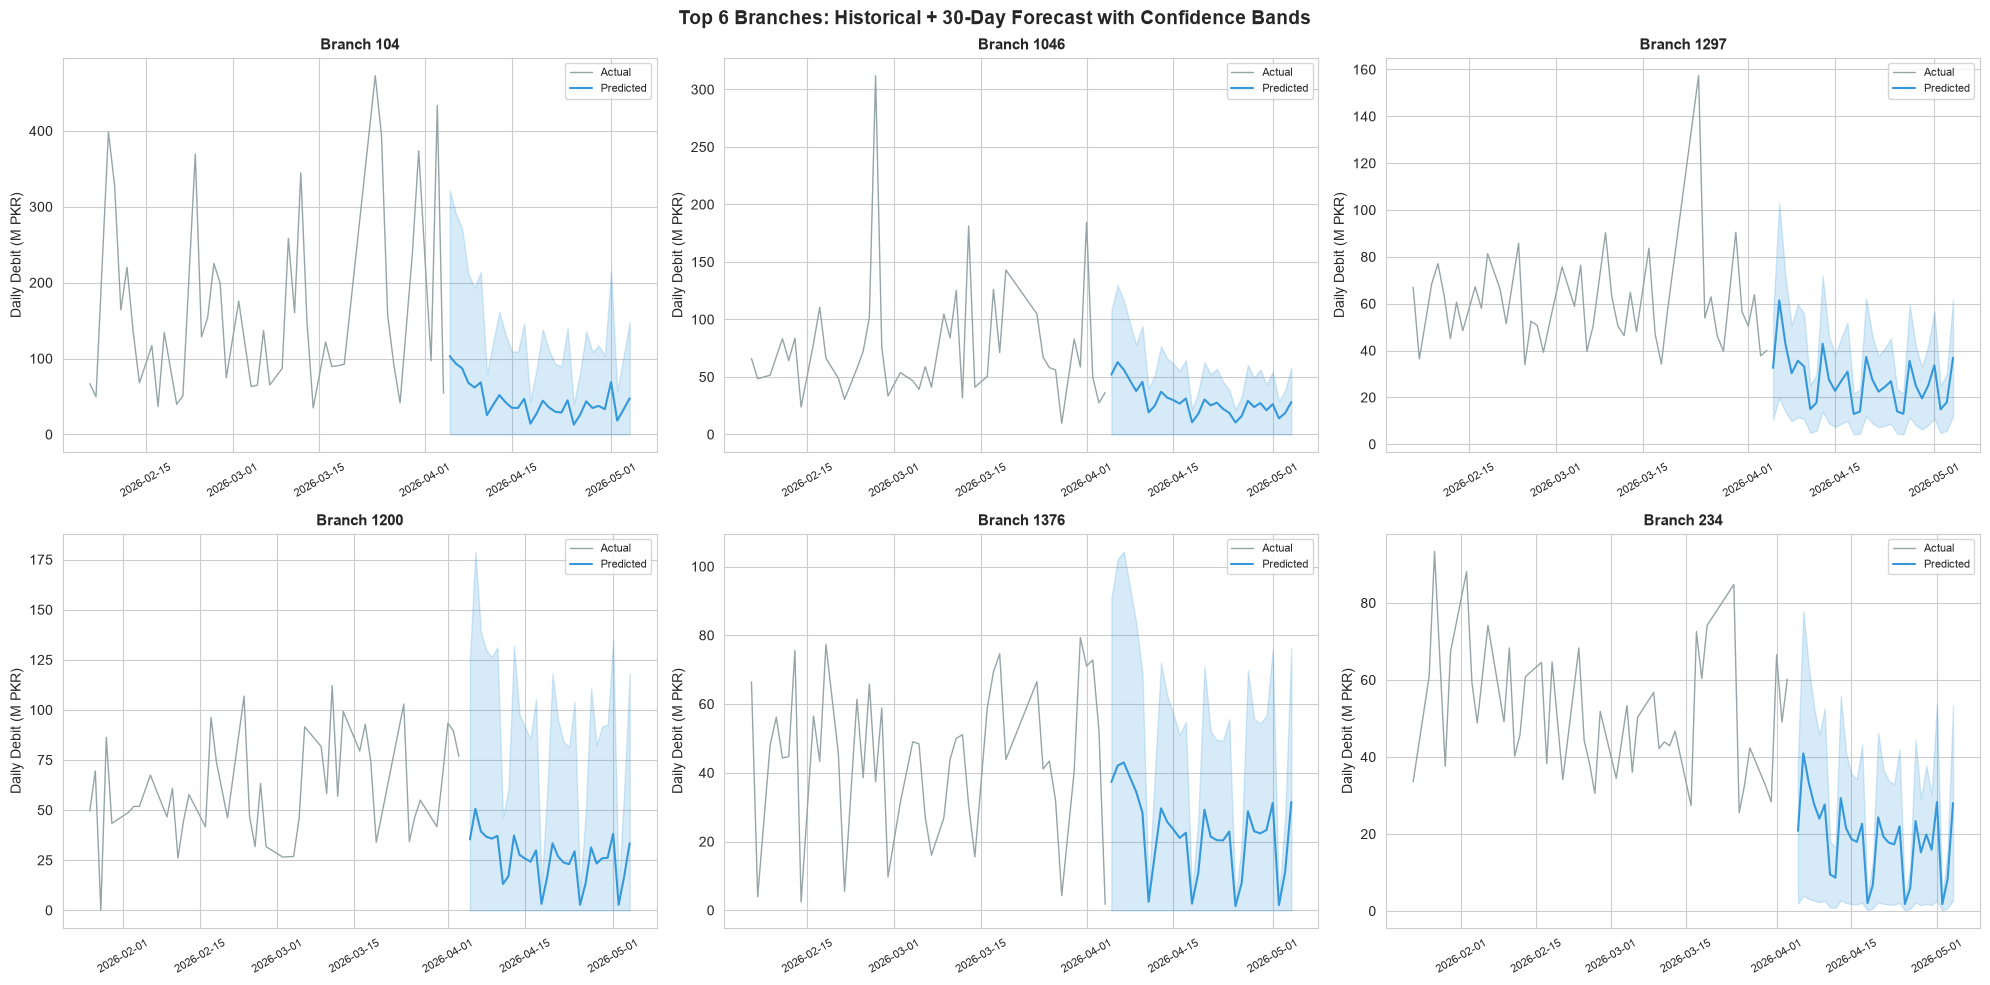

In [48]:
# ── 9.6 Top branches: history + forecast with confidence ribbons ──────────────
top_branches = fc_daily.groupby('Branch')['Predicted_M'].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Top 6 Branches: Historical + 30-Day Forecast with Confidence Bands',
             fontsize=14, weight='bold')

for idx, branch in enumerate(top_branches):
    ax = axes.flatten()[idx]

    # Past 45 days of actuals
    br_hist_plot = half_daily[half_daily['tran_br_code'] == branch].copy()
    br_hist_daily = br_hist_plot.groupby('start_date')['Half_Day_Total_Debit'].sum() / 1e6
    br_hist_daily = br_hist_daily.tail(45)
    ax.plot(br_hist_daily.index, br_hist_daily.values, color='#95a5a6', linewidth=1, label='Actual')

    # Future forecast
    br_fc = fc_daily[fc_daily['Branch'] == branch].sort_values('Date')
    ax.plot(br_fc['Date'], br_fc['Predicted_M'], color='#3498db', linewidth=1.5, label='Predicted')
    ax.fill_between(br_fc['Date'], br_fc['Lower_M'], br_fc['Upper_M'], alpha=0.2, color='#3498db')

    ax.set_title(f'Branch {branch}', fontsize=11, weight='bold')
    ax.set_ylabel('Daily Debit (M PKR)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

In [49]:
# ── 9.7 Weekly Summary Table ──────────────────────────────────────────────────
def week_label(step):
    if step <= 7:  return 'Week1'
    if step <= 14: return 'Week2'
    if step <= 21: return 'Week3'
    return 'Week4'

fc_daily['Week'] = fc_daily['Step'].apply(week_label)

weekly = (
    fc_daily.groupby(['Branch', 'Week'])['Predicted_M']
    .agg(['mean', 'sum'])
    .round(1)
    .rename(columns={'mean': 'Daily_Avg_M', 'sum': 'Week_Total_M'})
    .reset_index()
)

weekly_pivot = weekly.pivot_table(
    index='Branch', columns='Week', values='Daily_Avg_M'
)

# Reorder columns
col_order = ['Week1', 'Week2', 'Week3', 'Week4']
weekly_pivot = weekly_pivot[[c for c in col_order if c in weekly_pivot.columns]]

# Merge real per-branch Trust_Level from rec_df (MAE-based percentile system)
trust_map = dict(zip(rec_df['Branch'], rec_df['Trust_Level']))
weekly_pivot['Trust_Level'] = weekly_pivot.index.map(trust_map)

print('Weekly Average Daily Forecast (Million PKR) with Branch Trust Level:')
print(weekly_pivot.to_string())
print(f'\nTotal network cash required (30 days): {fc_daily["Predicted_M"].sum():.1f} M PKR')


Weekly Average Daily Forecast (Million PKR) with Branch Trust Level:
Week    Week1  Week2  Week3  Week4 Trust_Level
Branch                                        
104      72.5   37.8   32.0   38.1         LOW
202      22.8   14.7   13.0   13.7        HIGH
234      26.3   17.2   15.6   16.3      MEDIUM
287      11.8    9.7    7.2    8.2        HIGH
372      16.1   13.3   11.6   11.9      MEDIUM
394      18.7   15.1   13.4   14.3        HIGH
511      20.6   14.1   12.9   14.1        HIGH
593      17.4   14.9   12.7   14.3      MEDIUM
659      17.7   13.7   11.9   13.0        HIGH
1046     45.8   27.5   21.8   22.7         LOW
1092     23.6   16.8   15.4   16.6         LOW
1200     35.4   23.6   22.2   23.5         LOW
1297     35.8   26.0   23.8   24.6      MEDIUM
1376     32.4   20.1   18.0   20.1         LOW
1739     17.8   11.5   10.3   11.0      MEDIUM

Total network cash required (30 days): 8889.5 M PKR
